<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_Core_Colab-28-sep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner Rotor PINN — Core Module (Colab)

This notebook loads `flettner_pinn_core.py` (the single unified module for every case in Paper 1 — sparse-data reconstruction, sector masking, control cases) and gives you a ready-to-run example.

**Before running anything for real:** update `DATA_DIR` and `OUT_DIR` below to your actual Drive folders. `DATA_DIR` must contain `CP_data.xlsx` (or `CP data.xlsx`), `CL_data.xlsx`, and `CD_data.xlsx` (the Bordogna et al. 2019 dataset). `OUT_DIR` is where trained weights, results JSON, and figures get saved — on Drive, so training survives a disconnect (see the resume-safety notes below).

**Resume safety:** every run through `core.train()` checkpoints its weights and a results JSON to `OUT_DIR` every 1000 epochs by default, and re-running the same `run_id` picks up from the last checkpoint automatically — you don't need to do anything extra to resume after a disconnect, just re-run the same cell with the same `run_id`.

**If Colab disconnects (unstable internet):** nothing is lost beyond the last checkpoint. Reconnect the runtime, then re-run cells 1 through the data-loading cell (mount Drive → write core → import → load data) to restore your Python session, then re-run whichever sweep/loop cell you were on. Every `run_one()` call checks Drive first: a run that already finished is skipped instantly, and a run that was interrupted mid-training resumes from its last checkpoint automatically — you never restart a run from epoch 0 by accident. Checkpoint frequency is set low (`CHECKPOINT_EVERY`, see the helper cell below) specifically because your connection is unstable, so at most a small number of epochs are ever at risk.

## 1. Mount Drive

Do this first — everything below (data loading, checkpointing) depends on it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 2. Write the core module to disk

This cell writes the current version of `flettner_pinn_core.py` into the Colab runtime's local filesystem (`%%writefile`), so the `import` below picks it up. If you edit the module later, edit the source of truth (the standalone `.py` file you have outside Colab) and re-paste it here, rather than editing this cell in isolation — otherwise the two copies drift apart.

In [ ]:
# @title
%%writefile flettner_pinn_core.py
"""
flettner_pinn_core.py
======================
Unified, parameterized core for the Flettner-rotor PINN app.

Consolidates what was previously spread across five separate notebooks
(Flettner_PINN_NCp8.ipynb, Flettner_PINN_DataEfficiency.ipynb,
Flettner_PINN_ClosureStudies.ipynb Study A + Study B,
Flettner_PINN_ControlAlpha0.ipynb v1-v4) into one reusable library that
every case in the app runs through. A "case" is fully described by a
RunConfig; running one case always goes through the same four functions:
build_model -> train -> evaluate -> flow_field_diagnostics.

IMPORTANT — read before treating this as a drop-in replacement:
The Cp-data loss term (active whenever cfg.NCp > 0) is NEWLY WRITTEN for
this module. The physics-only (NCp=0) training loop is a direct,
verified port of Flettner_PINN_ControlAlpha0.ipynb's Cell 4 (validated
across v1/v2/v3/v4 this session). The NCp>0 data-loss code path, however,
was authored fresh from the documented conventions in
Manuscript_Chat_Summary.md Section 3 (pressure gauge = mean far-field p,
post-hoc Cp shift at evaluation only) because the actual Cell 4 code from
NCp8.ipynb / DataEfficiency.ipynb was never shown in this session — only
its *results* (e.g. NCp=8 best run: MAE=0.219, CL=5.046, CD=1.692) were
recorded. Before relying on this module as the sole system of record,
re-run NCp=8 @ alpha=2 through it and confirm it reproduces MAE ~ 0.219.
If it doesn't, do not treat the old notebooks as superseded until the
discrepancy is understood.

Every run is resume-safe (local backup -> Drive remount check -> write ->
read-back verification), matching the pattern used throughout this
project's other notebooks.
"""

import os
import json
import time
import shutil
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════
# 1. RunConfig — one dataclass describes every case type this app
#    supports (core sweep, Study A hyperparameter variants, Study B
#    sector masking, ControlAlpha0 compact-domain / hard-constraint).
# ══════════════════════════════════════════════════════════════════════

@dataclass
class RunConfig:
    run_id: str                                   # unique, user-set or auto-generated
    RE: float = 3.6e5
    ALPHA: float = 2.0
    R_IN: float = 0.5
    R_OUT: float = 25.0

    # ── Data (Cp) configuration ──
    NCp: int = 8                                   # 0 = physics only
    cp_selection: str = "evenly_spaced_index"      # or "explicit"
    cp_theta_explicit: Optional[List[float]] = None    # used iff cp_selection == "explicit"
    mask_sectors: Optional[List[Tuple[float, float]]] = None
    # sectors given as (theta_start_deg, theta_end_deg), wrapping allowed
    # (e.g. (315, 45)). Points in these sectors are ALWAYS excluded from
    # the training loss regardless of NCp, and scored separately as
    # "masked-sector MAE" in evaluate() — this is Study B's methodology,
    # generalized so the same run can also carry an NCp limit if desired.

    # ── Architecture ──
    hard_constrain_farfield: bool = False          # v3-style Sukumar & Srivastava (2022) hard BC
    pp_pointwise: bool = False
    net_depth: int = 6
    net_width: int = 64

    # ── Training schedule ──
    EPOCHS: int = 6000
    LR: float = 1e-4
    LR_DECAY_EPOCH: int = 3000
    LR_DECAY_TO: float = 3e-5
    TURB_RAMP_START: int = 1000
    TURB_RAMP_LEN: int = 1000
    N_INT: int = 2000
    N_WALL: int = 300
    N_FF: int = 150

    # ── Loss weights ──
    W_PDE: float = 100.
    W_VWALL: float = 300.
    W_VFF: float = 10.
    W_PP: float = 50.
    W_CP: float = 10.
    W_TURB: float = 1.

    # ── Warm start / curriculum (Study A P6-style) ──
    warm_start_run_id: Optional[str] = None        # load initial weights from another run's checkpoint

    seed: Optional[int] = None
    notes: str = ""

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


# ══════════════════════════════════════════════════════════════════════
# 2. Drive-safe I/O — same pattern as every other notebook in this
#    project (local backup -> remount check -> write -> read-back).
# ══════════════════════════════════════════════════════════════════════

def drive_alive(drive_path="/content/drive"):
    return os.path.ismount(drive_path)


def ensure_drive(drive_path="/content/drive", out_dir=None):
    if not drive_alive(drive_path):
        print("  ⚠ Drive mount lost — remounting...")
        from google.colab import drive as _drv
        _drv.mount(drive_path, force_remount=True)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)


def safe_save_json(obj, path, backup_path="/content/_core_backup.json"):
    with open(backup_path, "w") as f:
        json.dump(obj, f)
        f.flush(); os.fsync(f.fileno())
    ensure_drive(out_dir=os.path.dirname(path))
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
        f.flush(); os.fsync(f.fileno())
    with open(path) as f:
        json.load(f)  # read-back verification
    print(f"  💾 verified: {os.path.basename(path)} "
          f"({os.path.getsize(path)/1024:.0f} KB) ✓")


def safe_save_weights(model, path, tmp_path="/content/_tmp_core.weights.h5"):
    model.save_weights(tmp_path)
    ensure_drive(out_dir=os.path.dirname(path))
    shutil.copy(tmp_path, path)
    if os.path.exists(path) and os.path.getsize(path) > 0:
        print(f"  💾 weights verified: {os.path.basename(path)} ✓")
    else:
        print(f"  ✗ WEIGHTS SAVE FAILED: {path}")


def run_paths(cfg: RunConfig, out_dir: str):
    base = f"{out_dir}/{cfg.run_id}"
    return dict(
        results=f"{base}_results.json",
        weights=f"{base}.weights.h5",
        cp_plot=f"{base}_cp.png",
        flowfield_plot=f"{base}_flowfield.png",
        farfield_json=f"{base}_farfield_diagnostic.json",
    )


# ══════════════════════════════════════════════════════════════════════
# 3. Bordogna experimental data loader — direct port of Cell 2, shared
#    across every case type (unchanged from the validated original).
# ══════════════════════════════════════════════════════════════════════

RE_COL_MAP = {1.8e5: {0, 12, 24, 36, 48, 60},
              2.5e5: {3, 15, 27, 39, 51, 63, 69, 75, 81, 87, 93},
              3.6e5: {6, 18, 30, 42, 54, 72, 78, 84, 90, 96},
              1.0e6: {9, 21, 33, 45, 57, 66}}


def load_cp(folder, re_t, a_t, tol=0.1):
    for nm in ["CP_data.xlsx", "CP data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            break
    raw = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0, len(row0) - 1, 3):
        lab = str(row0.iloc[col])
        if "k =" not in lab:
            continue
        try:
            kv = float(lab.split(",")[0].replace("k =", "").strip())
        except Exception:
            continue
        if abs(kv - a_t) > tol:
            continue
        rm = None
        for rv, cs in RE_COL_MAP.items():
            if col in cs:
                rm = rv
                break
        if rm is None or abs(rm - re_t) > re_t * 0.1:
            continue
        th = pd.to_numeric(raw.iloc[2:, col], errors="coerce").values
        cp = pd.to_numeric(raw.iloc[2:, col + 1], errors="coerce").values
        m = ~np.isnan(th) & ~np.isnan(cp)
        if m.sum() < 3:
            continue
        return th[m].astype(np.float32), cp[m].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={a_t}, Re={re_t:.2e}")


def load_cl_cd(folder, re_t):
    sheet = {1.8e5: "Re=1.8e5", 2.5e5: "Re=2.5e5", 3.6e5: "Re=3.6e5",
              5.5e5: "Re=5.5e5", 1.0e6: "Re=1e6"}[min(
        {1.8e5, 2.5e5, 3.6e5, 5.5e5, 1.0e6}, key=lambda r: abs(r - re_t))]
    for nm in ["CL_data.xlsx", "CL data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            clp = p
            break
    for nm in ["CD_data.xlsx", "CD data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            cdp = p
            break
    dcl = pd.read_excel(clp, sheet_name=sheet, header=None)
    dcd = pd.read_excel(cdp, sheet_name=sheet, header=None)
    dcl.columns = ["alpha", "CL"] + list(dcl.columns[2:])
    dcd.columns = ["alpha", "CD"] + list(dcd.columns[2:])
    return (dcl["alpha"].dropna().values.astype(np.float32),
            dcl["CL"].dropna().values.astype(np.float32),
            dcd["alpha"].dropna().values.astype(np.float32),
            dcd["CD"].dropna().values.astype(np.float32))


def load_bordogna(data_dir: str, cfg: RunConfig):
    theta_exp, cp_exp = load_cp(data_dir, cfg.RE, cfg.ALPHA)
    al_cl, CL_e, al_cd, CD_e = load_cl_cd(data_dir, cfg.RE)
    tol = 0.25
    cl_ref = float(CL_e[np.abs(al_cl - cfg.ALPHA) < tol].mean()) \
        if np.any(np.abs(al_cl - cfg.ALPHA) < tol) else 0.0
    cd_ref = float(CD_e[np.abs(al_cd - cfg.ALPHA) < tol].mean()) \
        if np.any(np.abs(al_cd - cfg.ALPHA) < tol) else np.nan
    return dict(theta_exp=theta_exp, cp_exp=cp_exp, cl_ref=cl_ref, cd_ref=cd_ref)


# ══════════════════════════════════════════════════════════════════════
# 4. Cp point selection — generalizes NCp sweeps (DataEfficiency) AND
#    sector masking (Study B) into one mechanism. train_idx feeds the
#    Cp-data loss; masked_idx is scored separately at evaluation time
#    but never trained on; all points remain in eval_idx for the
#    standard overall-MAE metric already used throughout this project.
# ══════════════════════════════════════════════════════════════════════

def _in_sector(theta, start, end):
    """theta, start, end all in degrees [0,360). Handles wraparound
    sectors like (315, 45)."""
    theta = theta % 360.0
    if start <= end:
        return (theta >= start) & (theta <= end)
    return (theta >= start) | (theta <= end)


def select_cp_points(theta_exp: np.ndarray, cp_exp: np.ndarray, cfg: RunConfig):
    n = len(theta_exp)
    masked = np.zeros(n, dtype=bool)
    if cfg.mask_sectors:
        for (s, e) in cfg.mask_sectors:
            masked |= _in_sector(theta_exp, s, e)

    available = np.where(~masked)[0]  # indices eligible for training

    if cfg.NCp <= 0:
        train_idx = np.array([], dtype=int)
    elif cfg.cp_selection == "explicit" and cfg.cp_theta_explicit is not None:
        train_idx = np.array([int(np.argmin(np.abs(theta_exp - t)))
                               for t in cfg.cp_theta_explicit], dtype=int)
        train_idx = np.array([i for i in train_idx if i in available], dtype=int)
    else:
        # evenly_spaced_index: pick NCp indices evenly spaced through the
        # available (non-masked) points, in angular order — this is the
        # same "phase bins of the phase-averaged curve" framing used for
        # the DataEfficiency sweep (see Manuscript_Chat_Summary.md Sec.1).
        order = available[np.argsort(theta_exp[available])]
        k = min(cfg.NCp, len(order))
        if k <= 0:
            train_idx = np.array([], dtype=int)
        else:
            pick = np.linspace(0, len(order) - 1, k).round().astype(int)
            train_idx = np.unique(order[pick])

    masked_idx = np.where(masked)[0]
    eval_idx = np.arange(n)
    return dict(train_idx=train_idx, masked_idx=masked_idx, eval_idx=eval_idx)


# ══════════════════════════════════════════════════════════════════════
# 5. Model — direct generalization of ControlAlpha0 v3's Cell 3.
#    hard_constrain_farfield=False reproduces v1/v2/v4's plain
#    Dense(3) output exactly; =True reproduces v3's Lambda hard-BC layer.
#    net_depth/net_width generalize Study A's P4_big8x128 network-size
#    variant.
# ══════════════════════════════════════════════════════════════════════

def build_model(cfg: RunConfig):
    tf.keras.backend.clear_session()
    if cfg.seed is not None:
        tf.random.set_seed(cfg.seed)

    inp = tf.keras.Input(shape=(3,))
    h = inp
    for _ in range(cfg.net_depth):
        h = tf.keras.layers.Dense(cfg.net_width, activation="tanh")(h)

    if cfg.hard_constrain_farfield:
        uv_corr = tf.keras.layers.Dense(2, activation=None)(h)
        p_out = tf.keras.layers.Dense(1, activation=None)(h)
        ko = tf.keras.layers.Dense(2, activation="softplus")(h)

        R_OUT_local = cfg.R_OUT

        def _hard_bc_uv(args):
            inp_full, corr = args
            x = inp_full[:, 0:1]
            y = inp_full[:, 1:2]
            r = tf.sqrt(x ** 2 + y ** 2)
            d = 1.0 - tf.clip_by_value(r / R_OUT_local, 0.0, 1.0) ** 2
            u = 1.0 + d * corr[:, 0:1]
            v = 0.0 + d * corr[:, 1:2]
            return tf.concat([u, v], axis=1)

        uv_hard = tf.keras.layers.Lambda(_hard_bc_uv, name="hard_bc_uv")([inp, uv_corr])
        uvp = tf.keras.layers.Concatenate(name="uvp")([uv_hard, p_out])
        model = tf.keras.Model(inp, [uvp, ko])
    else:
        uvp = tf.keras.layers.Dense(3, activation=None)(h)
        ko = tf.keras.layers.Dense(2, activation="softplus")(h)
        model = tf.keras.Model(inp, [uvp, ko])

    if cfg.warm_start_run_id is not None:
        pass  # weight loading handled by caller (train()) once paths are known

    return model


def get_uvp(o):
    return o[0]


def get_ko(o):
    return o[1]


def mse(a, b=0.0):
    return tf.reduce_mean(tf.square(a - b))


def make_turb_constants(cfg: RunConfig):
    NU = 1.0 / cfg.RE
    return dict(
        NU=tf.constant(float(NU), tf.float32), BSTAR=tf.constant(.09, tf.float32),
        BETA2=tf.constant(.0828, tf.float32), SK2=tf.constant(1., tf.float32),
        SO2=tf.constant(.856, tf.float32),
        GAM2=tf.constant(.0828 / .09 - .856 * .41 ** 2 / .09 ** .5, tf.float32),
        EPS=tf.constant(1e-8, tf.float32), KW=tf.constant(0., tf.float32),
        OW=tf.constant(60. * float(NU), tf.float32),
        KI=tf.constant(1.5e-4, tf.float32), OI=tf.constant(2., tf.float32),
    )


def make_input_fn(cfg: RunConfig):
    def make_input(x, y):
        a = np.full_like(x, cfg.ALPHA / 5.0, dtype=np.float32)
        return tf.constant(np.hstack([x, y, a]))
    return make_input


def sample_functions(cfg: RunConfig):
    def sample_interior(n):
        th = np.random.uniform(0, 2 * np.pi, n).astype(np.float32)
        r = np.exp(np.random.uniform(np.log(cfg.R_IN), np.log(cfg.R_OUT), n)).astype(np.float32)
        return (r * np.cos(th)).reshape(-1, 1), (r * np.sin(th)).reshape(-1, 1)

    def sample_wall(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (-cfg.R_IN * np.cos(th)).reshape(-1, 1), (+cfg.R_IN * np.sin(th)).reshape(-1, 1)

    def sample_ff(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (cfg.R_OUT * np.cos(th)).reshape(-1, 1), (cfg.R_OUT * np.sin(th)).reshape(-1, 1)

    return sample_interior, sample_wall, sample_ff


# ══════════════════════════════════════════════════════════════════════
# 6. Training — resume-safe, generalized from ControlAlpha0's Cell 4.
#    NEW relative to the original: a Cp-data loss term (active when
#    cfg.NCp > 0 and/or explicit theta points are given), and support
#    for sector-masked training sets. See module docstring — this loss
#    term has NOT been validated against the original NCp8/DataEfficiency
#    notebooks' (unseen) code; parity-check required (Task #3).
# ══════════════════════════════════════════════════════════════════════

def train(cfg: RunConfig, data: dict, out_dir: str, resume: bool = True,
          progress_every: int = 500, checkpoint_every: int = 1000,
          live_callback=None):
    theta_exp, cp_exp = data["theta_exp"], data["cp_exp"]
    sel = select_cp_points(theta_exp, cp_exp, cfg)
    train_idx = sel["train_idx"]

    C = make_turb_constants(cfg)
    make_input = make_input_fn(cfg)
    sample_interior, sample_wall, sample_ff = sample_functions(cfg)
    paths = run_paths(cfg, out_dir)

    model = build_model(cfg)

    # ── Warm start from another run's checkpoint (Study A P6-style) ──
    if cfg.warm_start_run_id is not None:
        warm_weights = f"{out_dir}/{cfg.warm_start_run_id}.weights.h5"
        if os.path.exists(warm_weights):
            model.load_weights(warm_weights)
            print(f"↻ Warm-started from {cfg.warm_start_run_id}")
        else:
            print(f"  ⚠ warm_start_run_id={cfg.warm_start_run_id} has no "
                  f"checkpoint at {warm_weights} — starting from random init instead.")

    # Wall BC (rotating cylinder): u_wall=+Omega*y, v_wall=-Omega*x
    Omega = float(cfg.ALPHA / cfg.R_IN)
    xw, yw = sample_wall(cfg.N_WALL)
    xff, yff = sample_ff(cfg.N_FF)
    xw_tf = make_input(xw, yw)
    xff_tf = make_input(xff, yff)
    u_wall = tf.constant((Omega * yw).astype(np.float32))
    v_wall = tf.constant((-Omega * xw).astype(np.float32))

    # Cp training points: exact experimental (theta, Cp) pairs selected
    # by select_cp_points(), evaluated on the wall at their true angle
    # (not resampled onto the N_WALL ring) — trains directly against the
    # real Bordogna angular locations.
    have_cp = len(train_idx) > 0
    if have_cp:
        th_train_rad = np.radians(theta_exp[train_idx]).astype(np.float32)
        x_cp = (-cfg.R_IN * np.cos(th_train_rad)).reshape(-1, 1).astype(np.float32)
        y_cp = (+cfg.R_IN * np.sin(th_train_rad)).reshape(-1, 1).astype(np.float32)
        xcp_tf = make_input(x_cp, y_cp)
        cp_target = tf.constant(cp_exp[train_idx].reshape(-1, 1).astype(np.float32))

    optimizer = tf.keras.optimizers.Adam(cfg.LR)
    EPS_FD = 1e-3
    history = {k: [] for k in ["loss", "pde", "wall", "cp", "turb", "epoch"]}
    best_loss, best_w = np.inf, None
    start_epoch = 0
    already_done = False

    resume_ckpt = resume and os.path.exists(paths["weights"]) and drive_alive()
    if resume_ckpt:
        model.load_weights(paths["weights"])
        best_w = model.get_weights()
        if os.path.exists(paths["results"]):
            with open(paths["results"]) as f:
                ckpt = json.load(f)
            if ckpt.get("completed", False):
                already_done = True
                best_loss = ckpt.get("best_loss", np.inf)
                history = ckpt.get("history", history)
                print(f"✓ Run '{cfg.run_id}' already completed — skipping training.")
            else:
                start_epoch = ckpt.get("last_epoch", 0) + 1
                history = ckpt.get("history", history)
                best_loss = ckpt.get("best_loss", np.inf)
                print(f"↻ Resuming '{cfg.run_id}' from epoch {start_epoch}")
        else:
            print(f"↻ Weights found but no results log for '{cfg.run_id}' — resuming from epoch 0.")

    t0 = time.time()
    if not already_done:
        print(f"Training '{cfg.run_id}': epochs {start_epoch}→{cfg.EPOCHS} | "
              f"alpha={cfg.ALPHA} NCp={cfg.NCp} (train points={len(train_idx)}) "
              f"R_OUT={cfg.R_OUT} hard_constrain={cfg.hard_constrain_farfield}")

        for ep in range(start_epoch, cfg.EPOCHS):
            x_i, y_i = sample_interior(cfg.N_INT)
            xy_var = tf.Variable(make_input(x_i, y_i), trainable=False, dtype=tf.float32)
            tr = float(min(1., max(0., (ep - cfg.TURB_RAMP_START) / cfg.TURB_RAMP_LEN)))
            tr_tf = tf.constant(tr, tf.float32)

            with tf.GradientTape() as tape:
                with tf.GradientTape(watch_accessed_variables=False, persistent=True) as it:
                    it.watch(xy_var)
                    out = model(xy_var, training=True)
                    uvp = get_uvp(out)
                    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
                    if tr > 0:
                        ko = get_ko(out)
                        k = ko[:, 0:1] + C["EPS"]; om = ko[:, 1:2] + C["EPS"]
                du = it.gradient(u, xy_var); dv = it.gradient(v, xy_var); dp = it.gradient(p, xy_var)
                du_dx, du_dy = du[:, 0:1], du[:, 1:2]
                dv_dx, dv_dy = dv[:, 0:1], dv[:, 1:2]
                dp_dx, dp_dy = dp[:, 0:1], dp[:, 1:2]
                del it

                nu_t = tr_tf * tf.clip_by_value(k / (om + C["EPS"]), 0., .1) if tr > 0 else tf.constant(0.)
                nu_eff = C["NU"] + nu_t
                dX = tf.constant(np.hstack([np.full((cfg.N_INT, 1), EPS_FD),
                                             np.zeros((cfg.N_INT, 1)), np.zeros((cfg.N_INT, 1))]).astype(np.float32))
                dY = tf.constant(np.hstack([np.zeros((cfg.N_INT, 1)),
                                             np.full((cfg.N_INT, 1), EPS_FD), np.zeros((cfg.N_INT, 1))]).astype(np.float32))
                oxp = model(xy_var + dX, training=True); oxm = model(xy_var - dX, training=True)
                oyp = model(xy_var + dY, training=True); oym = model(xy_var - dY, training=True)
                uxp, uxm, uyp, uym = get_uvp(oxp), get_uvp(oxm), get_uvp(oyp), get_uvp(oym)
                ie2 = 1. / EPS_FD ** 2
                d2u_dx2 = (uxp[:, 0:1] - 2 * u + uxm[:, 0:1]) * ie2
                d2u_dy2 = (uyp[:, 0:1] - 2 * u + uym[:, 0:1]) * ie2
                d2v_dx2 = (uxp[:, 1:2] - 2 * v + uxm[:, 1:2]) * ie2
                d2v_dy2 = (uyp[:, 1:2] - 2 * v + uym[:, 1:2]) * ie2
                r_c = du_dx + dv_dy
                r_x = u * du_dx + v * du_dy + dp_dx - nu_eff * (d2u_dx2 + d2u_dy2)
                r_y = u * dv_dx + v * dv_dy + dp_dy - nu_eff * (d2v_dx2 + d2v_dy2)
                loss_pde = mse(r_c) + mse(r_x) + mse(r_y)

                loss_turb = tf.constant(0.)
                if tr > 0:
                    kxp, kxm = get_ko(oxp), get_ko(oxm); kyp, kym = get_ko(oyp), get_ko(oym)
                    iv = .5 / EPS_FD
                    dk_dx = (kxp[:, 0:1] - kxm[:, 0:1]) * iv; dk_dy = (kyp[:, 0:1] - kym[:, 0:1]) * iv
                    do_dx = (kxp[:, 1:2] - kxm[:, 1:2]) * iv; do_dy = (kyp[:, 1:2] - kym[:, 1:2]) * iv
                    d2k_x = (kxp[:, 0:1] - 2 * k + kxm[:, 0:1]) * ie2; d2k_y = (kyp[:, 0:1] - 2 * k + kym[:, 0:1]) * ie2
                    d2o_x = (kxp[:, 1:2] - 2 * om + kxm[:, 1:2]) * ie2; d2o_y = (kyp[:, 1:2] - 2 * om + kym[:, 1:2]) * ie2
                    S2 = 2 * (du_dx ** 2 + dv_dy ** 2) + (du_dy + dv_dx) ** 2
                    Pk = tf.clip_by_value(nu_t * S2, 0., 20. * C["BSTAR"] * k * om)
                    nk = C["NU"] + C["SK2"] * nu_t; no = C["NU"] + C["SO2"] * nu_t
                    crs = 2. * C["SO2"] / (om + C["EPS"]) * (dk_dx * do_dx + dk_dy * do_dy)
                    rk = u * dk_dx + v * dk_dy - Pk + C["BSTAR"] * om * k - nk * (d2k_x + d2k_y)
                    ro = (u * do_dx + v * do_dy - C["GAM2"] * (om / (k + C["EPS"])) * Pk
                          + C["BETA2"] * om ** 2 - no * (d2o_x + d2o_y) - crs)
                    loss_turb = tr_tf * (mse(tf.clip_by_value(rk, -100., 100.))
                                          + mse(tf.clip_by_value(ro, -100., 100.)))

                ow = model(xw_tf, training=True); uw = get_uvp(ow)
                loss_wall = mse(uw[:, 0:1], u_wall) + mse(uw[:, 1:2], v_wall)
                if tr > 0:
                    kw = get_ko(ow)
                    loss_wall += tr_tf * (mse(kw[:, 0:1], C["KW"]) + mse(kw[:, 1:2], C["OW"]))

                off = model(xff_tf, training=True); uff = get_uvp(off)
                loss_ff = mse(uff[:, 0:1], 1.) + mse(uff[:, 1:2])
                pfm = tf.reduce_mean(uff[:, 2:3]);
                #loss_pp = tf.square(pfm)
                loss_pp = mse(uff[:, 2:3]) if cfg.pp_pointwise else tf.square(pfm)
                if tr > 0:
                    kff = get_ko(off)
                    loss_ff += tr_tf * (mse(kff[:, 0:1], C["KI"]) + mse(kff[:, 1:2], C["OI"]))

                # ── Cp-data loss (NEW — see module docstring) ──
                # p_ref is the SAME running far-field mean pressure already
                # computed above for loss_pp (pfm), so Cp is evaluated on
                # the same gauge being enforced this step, not a stale one.
                if have_cp:
                    ocp = model(xcp_tf, training=True); ucp = get_uvp(ocp)
                    cp_pred = 2. * (ucp[:, 2:3] - pfm)
                    loss_cp = mse(cp_pred, cp_target)
                else:
                    loss_cp = tf.constant(0.)

                loss = (cfg.W_PDE * loss_pde + cfg.W_VWALL * loss_wall + cfg.W_VFF * loss_ff
                        + cfg.W_PP * loss_pp + cfg.W_CP * loss_cp + cfg.W_TURB * loss_turb)

            g = tape.gradient(loss, model.trainable_variables)
            g, _ = tf.clip_by_global_norm(g, 5.)
            optimizer.apply_gradients(zip(g, model.trainable_variables))
            L = float(loss)
            if not np.isnan(L) and L < best_loss:
                best_loss = L; best_w = model.get_weights()

            if ep % progress_every == 0:
                phase = "TURB" if tr > 0 else "lam "
                history["loss"].append(L); history["pde"].append(float(loss_pde))
                history["wall"].append(float(loss_wall)); history["cp"].append(float(loss_cp))
                history["turb"].append(float(loss_turb)); history["epoch"].append(ep)
                msg = (f"  ep {ep:5d} [{phase} r={tr:.2f}] L={L:.3f} pde={float(loss_pde):.4f} "
                       f"wall={float(loss_wall):.4f} cp={float(loss_cp):.4f} | {time.time()-t0:.0f}s")
                print(msg)
                if live_callback:
                    live_callback(ep, cfg.EPOCHS, history)

            if ep % checkpoint_every == 0 and ep > 0:
                _cur_w = model.get_weights()
                model.set_weights(best_w if best_w is not None else _cur_w)
                safe_save_weights(model, paths["weights"])
                model.set_weights(_cur_w)
                safe_save_json({"last_epoch": ep, "best_loss": best_loss,
                                 "history": history, "completed": False}, paths["results"])

            if ep == cfg.LR_DECAY_EPOCH:
                optimizer.learning_rate.assign(cfg.LR_DECAY_TO)

        elapsed = (time.time() - t0) / 60.
        if best_w:
            model.set_weights(best_w)
        safe_save_weights(model, paths["weights"])
        safe_save_json({"last_epoch": cfg.EPOCHS - 1, "best_loss": best_loss,
                         "history": history, "completed": True,
                         "elapsed_min": elapsed, "config": cfg.to_dict()}, paths["results"])
        print(f"Done '{cfg.run_id}' in {elapsed:.1f} min | best loss={best_loss:.4f}")
    else:
        if best_w:
            model.set_weights(best_w)
        elapsed = None

    return dict(model=model, history=history, best_loss=best_loss,
                cp_selection=sel, paths=paths, elapsed_min=elapsed,
                make_input=make_input)


# ══════════════════════════════════════════════════════════════════════
# 7. Evaluation — generalizes ControlAlpha0's Cell 5. Reports overall
#    MAE/RMSE (all eval_idx points, as in every prior notebook) AND,
#    when mask_sectors is set, a separate masked-sector MAE (Study B
#    methodology) computed only over the withheld points.
# ══════════════════════════════════════════════════════════════════════

def evaluate(cfg: RunConfig, model, data: dict, cp_selection: dict, out_dir: str):
    theta_exp, cp_exp = data["theta_exp"], data["cp_exp"]
    cl_ref, cd_ref = data["cl_ref"], data["cd_ref"]
    make_input = make_input_fn(cfg)

    def get_p_ref(n=256):
        th = np.linspace(0, 2 * np.pi, n, dtype=np.float32)
        xy = make_input((cfg.R_OUT * np.cos(th)).reshape(-1, 1),
                         (cfg.R_OUT * np.sin(th)).reshape(-1, 1))
        return float(get_uvp(model(xy, training=False)).numpy()[:, 2].mean())

    th_deg = np.linspace(0, 360, 360, dtype=np.float32)
    th_rad = np.radians(th_deg)
    x = (-cfg.R_IN * np.cos(th_rad)).reshape(-1, 1); y = (+cfg.R_IN * np.sin(th_rad)).reshape(-1, 1)
    uvp = get_uvp(model(make_input(x, y), training=False)).numpy()
    pr = get_p_ref()
    Cp_raw = 2. * (uvp[:, 2] - pr)
    Cp = Cp_raw + (float(cp_exp.max()) - Cp_raw.max())

    Cp_at_exp = np.interp(theta_exp, th_deg, Cp)
    abs_err = np.abs(Cp_at_exp - cp_exp)
    eval_idx = cp_selection["eval_idx"]
    masked_idx = cp_selection["masked_idx"]

    mae_overall = float(np.mean(abs_err[eval_idx]))
    rmse_overall = float(np.sqrt(np.mean(abs_err[eval_idx] ** 2)))
    mae_masked = float(np.mean(abs_err[masked_idx])) if len(masked_idx) else None
    rmse_masked = float(np.sqrt(np.mean(abs_err[masked_idx] ** 2))) if len(masked_idx) else None

    # Forces — full stress-tensor integration, unchanged from Cell 5
    n_f = 512; dth = 2 * np.pi / n_f
    th_f = np.linspace(0, 2 * np.pi, n_f, endpoint=False, dtype=np.float32)
    xf = (-cfg.R_IN * np.cos(th_f)).reshape(-1, 1); yf = (+cfg.R_IN * np.sin(th_f)).reshape(-1, 1)
    nx = xf / cfg.R_IN; ny = yf / cfg.R_IN
    p_shift = (float(cp_exp.max()) - Cp_raw.max()) / 2.

    def uv(xp, yp):
        o = get_uvp(model(make_input(xp, yp), training=False)).numpy()
        return o[:, 0:1], o[:, 1:2], o[:, 2:3]

    u0, v0, p0 = uv(xf, yf); p0 = p0 - pr - p_shift
    uxp, vxp, _ = uv(xf + 1e-3, yf); uxm, vxm, _ = uv(xf - 1e-3, yf)
    uyp, vyp, _ = uv(xf, yf + 1e-3); uym, vym, _ = uv(xf, yf - 1e-3)
    du_dx = (uxp - uxm) / 2e-3; du_dy = (uyp - uym) / 2e-3
    dv_dx = (vxp - vxm) / 2e-3; dv_dy = (vyp - vym) / 2e-3
    nu_v = 1.0 / cfg.RE
    txx = 2 * nu_v * du_dx; txy = nu_v * (du_dy + dv_dx); tyy = 2 * nu_v * dv_dy
    CL_p = float((np.sum(-p0 * ny * cfg.R_IN * dth) + np.sum((txy * nx + tyy * ny) * cfg.R_IN * dth)) / .5)
    CD_p = float((np.sum(-p0 * nx * cfg.R_IN * dth) + np.sum((txx * nx + txy * ny) * cfg.R_IN * dth)) / .5)

    CL_err_pct = abs(CL_p - cl_ref) / abs(cl_ref) * 100 if cl_ref not in (0, None) and not np.isnan(cl_ref) else None
    CD_err_pct = abs(CD_p - cd_ref) / abs(cd_ref) * 100 if cd_ref not in (0, None) and not np.isnan(cd_ref) else None

    metrics = dict(
        MAE=mae_overall, RMSE=rmse_overall,
        MAE_masked=mae_masked, RMSE_masked=rmse_masked,
        CL=CL_p, CD=CD_p, CL_ref=cl_ref, CD_ref=cd_ref,
        CL_err_pct=CL_err_pct, CD_err_pct=CD_err_pct,
        n_train_points=len(cp_selection["train_idx"]),
        n_masked_points=len(masked_idx),
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(th_deg, Cp, "b-", lw=2.2, label=f"PINN ({cfg.run_id})")
    retained = np.setdiff1d(eval_idx, np.union1d(cp_selection["train_idx"], masked_idx))
    ax.scatter(theta_exp[cp_selection["train_idx"]], cp_exp[cp_selection["train_idx"]],
               color="green", s=30, zorder=5, label="Exp. (trained on)")
    if len(masked_idx):
        ax.scatter(theta_exp[masked_idx], cp_exp[masked_idx],
                   color="red", s=30, marker="x", zorder=5, label="Exp. (masked, held out)")
    if len(retained):
        ax.scatter(theta_exp[retained], cp_exp[retained],
                   color="gray", s=20, zorder=4, label="Exp. (not used)")
    ax.axhline(0, color="k", lw=.5, ls="--")
    ax.set_xlabel("θ (°)"); ax.set_ylabel("Cp")
    title = f"Cp(θ) — {cfg.run_id} | MAE={mae_overall:.3f}"
    if mae_masked is not None:
        title += f" | masked MAE={mae_masked:.3f}"
    ax.set_title(title)
    ax.set_xlim([0, 360]); ax.set_xticks([0, 90, 180, 270, 360])
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)
    plt.tight_layout()

    return dict(metrics=metrics, Cp_curve=(th_deg, Cp), fig=fig)


# ══════════════════════════════════════════════════════════════════════
# 8. Flow-field diagnostics — same functions as pinn_flow_field_template.py,
#    inlined here so this module is self-contained for the app.
# ══════════════════════════════════════════════════════════════════════

def check_farfield_convergence(model, make_input_fn_, get_uvp_fn, R_in, R_out,
                                radii=None, n=256, U_inf=1.0):
    if radii is None:
        radii = sorted(set([R_in * 1.2, 1.0, 2.0, 4.0, R_out * 0.5, R_out]))
        radii = [r for r in radii if r <= R_out]
    th = np.linspace(0, 2 * np.pi, n, dtype=np.float32)
    results = []
    for r in radii:
        x = (r * np.cos(th)).reshape(-1, 1).astype(np.float32)
        y = (r * np.sin(th)).reshape(-1, 1).astype(np.float32)
        uvp_r = get_uvp_fn(model(make_input_fn_(x, y), training=False)).numpy()
        speed = np.sqrt(uvp_r[:, 0] ** 2 + uvp_r[:, 1] ** 2)
        results.append({"r": float(r), "mean_speed": float(speed.mean()),
                         "std_speed": float(speed.std())})
    return results


def plot_flow_field(model, make_input_fn_, get_uvp_fn, R_in, alpha_label, extent=4.0,
                     n_grid=200, cmap_speed="viridis", cmap_p="RdBu_r",
                     p_shift=0.0, p_ref=0.0, streamline_density=1.6):
    xg = np.linspace(-extent, extent, n_grid, dtype=np.float64)
    yg = np.linspace(-extent, extent, n_grid, dtype=np.float64)
    XG, YG = np.meshgrid(xg, yg)
    Rg = np.sqrt(XG ** 2 + YG ** 2)
    inside = Rg < R_in

    Xf = XG.reshape(-1, 1).astype(np.float32); Yf = YG.reshape(-1, 1).astype(np.float32)
    uvp_g = get_uvp_fn(model(make_input_fn_(Xf, Yf), training=False)).numpy()
    U = uvp_g[:, 0].reshape(XG.shape); V = uvp_g[:, 1].reshape(XG.shape)
    P = uvp_g[:, 2].reshape(XG.shape) - p_ref - p_shift
    speed = np.sqrt(U ** 2 + V ** 2)

    U_stream = np.where(inside, 0.0, U); V_stream = np.where(inside, 0.0, V)
    speed_m = np.ma.array(speed, mask=inside); P_m = np.ma.array(P, mask=inside)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    c0 = axes[0].contourf(XG, YG, speed_m, levels=30, cmap=cmap_speed)
    fig.colorbar(c0, ax=axes[0], label="|u|"); axes[0].set_title(f"Speed |u| (α={alpha_label})")
    axes[1].streamplot(XG, YG, U_stream, V_stream, color="purple",
                        density=streamline_density, linewidth=0.7, arrowsize=1.0)
    axes[1].set_title(f"Streamlines (α={alpha_label})")
    vmax = float(np.nanmax(np.abs(P_m))) if np.any(~inside) else 1.0
    c2 = axes[2].contourf(XG, YG, P_m, levels=30, cmap=cmap_p, vmin=-vmax, vmax=vmax)
    fig.colorbar(c2, ax=axes[2], label="p (gauge)"); axes[2].set_title(f"Pressure (α={alpha_label})")
    for ax in axes:
        ax.add_patch(plt.Circle((0, 0), R_in, facecolor="lightgray", edgecolor="k", zorder=5))
        ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        ax.set_xlim([-extent, extent]); ax.set_ylim([-extent, extent]); ax.set_aspect("equal")
    plt.tight_layout()
    return dict(fig=fig, X=XG, Y=YG, U=U, V=V, P=P, speed=speed)


def flow_field_diagnostics(cfg: RunConfig, model, eval_result, extent=None):
    make_input = make_input_fn(cfg)
    ff_diag = check_farfield_convergence(model, make_input, get_uvp, cfg.R_IN, cfg.R_OUT)
    th_deg, Cp = eval_result["Cp_curve"]
    field = plot_flow_field(model, make_input, get_uvp, cfg.R_IN, alpha_label=cfg.ALPHA,
                             extent=extent or min(6.0, cfg.R_OUT))
    return dict(farfield=ff_diag, field=field)


def _verify_saved_fig(save_path):
    if os.path.exists(save_path) and os.path.getsize(save_path) > 0:
        print(f"  💾 figure verified: {os.path.basename(save_path)} ✓")
    else:
        print(f"  ✗ FIGURE SAVE FAILED: {save_path}")


def plot_collocation_points(cfg: RunConfig, n_interior=800, n_wall=None, n_ff=None,
                             save_path=None, ensure_drive_fn=None):
    """
    Scatter plot of the three collocation-point sets actually used in
    training (interior, wall, far-field) — for the Methodology section's
    domain/sampling figure. Calls the SAME sample_functions() used by
    train(), so this plot shows what was actually sampled, not an
    illustrative approximation of it.

    Two panels, because R_OUT/R_IN is typically 50 (25/0.5): a full-domain
    linear-scale view (left) and a near-wall zoom (right) — a single
    linear-scale panel at full extent would compress the near-wall points
    down to an indistinguishable smudge at the origin, hiding the sampling
    density that matters most for resolving the boundary layer.
    """
    sample_interior, sample_wall, sample_ff = sample_functions(cfg)
    xi, yi = sample_interior(n_interior)
    xw, yw = sample_wall(n_wall or cfg.N_WALL)
    xf, yf = sample_ff(n_ff or cfg.N_FF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, zoom in zip(axes, [False, True]):
        ax.scatter(xi, yi, s=4, c="tab:blue", alpha=.5, label=f"Interior (N={n_interior})")
        ax.scatter(xw, yw, s=10, c="tab:red", label=f"Wall (N={len(xw)})")
        ax.scatter(xf, yf, s=10, c="tab:green", label=f"Far-field (N={len(xf)})")
        ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray",
                                 edgecolor="k", zorder=5))
        ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        if zoom:
            ext = cfg.R_IN * 6
            ax.set_title(f"Near-wall detail (±{ext:.1f}D)")
        else:
            ext = cfg.R_OUT * 1.05
            ax.set_title(f"Full domain (R_out={cfg.R_OUT:.0f}D)")
        ax.set_xlim([-ext, ext]); ax.set_ylim([-ext, ext])
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        _verify_saved_fig(save_path)
    return fig


def plot_training_history(history: dict, run_id: str, save_path=None, ensure_drive_fn=None):
    """
    Loss-component convergence plot (total + PDE residual + wall BC +
    Cp-data + turbulence-closure terms) vs. epoch, from the `history`
    dict returned by train(). Log-scale y-axis, since the loss terms span
    several orders of magnitude, especially across the laminar-to-turbulent
    ramp (TURB_RAMP_START/TURB_RAMP_LEN).
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ep = history.get("epoch", [])
    for key, label, style in [
        ("loss", "Total", "k-"), ("pde", "PDE residual", "b--"),
        ("wall", "Wall BC", "r--"), ("cp", "Cp data", "g--"),
        ("turb", "Turbulence closure", "m--"),
    ]:
        y = history.get(key, [])
        if len(y) == len(ep) and len(y) > 0:
            y_plot = np.clip(np.array(y, dtype=float), 1e-8, None)  # avoid log(0)
            ax.semilogy(ep, y_plot, style, label=label, lw=1.6, alpha=.85)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log scale)")
    ax.set_title(f"Training convergence — {run_id}")
    ax.legend(fontsize=8); ax.grid(True, alpha=.3, which="both")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        _verify_saved_fig(save_path)
    return fig


# ══════════════════════════════════════════════════════════════════════
# 9. Results ledger — accumulate independent runs for cross-run
#    comparison (Stage 3 UI reads/writes through these functions).
# ══════════════════════════════════════════════════════════════════════

LEDGER_COLUMNS_NOTE = (
    "One row per completed run: every RunConfig field flattened, plus "
    "every metrics field from evaluate(), plus elapsed_min and a "
    "'source' column ('app' for runs made through this module, or "
    "'backfill' for pre-existing results manually entered from "
    "Manuscript_Chat_Summary.md)."
)


def append_to_ledger(cfg: RunConfig, metrics: dict, elapsed_min, ledger_path: str,
                      source: str = "app", timestamp: str = None):
    row = {**cfg.to_dict(), **metrics, "elapsed_min": elapsed_min,
           "source": source, "timestamp": timestamp}
    row_df = pd.DataFrame([row])

    backup_path = "/content/_ledger_backup.csv"
    if os.path.exists(ledger_path):
        ensure_drive(out_dir=os.path.dirname(ledger_path))
        existing = pd.read_csv(ledger_path)
        combined = pd.concat([existing, row_df], ignore_index=True, sort=False)
    else:
        combined = row_df

    combined.to_csv(backup_path, index=False)
    ensure_drive(out_dir=os.path.dirname(ledger_path))
    combined.to_csv(ledger_path, index=False)
    # read-back verification
    check = pd.read_csv(ledger_path)
    assert len(check) == len(combined), "ledger read-back row count mismatch"
    print(f"  💾 ledger updated: {os.path.basename(ledger_path)} "
          f"({len(combined)} rows total) ✓")
    return combined


def load_ledger(ledger_path: str) -> pd.DataFrame:
    return pd.read_csv(ledger_path)


def plot_comparison(ledger_df: pd.DataFrame, x_param: str, y_metric: str,
                     group_by: str = None, title: str = None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if group_by and group_by in ledger_df.columns:
        for gval, sub in ledger_df.groupby(group_by):
            sub = sub.sort_values(x_param)
            ax.plot(sub[x_param], sub[y_metric], "o-", label=f"{group_by}={gval}")
        ax.legend(fontsize=8)
    else:
        sub = ledger_df.sort_values(x_param)
        ax.plot(sub[x_param], sub[y_metric], "o-")
    ax.set_xlabel(x_param); ax.set_ylabel(y_metric)
    ax.set_title(title or f"{y_metric} vs {x_param}")
    ax.grid(True, alpha=.3)
    plt.tight_layout()
    return fig


Overwriting flettner_pinn_core.py


## 3. Import it

In [ ]:
import numpy as np
import importlib
import flettner_pinn_core as core
importlib.reload(core)
print("flettner_pinn_core loaded OK")
print("RunConfig fields:", list(core.RunConfig.__dataclass_fields__.keys()))

flettner_pinn_core loaded OK
RunConfig fields: ['run_id', 'RE', 'ALPHA', 'R_IN', 'R_OUT', 'NCp', 'cp_selection', 'cp_theta_explicit', 'mask_sectors', 'hard_constrain_farfield', 'pp_pointwise', 'net_depth', 'net_width', 'EPOCHS', 'LR', 'LR_DECAY_EPOCH', 'LR_DECAY_TO', 'TURB_RAMP_START', 'TURB_RAMP_LEN', 'N_INT', 'N_WALL', 'N_FF', 'W_PDE', 'W_VWALL', 'W_VFF', 'W_PP', 'W_CP', 'W_TURB', 'warm_start_run_id', 'seed', 'notes']


## 4. Step 0 — trust check (do this before anything else)

The `NCp > 0` data-loss path in this module was written fresh from notes, not ported line-for-line from the notebook that produced the manuscript's published NCp=8 numbers. Before trusting any other run, reproduce it:

Target to match: **MAE ≈ 0.219, C_L ≈ 5.046, C_D ≈ 1.692**. If this run doesn't land close to those numbers, stop and flag it — don't treat any other run from this module as trustworthy until the mismatch is understood.

✓ Run 'P0_verify_ncp8' already completed — skipping training.
{'MAE': 0.11294054280363518, 'RMSE': 0.1549843870149977, 'MAE_masked': None, 'RMSE_masked': None, 'CL': 4.8823323249816895, 'CD': 1.8662638664245605, 'CL_ref': 5.9171295166015625, 'CD_ref': 1.7447376251220703, 'CL_err_pct': 17.488161932514153, 'CD_err_pct': 6.965301805421182, 'n_train_points': 8, 'n_masked_points': 0}


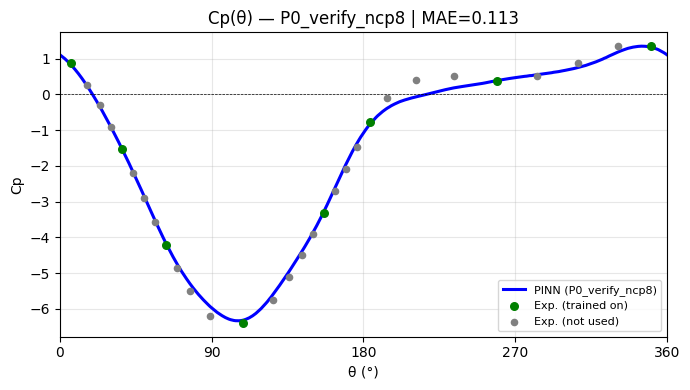

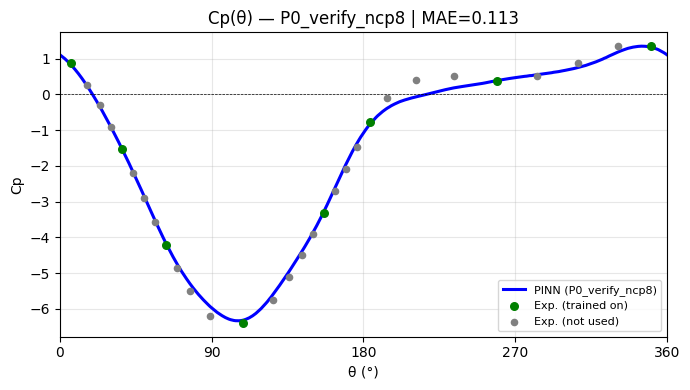

In [ ]:
# @title
# ---- EDIT THESE TWO PATHS FIRST ----
DATA_DIR = "/content/drive/MyDrive/PINN_Flettner2"   # must contain CP_data.xlsx, CL_data.xlsx, CD_data.xlsx
OUT_DIR  = "/content/drive/MyDrive/PINN_Flettner2/runs"   # checkpoints + results get saved here
# -------------------------------------

import os
os.makedirs(OUT_DIR, exist_ok=True)

cfg = core.RunConfig(
    run_id="P0_verify_ncp8",
    RE=3.6e5, ALPHA=2.0, NCp=8,
    cp_selection="evenly_spaced_index",
    seed=0,
    notes="Step 0 trust check — should reproduce MAE~0.219, CL~5.046, CD~1.692",
)

data = core.load_bordogna(DATA_DIR, cfg)
result = core.train(cfg, data, OUT_DIR)
eval_result = core.evaluate(cfg, result["model"], data, result["cp_selection"], OUT_DIR)
print(eval_result["metrics"])
eval_result["fig"]

## 5. Next steps

Once Step 0 checks out, the full run plan (Step 1 full-data hyperparameter search, Step 2 NCp sweep + seeds, Step 3 physics-only diagnostics + RI-PINN, Step 4 sector-masking scenarios) is in `running_and_code_strategy_v3.md`, saved in the project. Each step is just a different `RunConfig` passed to the same three calls above (`load_bordogna` → `train` → `evaluate`, plus `core.flow_field_diagnostics(cfg, result["model"], eval_result)` for the flow-field figures).

## 6. Step 1 — full-data hyperparameter search

This is the search described in the strategy doc: find the best network size, data-loss weight, and collocation-point count using **all** available Cp points (`NCp=999` grabs everything automatically — no new code needed). Do this before Step 2, so the NCp sweep isn't confounded by a bad architecture choice.

A helper function first, so the loops below don't repeat the same four lines:

In [ ]:
# @title
import pandas as pd

# Lower than the module default (1000) on purpose, given an unstable
# connection — caps how many epochs of a single run are ever at risk
# to a disconnect, at the cost of slightly more frequent Drive I/O.
CHECKPOINT_EVERY = 250

def run_one(cfg, data, out_dir=OUT_DIR):
    """train + evaluate one RunConfig, return a flat dict of metrics.
    Reuses whatever checkpoint already exists for cfg.run_id (resume-safe) --
    rerunning this after a disconnect just picks up where it left off.
    Ledger writes are de-duplicated by run_id, so re-running a cell that
    includes an already-completed run does not create duplicate rows."""
    result = core.train(cfg, data, out_dir, checkpoint_every=CHECKPOINT_EVERY)
    ev = core.evaluate(cfg, result["model"], data, result["cp_selection"], out_dir)
    m = ev["metrics"]

    ledger_path = f"{out_dir}/ledger.csv"
    already_logged = False
    if os.path.exists(ledger_path):
        try:
            existing = pd.read_csv(ledger_path)
            already_logged = cfg.run_id in existing.get("run_id", pd.Series(dtype=str)).values
        except Exception:
            pass
    if not already_logged:
        core.append_to_ledger(cfg, m, result["elapsed_min"], ledger_path, source="app")

    return {"run_id": cfg.run_id, "model": result["model"], "eval": ev,
            "history": result["history"], "cp_selection": result["cp_selection"],
            **m, "elapsed_min": result["elapsed_min"]}

# Load the real experimental data once -- Steps 1, 2, and 4 all use the
# paper's actual condition (Re=3.6e5, alpha=2), so no need to reload per run.
base_cfg = core.RunConfig(run_id="_probe", RE=3.6e5, ALPHA=2.0)
data_main = core.load_bordogna(DATA_DIR, base_cfg)
print(f"Loaded {len(data_main['theta_exp'])} Cp points | CL_ref={data_main['cl_ref']:.3f} CD_ref={data_main['cd_ref']:.3f}")

Loaded 30 Cp points | CL_ref=5.917 CD_ref=1.745


✓ Run 'S1_arch_d4_w96' already completed — skipping training.
✓ Run 'S1_arch_d4_w128' already completed — skipping training.
✓ Run 'S1_arch_d4_w160' already completed — skipping training.
✓ Run 'S1_arch_d5_w96' already completed — skipping training.
✓ Run 'S1_arch_d5_w128' already completed — skipping training.
✓ Run 'S1_arch_d5_w160' already completed — skipping training.
✓ Run 'S1_arch_d6_w96' already completed — skipping training.
✓ Run 'S1_arch_d6_w128' already completed — skipping training.
✓ Run 'S1_arch_d6_w160' already completed — skipping training.


,run_id,MAE,CL_err_pct,CD_err_pct,elapsed_min
8,S1_arch_d6_w160,0.048608,13.086214,3.239052,None
5,S1_arch_d5_w160,0.034986,13.498790,3.690380,None
4,S1_arch_d5_w128,0.041675,13.508113,3.253004,None
6,S1_arch_d6_w96,0.045901,13.519677,3.129868,None
7,S1_arch_d6_w128,0.033396,13.549986,3.353920,None
2,S1_arch_d4_w160,0.081043,13.632611,2.747849,None
3,S1_arch_d5_w96,0.091295,13.974472,3.490802,None
1,S1_arch_d4_w128,0.063409,14.053059,4.032094,None
0,S1_arch_d4_w96,0.114866,15.092770,2.952326,None


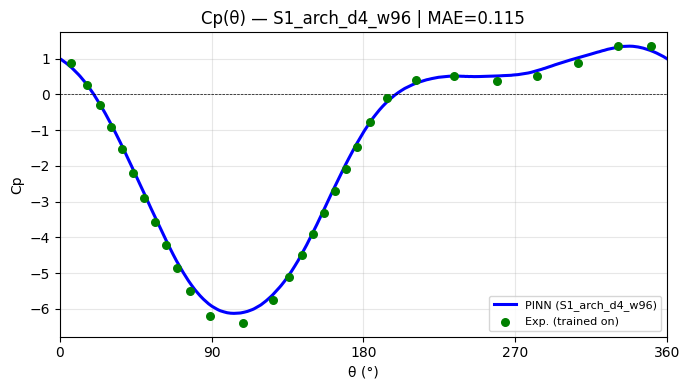

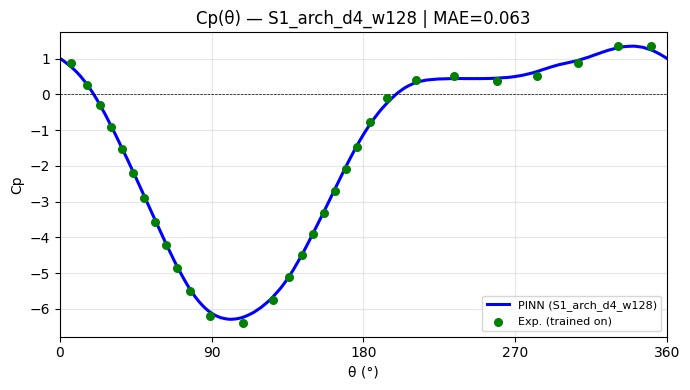

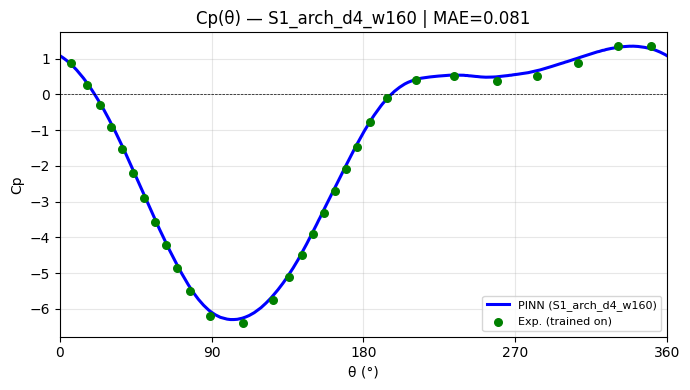

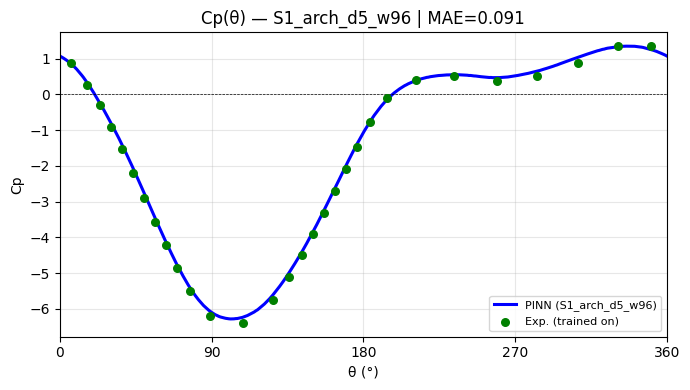

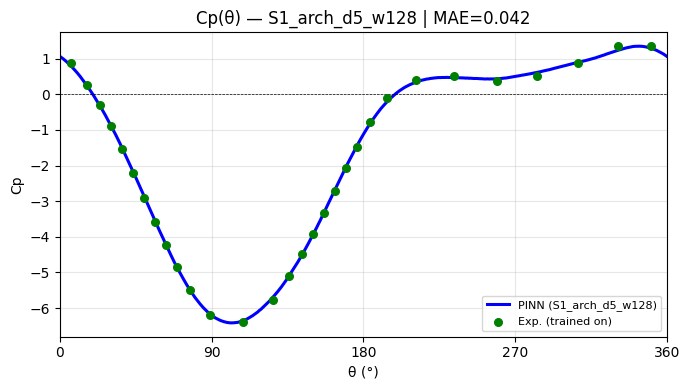

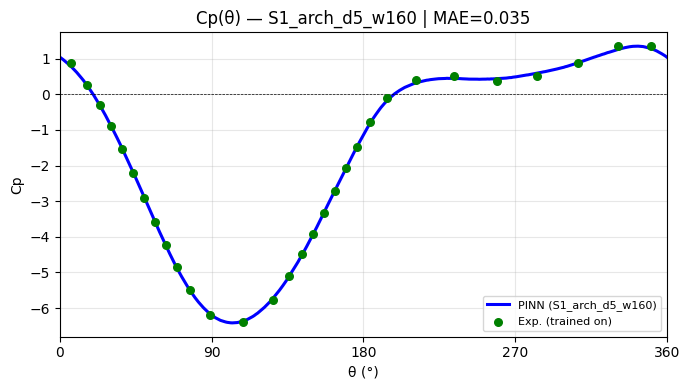

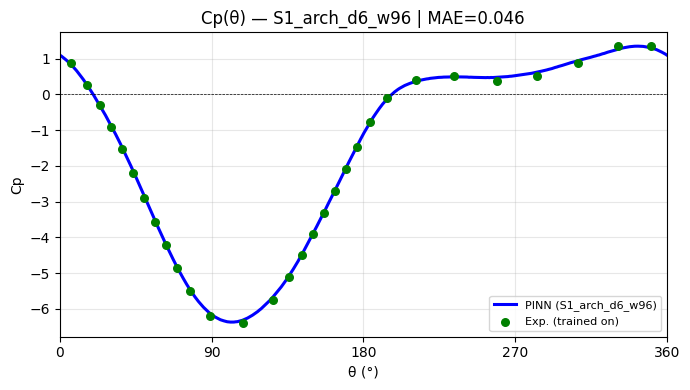

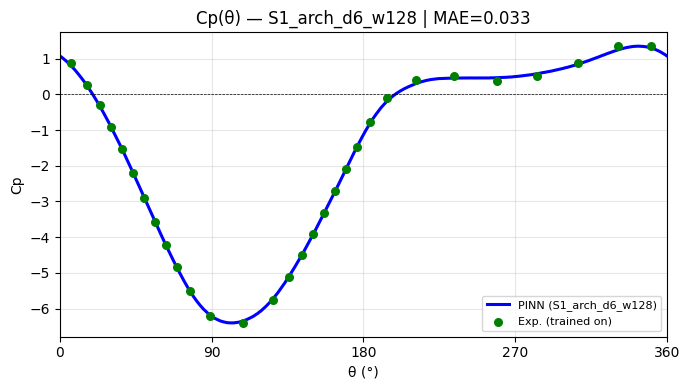

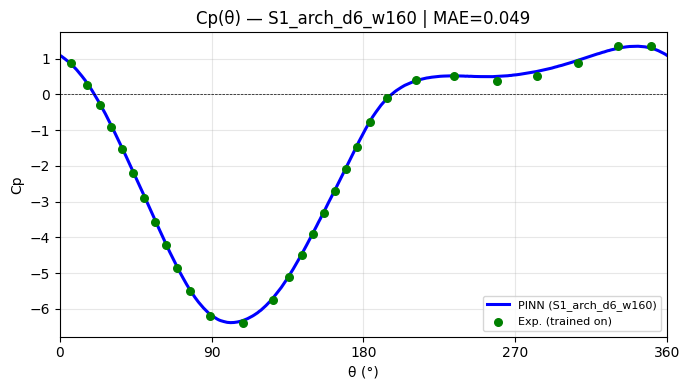

In [ ]:
# @title
# ---- Step 1a: network size sweep (replaces old Appendix Fig. 5) ----
import pandas as pd

rows = []
for depth in [4, 5, 6]:
    for width in [96, 128, 160]:
        cfg = core.RunConfig(
            run_id=f"S1_arch_d{depth}_w{width}",
            RE=3.6e5, ALPHA=2.0, NCp=999, cp_selection="evenly_spaced_index",
            net_depth=depth, net_width=width, seed=0,
            notes="Step 1a — network-size sweep, full data",
        )
        r = run_one(cfg, data_main)
        rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_arch = pd.DataFrame(rows)
df_arch.to_csv(f"{OUT_DIR}/step1a_architecture_results.csv", index=False)
df_arch.sort_values("CL_err_pct")[["run_id", "MAE", "CL_err_pct", "CD_err_pct", "elapsed_min"]]

Look at `df_arch` above and pick the smallest network where C_L/C_D error stops improving (not necessarily the lowest-error one — that may just be overfitting or a slower network for no real gain). Set the two variables below to your choice before running Step 1b.

In [ ]:
BEST_DEPTH = 6    # confirmed Step 1a winner: 6 layers x 128 units
BEST_WIDTH = 128

# ---- Step 1b: data-loss weight sweep, depth-6 rerun (correct architecture) ----
rows = []
for w_cp in [1, 10, 50, 100, 500]:
    cfg = core.RunConfig(
        run_id=f"S1_wcp_{w_cp}_d6",   # new run_id -> won't try to load the old depth-5 checkpoint
        RE=3.6e5, ALPHA=2.0, NCp=999, cp_selection="evenly_spaced_index",
        net_depth=BEST_DEPTH, net_width=BEST_WIDTH, W_CP=float(w_cp), seed=0,
        notes="Step 1b — data-loss weight sweep, depth-6 rerun (correct architecture)",
    )
    r = run_one(cfg, data_main)
    rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_wcp_d6 = pd.DataFrame(rows)
df_wcp_d6.to_csv(f"{OUT_DIR}/step1b_dataweight_results_d6.csv", index=False)
df_wcp_d6.sort_values("CL_err_pct")[["run_id", "MAE", "CL_err_pct", "CD_err_pct"]]

↻ Resuming 'S1_wcp_1_d6' from epoch 1001
Training 'S1_wcp_1_d6': epochs 1001→6000 | alpha=2.0 NCp=999 (train points=30) R_OUT=25.0 hard_constrain=False


KeyboardInterrupt: 

✓ Run 'S1_nint_2000_d6' already completed — skipping training.
✓ Run 'S1_nint_5000_d6' already completed — skipping training.
✓ Run 'S1_nint_10000_d6' already completed — skipping training.
✓ Run 'S1_nint_15000_d6' already completed — skipping training.
✓ Run 'S1_nint_20000_d6' already completed — skipping training.
✓ Run 'S1_nint_40000_d6' already completed — skipping training.
✓ Run 'S1_nint_50000_d6' already completed — skipping training.


,run_id,MAE,CL_err_pct,CD_err_pct,elapsed_min
5,S1_nint_40000_d6,0.052986,13.038846,5.146086,None
4,S1_nint_20000_d6,0.040781,13.236571,3.580322,None
6,S1_nint_50000_d6,0.038260,13.247120,3.685467,None
0,S1_nint_2000_d6,0.049080,13.255146,3.808807,None
3,S1_nint_15000_d6,0.038521,13.292280,3.985592,None
1,S1_nint_5000_d6,0.026593,13.308373,3.706866,None
2,S1_nint_10000_d6,0.038974,13.314087,3.642169,None


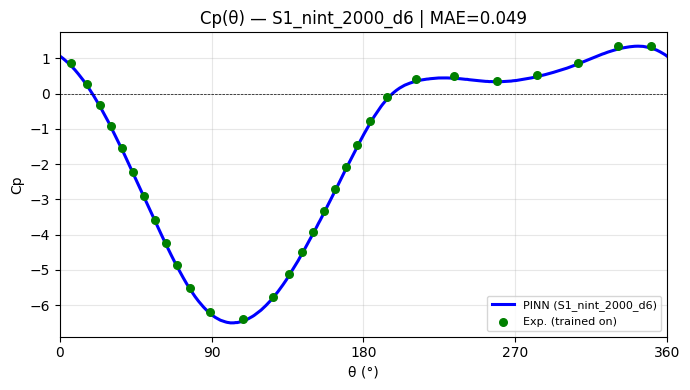

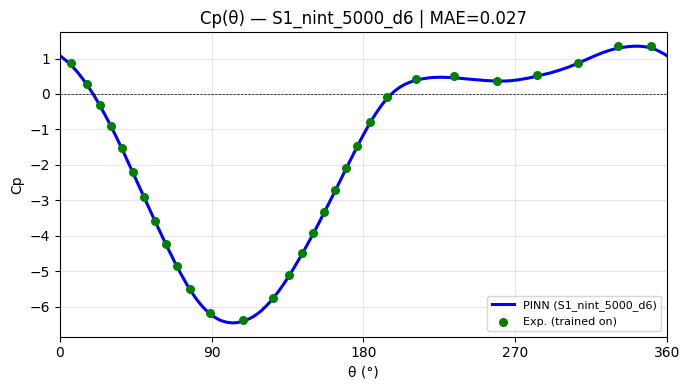

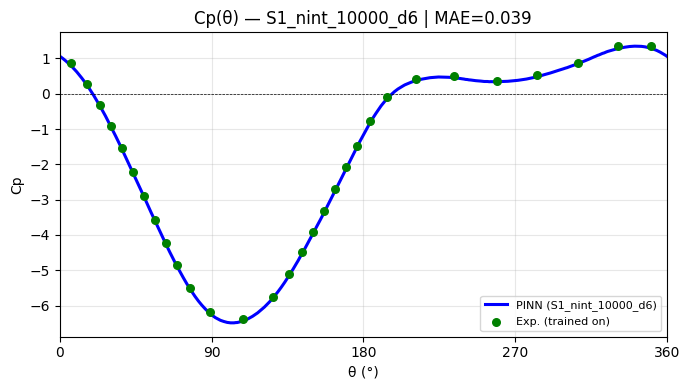

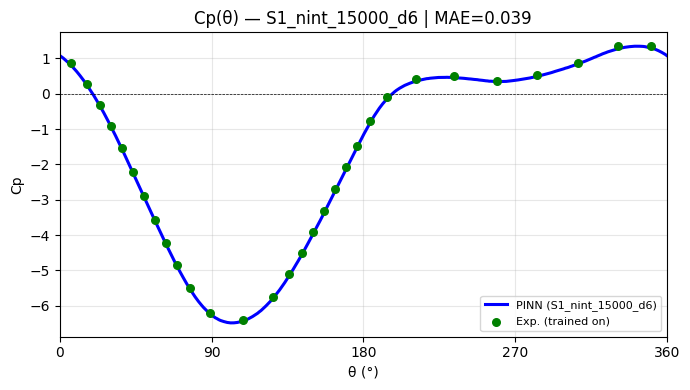

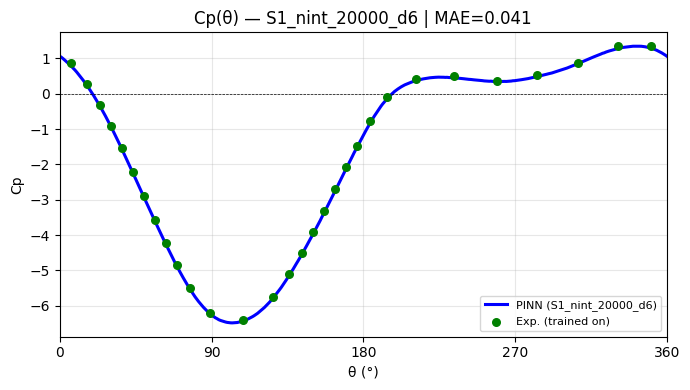

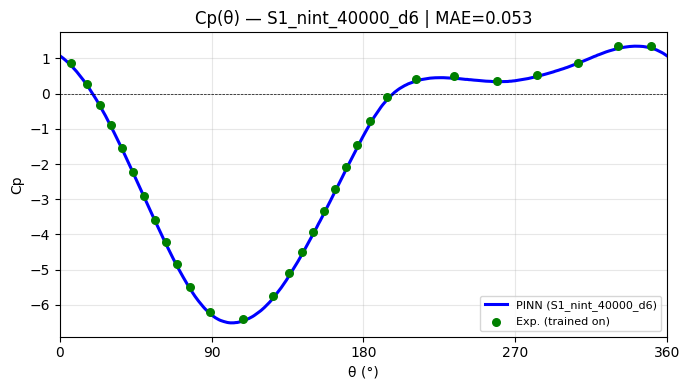

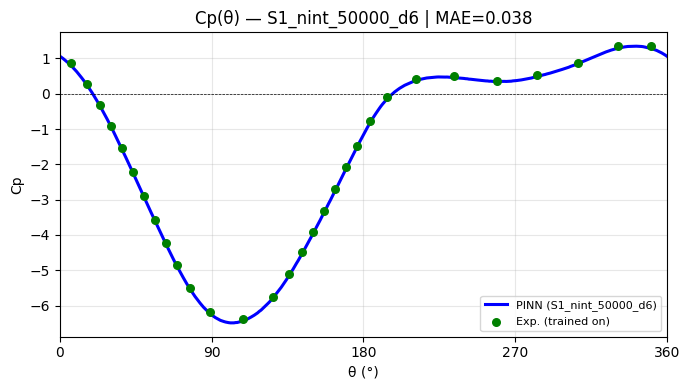

In [ ]:
# @title
BEST_W_CP = 50  # confirmed Step 1b winner at the correct depth-6 architecture

# ---- Step 1c: collocation-point count sweep, depth-6 rerun ----
rows = []
for n_int in [2000,5000, 10000,15000, 20000,40000, 50000]:
    cfg = core.RunConfig(
        run_id=f"S1_nint_{n_int}_d6",   # new run_id -> won't collide with the old depth-5 checkpoint
        RE=3.6e5, ALPHA=2.0, NCp=999, cp_selection="evenly_spaced_index",
        net_depth=BEST_DEPTH, net_width=BEST_WIDTH, W_CP=BEST_W_CP,
        N_INT=n_int, seed=0,
        notes="Step 1c — collocation-point sweep, depth-6 rerun (correct architecture)",
    )
    r = run_one(cfg, data_main)
    rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_nint_d6 = pd.DataFrame(rows)
df_nint_d6.to_csv(f"{OUT_DIR}/step1c_collocation_results_d6.csv", index=False)
df_nint_d6.sort_values("CL_err_pct")[["run_id", "MAE", "CL_err_pct", "CD_err_pct", "elapsed_min"]]

In [ ]:
# ---- Re-apply fixes before generating Step1c collocation-point figures ----
import importlib.util, inspect, matplotlib.pyplot as plt

# 1) Ensure core.sample_functions is the true original (no wake-box/near-wall bias)
spec = importlib.util.spec_from_file_location("core_original", core.__file__)
core_original = importlib.util.module_from_spec(spec)
spec.loader.exec_module(core_original)
core.sample_functions = core_original.sample_functions

# 2) Fixed plot: cylinder disk drawn FIRST (low zorder) so the wall points,
#    plotted after it, are not hidden under its edge at r=R_IN; slightly
#    larger wall/far-field markers; zoom-panel title clarifies that the
#    far-field ring (r=R_OUT) isn't in view on that panel.
def plot_collocation_points_fixed(cfg, n_interior=800, n_wall=None, n_ff=None,
                                   save_path=None, ensure_drive_fn=None):
    sample_interior, sample_wall, sample_ff = core.sample_functions(cfg)
    xi, yi = sample_interior(n_interior)
    xw, yw = sample_wall(n_wall or cfg.N_WALL)
    xf, yf = sample_ff(n_ff or cfg.N_FF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, zoom in zip(axes, [False, True]):
        ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray",
                                 edgecolor="k", zorder=1))
        ax.scatter(xi, yi, s=4, c="tab:blue", alpha=.5, zorder=2,
                   label=f"Interior (N={n_interior})")
        ax.scatter(xw, yw, s=14, c="tab:red", zorder=3, label=f"Wall (N={len(xw)})")
        ax.scatter(xf, yf, s=14, c="tab:green", zorder=3, label=f"Far-field (N={len(xf)})")
        ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        if zoom:
            ext = cfg.R_IN * 6
            ax.set_title(f"Near-wall detail (Β±{ext:.1f}D) β€” far-field ring at r={cfg.R_OUT:.0f}D is outside this view")
        else:
            ext = cfg.R_OUT * 1.05
            ax.set_title(f"Full domain (R_out={cfg.R_OUT:.0f}D)")
        ax.set_xlim([-ext, ext]); ax.set_ylim([-ext, ext])
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        core._verify_saved_fig(save_path)
    return fig

core.plot_collocation_points = plot_collocation_points_fixed

print("Patched. Verifying sample_functions is the original:")
print(inspect.getsource(core.sample_functions))

Patched. Verifying sample_functions is the original:
def sample_functions(cfg: RunConfig):
    def sample_interior(n):
        th = np.random.uniform(0, 2 * np.pi, n).astype(np.float32)
        r = np.exp(np.random.uniform(np.log(cfg.R_IN), np.log(cfg.R_OUT), n)).astype(np.float32)
        return (r * np.cos(th)).reshape(-1, 1), (r * np.sin(th)).reshape(-1, 1)

    def sample_wall(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (-cfg.R_IN * np.cos(th)).reshape(-1, 1), (+cfg.R_IN * np.sin(th)).reshape(-1, 1)

    def sample_ff(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (cfg.R_OUT * np.cos(th)).reshape(-1, 1), (cfg.R_OUT * np.sin(th)).reshape(-1, 1)

    return sample_interior, sample_wall, sample_ff



In [ ]:
# ---- Re-apply fixes before generating Step1c collocation-point figures ----
import importlib.util, inspect, matplotlib.pyplot as plt

# 1) Ensure core.sample_functions is the true original (no wake-box/near-wall bias)
spec = importlib.util.spec_from_file_location("core_original", core.__file__)
core_original = importlib.util.module_from_spec(spec)
spec.loader.exec_module(core_original)
core.sample_functions = core_original.sample_functions

# 2) Fixed plot: cylinder disk drawn FIRST (low zorder) so the wall points,
#    plotted after it, are not hidden under its edge at r=R_IN; slightly
#    larger wall/far-field markers; zoom-panel title clarifies that the
#    far-field ring (r=R_OUT) isn't in view on that panel.
def plot_collocation_points_fixed(cfg, n_interior=800, n_wall=None, n_ff=None,
                                   save_path=None, ensure_drive_fn=None):
    sample_interior, sample_wall, sample_ff = core.sample_functions(cfg)
    xi, yi = sample_interior(n_interior)
    xw, yw = sample_wall(n_wall or cfg.N_WALL)
    xf, yf = sample_ff(n_ff or cfg.N_FF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, zoom in zip(axes, [False, True]):
        ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray",
                                 edgecolor="k", zorder=1))
        ax.scatter(xi, yi, s=4, c="tab:blue", alpha=.5, zorder=2,
                   label=f"Interior (N={n_interior})")
        ax.scatter(xw, yw, s=14, c="tab:red", zorder=3, label=f"Wall (N={len(xw)})")
        ax.scatter(xf, yf, s=14, c="tab:green", zorder=3, label=f"Far-field (N={len(xf)})")
        ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        if zoom:
            ext = cfg.R_IN * 6
            ax.set_title(f"Near-wall detail (Β±{ext:.1f}D) β€” far-field ring at r={cfg.R_OUT:.0f}D is outside this view")
        else:
            ext = cfg.R_OUT * 1.05
            ax.set_title(f"Full domain (R_out={cfg.R_OUT:.0f}D)")
        ax.set_xlim([-ext, ext]); ax.set_ylim([-ext, ext])
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        core._verify_saved_fig(save_path)
    return fig

core.plot_collocation_points = plot_collocation_points_fixed

print("Patched. Verifying sample_functions is the original:")
print(inspect.getsource(core.sample_functions))

Patched. Verifying sample_functions is the original:
def sample_functions(cfg: RunConfig):
    def sample_interior(n):
        th = np.random.uniform(0, 2 * np.pi, n).astype(np.float32)
        r = np.exp(np.random.uniform(np.log(cfg.R_IN), np.log(cfg.R_OUT), n)).astype(np.float32)
        return (r * np.cos(th)).reshape(-1, 1), (r * np.sin(th)).reshape(-1, 1)

    def sample_wall(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (-cfg.R_IN * np.cos(th)).reshape(-1, 1), (+cfg.R_IN * np.sin(th)).reshape(-1, 1)

    def sample_ff(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (cfg.R_OUT * np.cos(th)).reshape(-1, 1), (cfg.R_OUT * np.sin(th)).reshape(-1, 1)

    return sample_interior, sample_wall, sample_ff



  💾 figure verified: fig_collocation_points_nint2000.png ✓
N_int=2000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint2000.png


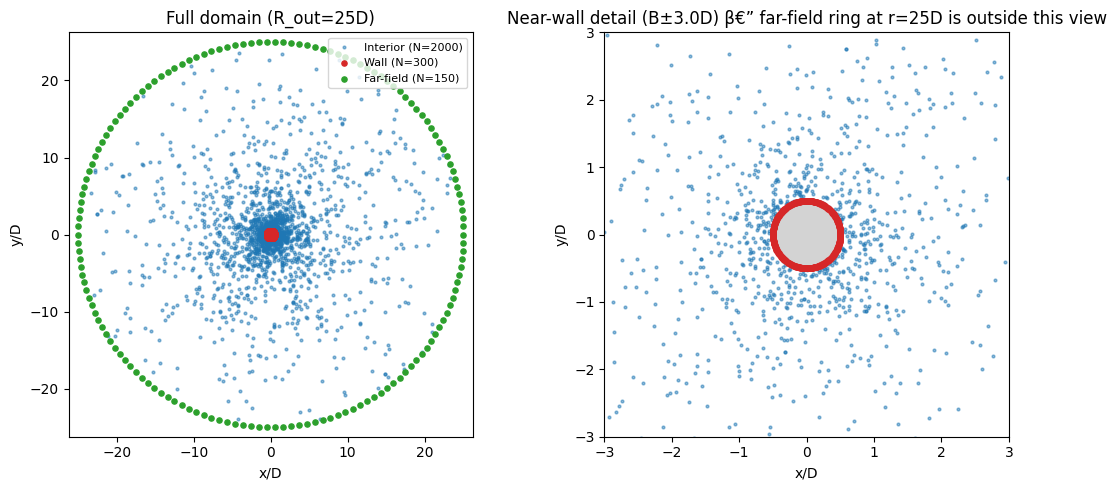

  💾 figure verified: fig_collocation_points_nint5000.png ✓
N_int=5000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint5000.png


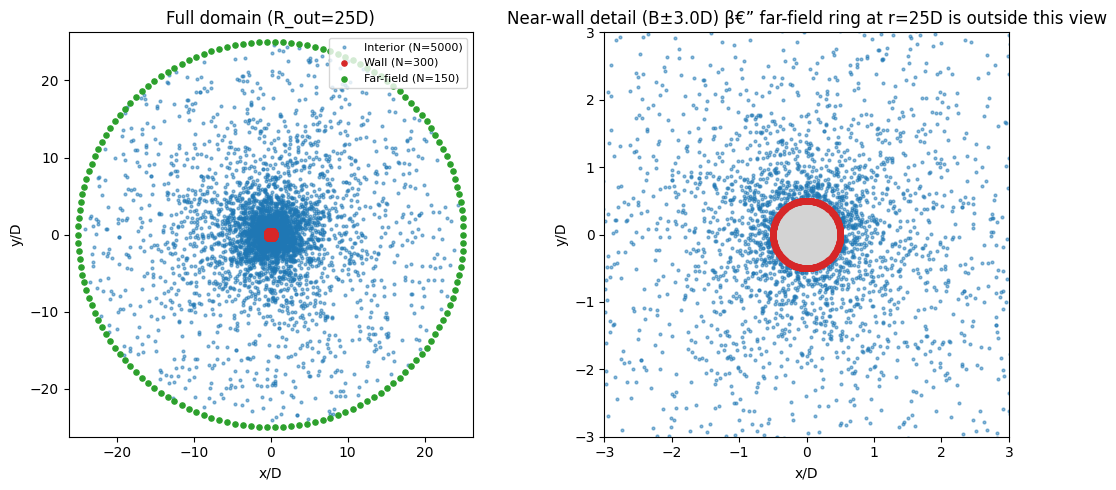

  💾 figure verified: fig_collocation_points_nint10000.png ✓
N_int=10000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint10000.png


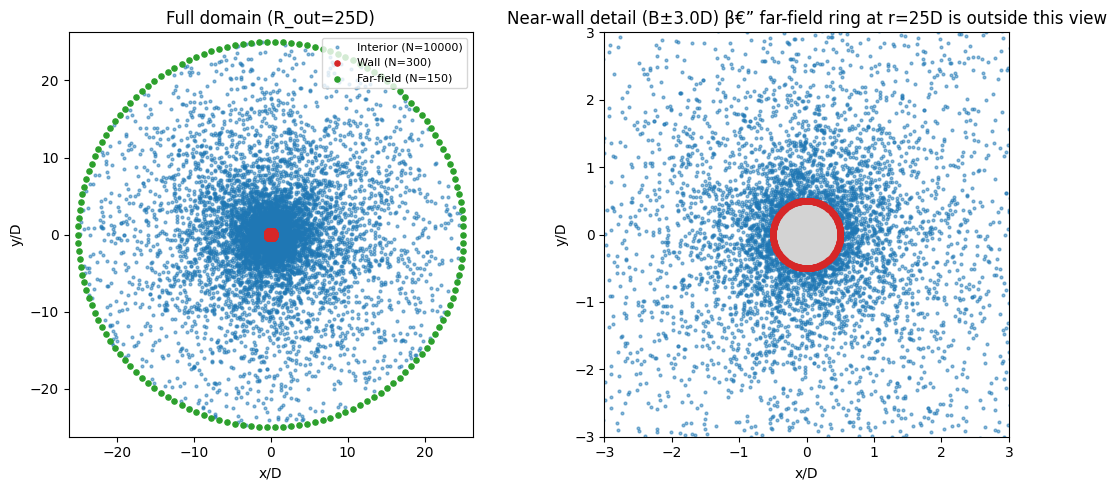

  💾 figure verified: fig_collocation_points_nint15000.png ✓
N_int=15000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint15000.png


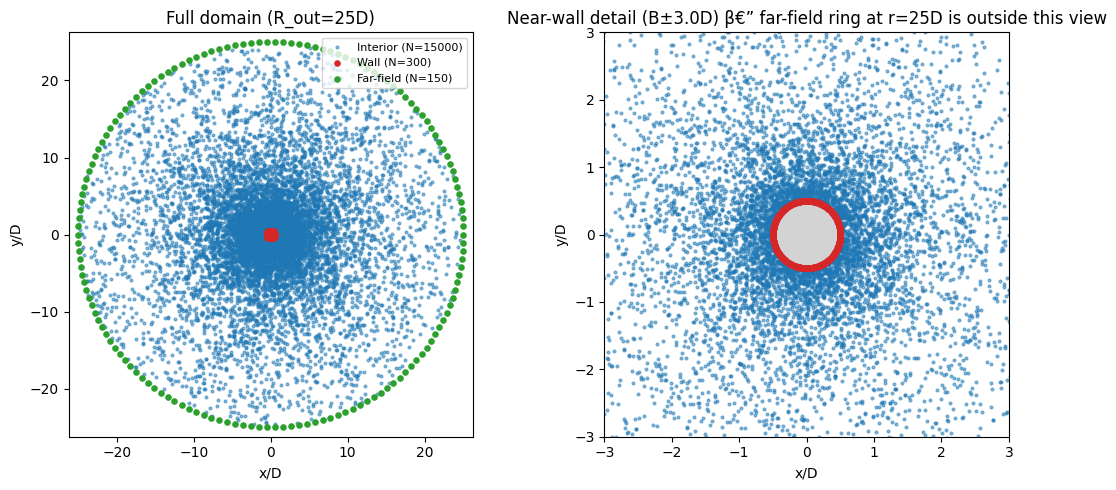

  💾 figure verified: fig_collocation_points_nint20000.png ✓
N_int=20000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint20000.png


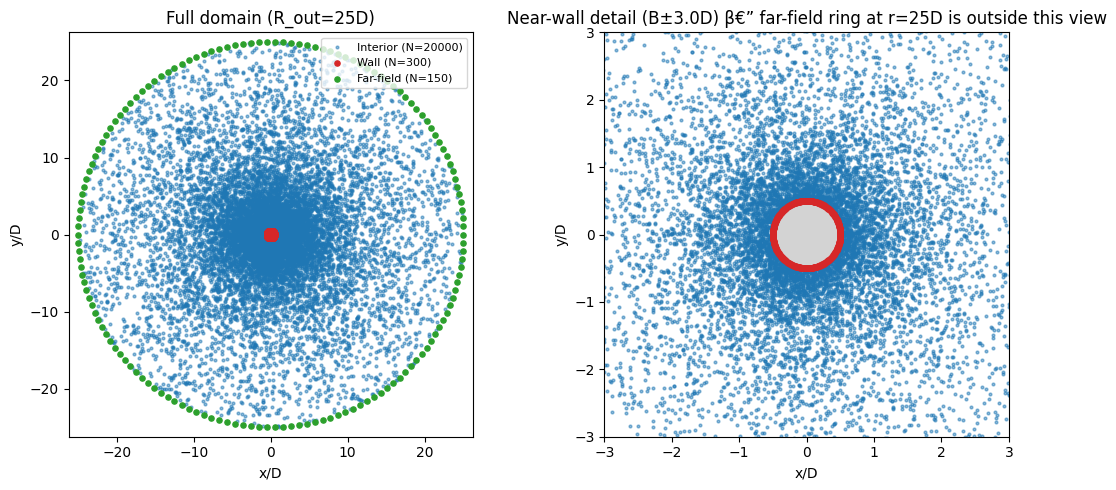

  💾 figure verified: fig_collocation_points_nint40000.png ✓
N_int=40000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint40000.png


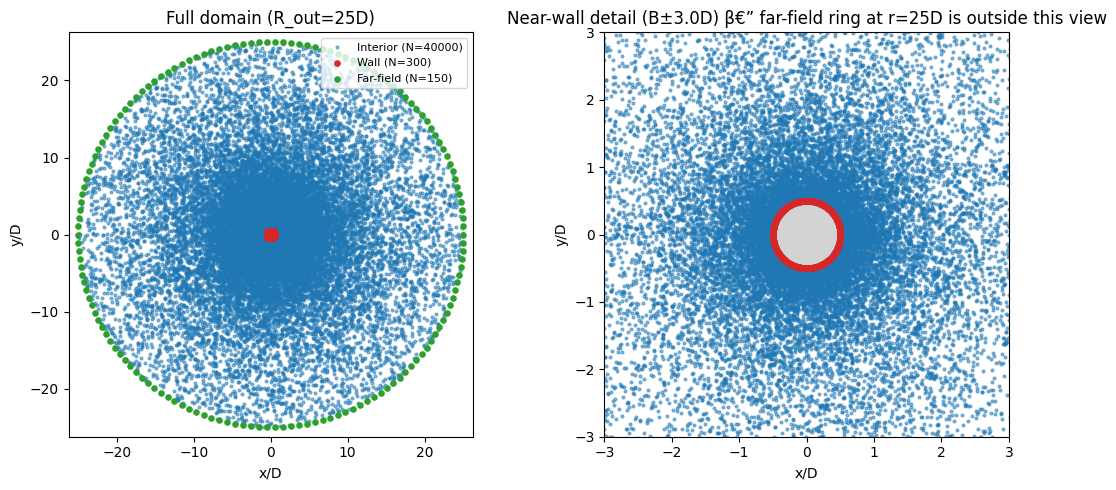

  💾 figure verified: fig_collocation_points_nint50000.png ✓
N_int=50000: saved to /content/drive/MyDrive/PINN_Flettner2/runs/fig_collocation_points_nint50000.png


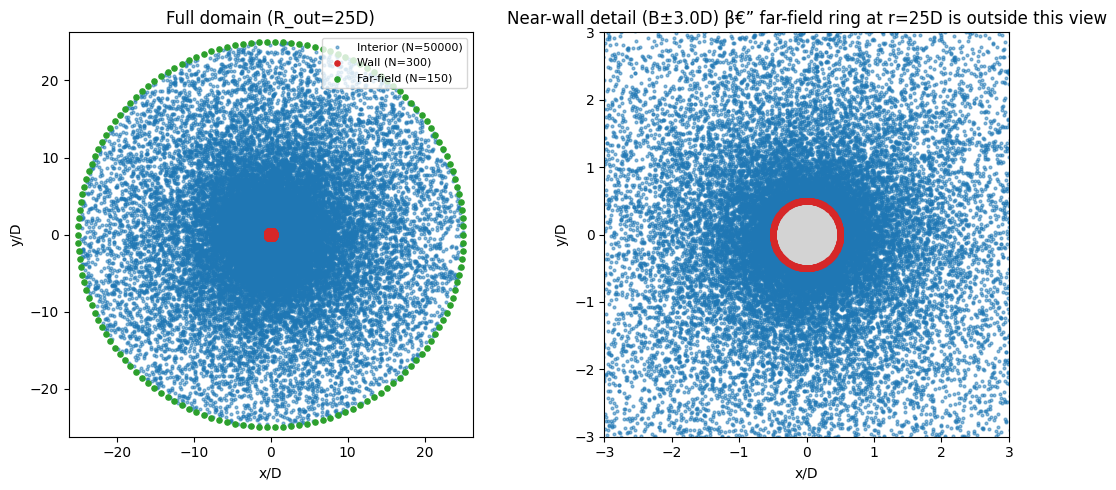

In [ ]:
# ---- Plot collocation points for each Step 1c N_int case ----
# Uses core.plot_collocation_points(), which calls the SAME sample_functions()
# that train() actually uses — this shows the real sampling, not a re-implementation.
import matplotlib.pyplot as plt

N_INT_CASES = [2000,5000, 10000,15000, 20000,40000, 50000]
BEST_DEPTH, BEST_WIDTH, BEST_W_CP = 6, 128, 50   # confirmed Step 1a/1b winners

for n_int in N_INT_CASES:
    cfg = core.RunConfig(
        run_id=f"viz_only_{n_int}",   # not trained — just carries R_IN/R_OUT/N_WALL/N_FF for the plot
        RE=3.6e5, ALPHA=2.0, NCp=999, cp_selection="evenly_spaced_index",
        net_depth=BEST_DEPTH, net_width=BEST_WIDTH, W_CP=BEST_W_CP,
        N_INT=n_int, seed=0,
    )
    save_path = f"{OUT_DIR}/fig_collocation_points_nint{n_int}.png"
    fig = core.plot_collocation_points(cfg, n_interior=n_int, save_path=save_path,
                                    ensure_drive_fn=core.ensure_drive)
    print(f"N_int={n_int}: saved to {save_path}")
    plt.show()

In [ ]:
def plot_collocation_points_fixed(cfg, n_interior=800, n_wall=None, n_ff=None,
                                   save_path=None, ensure_drive_fn=None):
    sample_interior, sample_wall, sample_ff = core.sample_functions(cfg)
    xi, yi = sample_interior(n_interior)
    xw, yw = sample_wall(n_wall or cfg.N_WALL)
    xf, yf = sample_ff(n_ff or cfg.N_FF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, zoom in zip(axes, [False, True]):
        # disk drawn FIRST with a low zorder, so points plotted after it
        # (higher zorder, matplotlib's default for later artists) sit on top
        # instead of being painted over by the disk's edge at r=R_IN
        ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray",
                                 edgecolor="k", zorder=1))
        ax.scatter(xi, yi, s=4, c="tab:blue", alpha=.5, zorder=2,
                   label=f"Interior (N={n_interior})")
        ax.scatter(xw, yw, s=14, c="tab:red", zorder=3, label=f"Wall (N={len(xw)})")
        ax.scatter(xf, yf, s=14, c="tab:green", zorder=3, label=f"Far-field (N={len(xf)})")
        ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        if zoom:
            ext = cfg.R_IN * 6
            ax.set_title(f"Near-wall detail (Β±{ext:.1f}D) β€” far-field ring at r={cfg.R_OUT:.0f}D is outside this view")
        else:
            ext = cfg.R_OUT * 1.05
            ax.set_title(f"Full domain (R_out={cfg.R_OUT:.0f}D)")
        ax.set_xlim([-ext, ext]); ax.set_ylim([-ext, ext])
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        core._verify_saved_fig(save_path)
    return fig

core.plot_collocation_points = plot_collocation_points_fixed

In [ ]:
# @title
# ── Sensitivity check: does C_L/C_D depend on the force-integration grid? ──
# This does NOT retrain anything — it reloads a completed checkpoint and
# re-runs only the force integration at different settings. Takes seconds.

# 1) Rebuild the exact config used to train S1_wcp_50, then load its weights.
cfg_check = core.RunConfig(
    run_id="S1_wcp_50_d6",         # <-- the depth-6 checkpoint, not the old depth-5 one
    RE=3.6e5, ALPHA=2.0,
    NCp=999, W_CP=50,
    net_depth=6, net_width=128,
    seed=0,
)
model_check = core.build_model(cfg_check)
model_check.load_weights(f"{OUT_DIR}/{cfg_check.run_id}.weights.h5")
print(f"Loaded weights for '{cfg_check.run_id}' OK")

# 2) Generalized force-integration routine (same math as core.evaluate(),
#    lines computing CL_p/CD_p — but n_f and fd_eps are now adjustable).
def force_integration_check(cfg, model, data, n_f=512, fd_eps=1e-3):
    make_input = core.make_input_fn(cfg)

    def get_p_ref(n=256):
        th = np.linspace(0, 2*np.pi, n, dtype=np.float32)
        xy = make_input((cfg.R_OUT*np.cos(th)).reshape(-1,1),
                         (cfg.R_OUT*np.sin(th)).reshape(-1,1))
        return float(core.get_uvp(model(xy, training=False)).numpy()[:, 2].mean())

    th_deg = np.linspace(0, 360, 360, dtype=np.float32)
    th_rad = np.radians(th_deg)
    x = (-cfg.R_IN*np.cos(th_rad)).reshape(-1,1); y = (cfg.R_IN*np.sin(th_rad)).reshape(-1,1)
    Cp_raw = 2.*(core.get_uvp(model(make_input(x, y), training=False)).numpy()[:, 2] - get_p_ref())
    p_shift = (float(data["cp_exp"].max()) - Cp_raw.max()) / 2.
    pr = get_p_ref()

    dth = 2*np.pi/n_f
    th_f = np.linspace(0, 2*np.pi, n_f, endpoint=False, dtype=np.float32)
    xf = (-cfg.R_IN*np.cos(th_f)).reshape(-1,1); yf = (cfg.R_IN*np.sin(th_f)).reshape(-1,1)
    nx, ny = xf/cfg.R_IN, yf/cfg.R_IN

    def uv(xp, yp):
        o = core.get_uvp(model(make_input(xp, yp), training=False)).numpy()
        return o[:, 0:1], o[:, 1:2], o[:, 2:3]

    _, _, p0 = uv(xf, yf); p0 = p0 - pr - p_shift
    uxp, vxp, _ = uv(xf+fd_eps, yf); uxm, vxm, _ = uv(xf-fd_eps, yf)
    uyp, vyp, _ = uv(xf, yf+fd_eps); uym, vym, _ = uv(xf, yf-fd_eps)
    du_dx = (uxp-uxm)/(2*fd_eps); du_dy = (uyp-uym)/(2*fd_eps)
    dv_dx = (vxp-vxm)/(2*fd_eps); dv_dy = (vyp-vym)/(2*fd_eps)
    nu_v = 1.0/cfg.RE
    txx = 2*nu_v*du_dx; txy = nu_v*(du_dy+dv_dx); tyy = 2*nu_v*dv_dy
    CL = float((np.sum(-p0*ny*cfg.R_IN*dth) + np.sum((txy*nx+tyy*ny)*cfg.R_IN*dth)) / .5)
    CD = float((np.sum(-p0*nx*cfg.R_IN*dth) + np.sum((txx*nx+txy*ny)*cfg.R_IN*dth)) / .5)
    return CL, CD

# 3) Sweep integration-grid resolution and FD step size independently.
cl_ref, cd_ref = data_main["cl_ref"], data_main["cd_ref"]
rows = []
for n_f in [128, 512, 2048]:
    CL, CD = force_integration_check(cfg_check, model_check, data_main, n_f=n_f, fd_eps=1e-3)
    rows.append({"sweep": "n_f", "value": n_f, "CL": CL, "CD": CD,
                 "CL_err_pct": abs(CL-cl_ref)/abs(cl_ref)*100,
                 "CD_err_pct": abs(CD-cd_ref)/abs(cd_ref)*100})
for fd_eps in [1e-2, 1e-3, 1e-4, 1e-5]:
    CL, CD = force_integration_check(cfg_check, model_check, data_main, n_f=512, fd_eps=fd_eps)
    rows.append({"sweep": "fd_eps", "value": fd_eps, "CL": CL, "CD": CD,
                 "CL_err_pct": abs(CL-cl_ref)/abs(cl_ref)*100,
                 "CD_err_pct": abs(CD-cd_ref)/abs(cd_ref)*100})

df_check = pd.DataFrame(rows)
print(df_check.to_string(index=False))
df_check.to_csv(f"{OUT_DIR}/integration_grid_sensitivity_check.csv", index=False)
core.ensure_drive()
print("Saved: integration_grid_sensitivity_check.csv")

Loaded weights for 'S1_wcp_50_d6' OK
 sweep      value       CL       CD  CL_err_pct  CD_err_pct
   n_f  128.00000 5.137164 1.792408   13.181491    2.732264
   n_f  512.00000 5.137089 1.792596   13.182756    2.742998
   n_f 2048.00000 5.136790 1.792322   13.187801    2.727331
fd_eps    0.01000 5.137089 1.792596   13.182756    2.743012
fd_eps    0.00100 5.137089 1.792596   13.182756    2.742998
fd_eps    0.00010 5.137094 1.792599   13.182667    2.743169
fd_eps    0.00001 5.137096 1.792597   13.182627    2.743087
Saved: integration_grid_sensitivity_check.csv


### Lock in `BEST_CFG_FIELDS`

Once Steps 1a–1c are done, collect your winners into one dict. Every step
below (2, 3b, 4) builds its `RunConfig` from this, so a hyperparameter
choice only has to be made once.

In [ ]:
BEST_CFG_FIELDS = dict(
    net_depth=BEST_DEPTH,
    net_width=BEST_WIDTH,
    W_CP=BEST_W_CP,
    N_INT=20000,   # <-- edit based on df_nint above
)
print(BEST_CFG_FIELDS)

{'net_depth': 6, 'net_width': 128, 'W_CP': 50, 'N_INT': 20000}


## 7. Step 2 — NCp sweep + seed variability

15 runs: {0, 4, 8, 16, 30} × 3 seeds, using the locked-in `BEST_CFG_FIELDS`. This directly produces the mean ± spread version of Table 3.

✓ Run 'S2_ncp0_s0_d6' already completed — skipping training.
✓ Run 'S2_ncp0_s1_d6' already completed — skipping training.
✓ Run 'S2_ncp0_s2_d6' already completed — skipping training.
✓ Run 'S2_ncp4_s0_d6' already completed — skipping training.
✓ Run 'S2_ncp4_s1_d6' already completed — skipping training.
✓ Run 'S2_ncp4_s2_d6' already completed — skipping training.
✓ Run 'S2_ncp8_s0_d6' already completed — skipping training.
✓ Run 'S2_ncp8_s1_d6' already completed — skipping training.
✓ Run 'S2_ncp8_s2_d6' already completed — skipping training.
✓ Run 'S2_ncp16_s0_d6' already completed — skipping training.
✓ Run 'S2_ncp16_s1_d6' already completed — skipping training.
✓ Run 'S2_ncp16_s2_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s0_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s1_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s2_d6' already completed — skipping training.


,n_train_points,MAE_mean,MAE_std,CL_err_mean,CL_err_std,CD_err_mean,CD_err_std
0,0,3.395164,0.002110,99.954816,0.182110,100.616023,0.295214
1,4,0.420804,0.028107,32.464707,2.106830,7.613663,2.232568
2,8,0.072594,0.004585,15.968863,0.537067,3.875830,1.701167
3,16,0.022105,0.003899,13.650681,0.047725,3.200899,0.536123
4,30,0.041712,0.003335,13.285828,0.036834,3.791589,0.169923


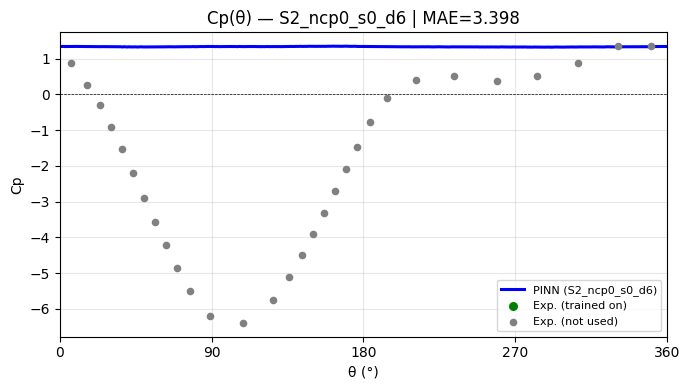

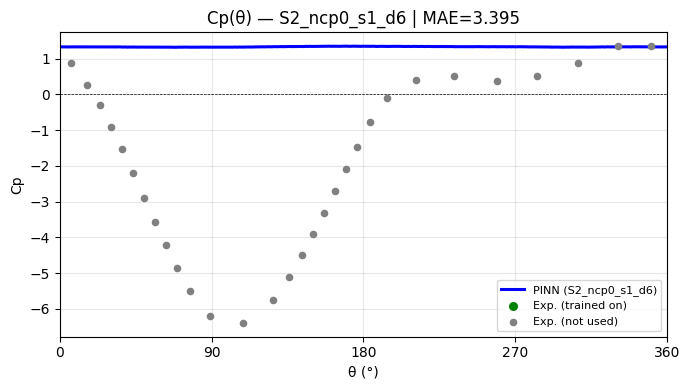

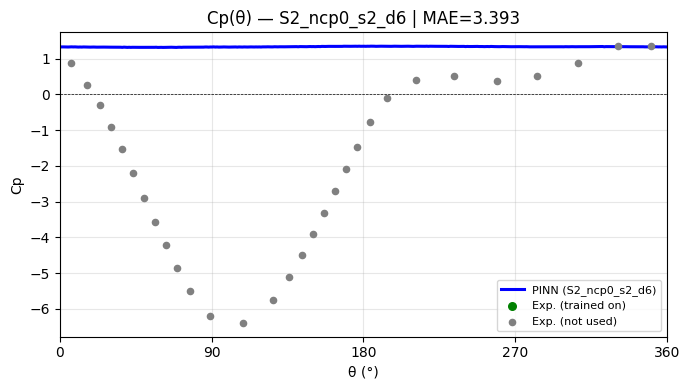

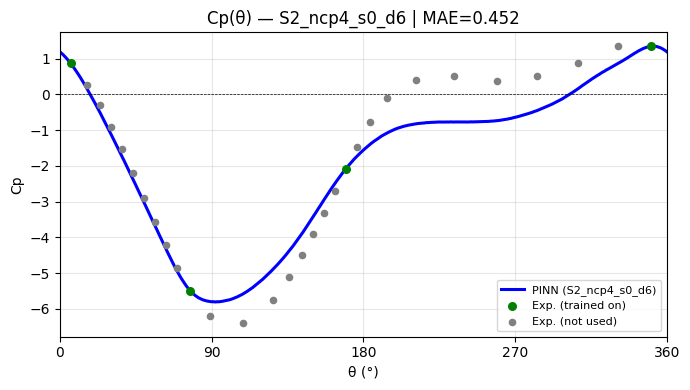

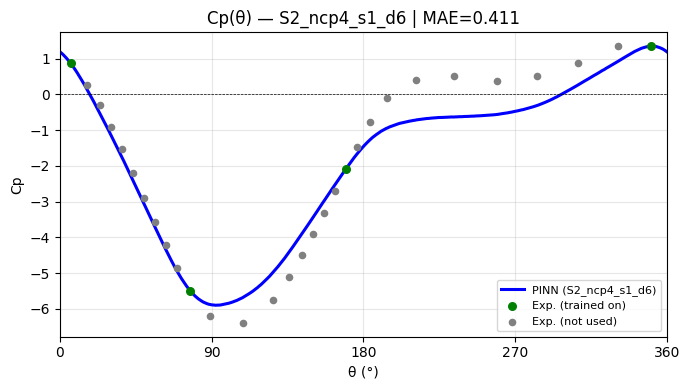

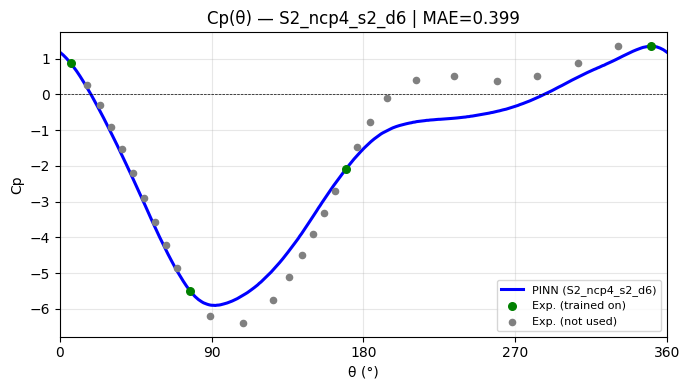

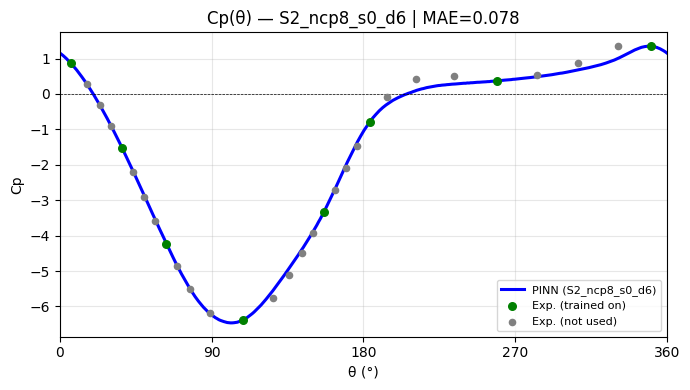

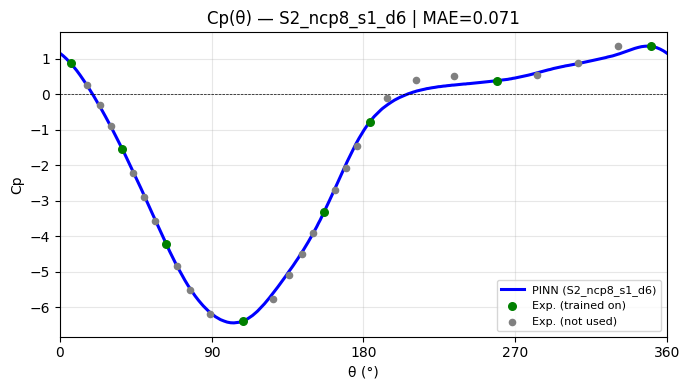

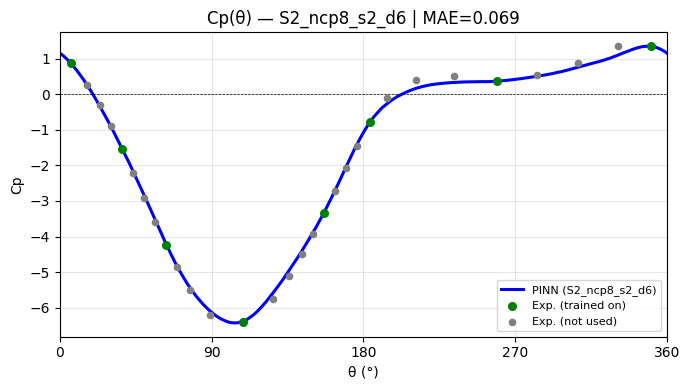

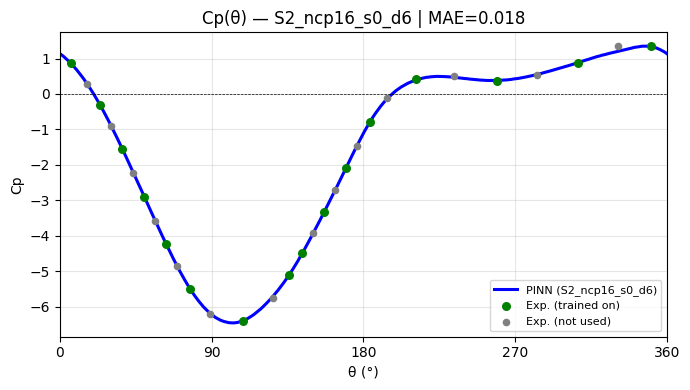

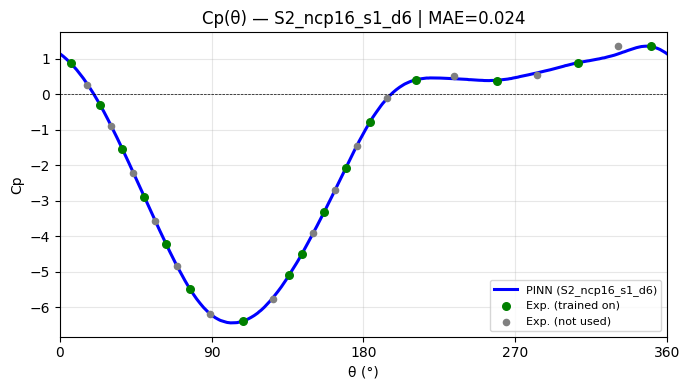

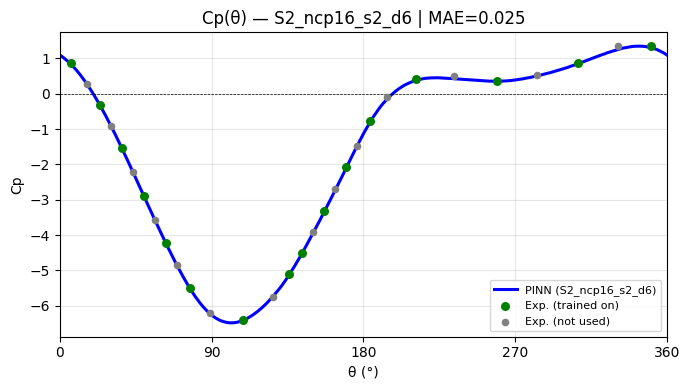

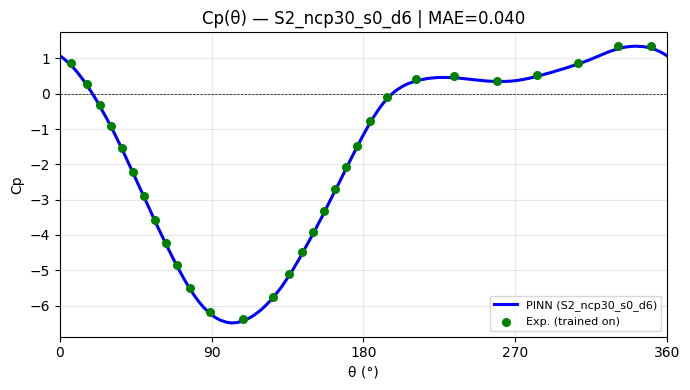

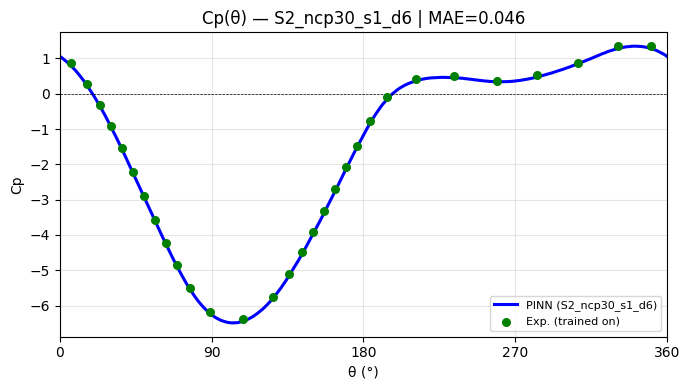

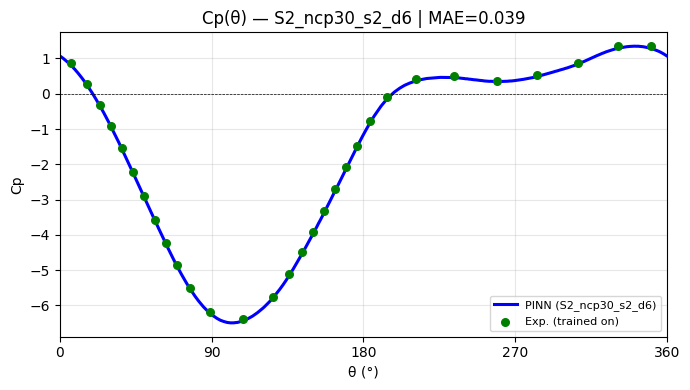

In [ ]:
rows = []
for ncp in [0, 4, 8, 16, 30]:
    for seed in [0, 1, 2]:
        cfg = core.RunConfig(
            run_id=f"S2_ncp{ncp}_s{seed}_d6",   # <-- new suffix, avoids the stale checkpoint
            RE=3.6e5, ALPHA=2.0, NCp=ncp, cp_selection="evenly_spaced_index",
            seed=seed, **BEST_CFG_FIELDS,
            notes="Step 2 — NCp sweep + seed variability (depth-6, correct architecture)",
        )
        r = run_one(cfg, data_main)
        rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_s2 = pd.DataFrame(rows)
df_s2.to_csv(f"{OUT_DIR}/step2_ncp_sweep_results_d6.csv", index=False)

# Mean +/- std per NCp — this is what goes in the manuscript's Table 3
summary = df_s2.groupby("n_train_points").agg(
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
    CL_err_mean=("CL_err_pct", "mean"), CL_err_std=("CL_err_pct", "std"),
    CD_err_mean=("CD_err_pct", "mean"), CD_err_std=("CD_err_pct", "std"),
).reset_index()
summary

In [ ]:
cfg30 = core.RunConfig(run_id="S2_ncp30_s0_d6", RE=3.6e5, ALPHA=2.0, NCp=30,
                        cp_selection="evenly_spaced_index", seed=0, **BEST_CFG_FIELDS,
                        notes="reload for per-point diagnostic")
result30 = core.train(cfg30, data_main, OUT_DIR)   # should print "already completed"
model30 = result30["model"]
sel30 = result30["cp_selection"]

make_input = core.make_input_fn(cfg30)
theta_train = data_main["theta_exp"][sel30["train_idx"]]
cp_train_exp = data_main["cp_exp"][sel30["train_idx"]]

th_ff = np.linspace(0, 2*np.pi, 256, dtype=np.float32)
xff = (cfg30.R_OUT*np.cos(th_ff)).reshape(-1,1); yff = (cfg30.R_OUT*np.sin(th_ff)).reshape(-1,1)
pr = core.get_uvp(model30(make_input(xff, yff), training=False)).numpy()[:,2].mean()

th_rad = np.radians(theta_train).astype(np.float32)
xw = (-cfg30.R_IN*np.cos(th_rad)).reshape(-1,1); yw = (cfg30.R_IN*np.sin(th_rad)).reshape(-1,1)
Cp_pred_raw = 2.*(core.get_uvp(model30(make_input(xw, yw), training=False)).numpy()[:,2] - pr)
Cp_pred = Cp_pred_raw + (float(data_main["cp_exp"].max()) - Cp_pred_raw.max())

err = np.abs(Cp_pred - cp_train_exp)
for i in np.argsort(-err):
    print(f"θ={theta_train[i]:6.1f}°  Cp_exp={cp_train_exp[i]:7.3f}  Cp_pred={Cp_pred[i]:7.3f}  |err|={err[i]:.3f}")

✓ Run 'S2_ncp30_s0_d6' already completed — skipping training.
θ= 259.2°  Cp_exp=  0.361  Cp_pred=  0.408  |err|=0.047
θ= 126.3°  Cp_exp= -5.762  Cp_pred= -5.725  |err|=0.037
θ= 176.4°  Cp_exp= -1.468  Cp_pred= -1.433  |err|=0.035
θ= 283.2°  Cp_exp=  0.525  Cp_pred=  0.557  |err|=0.031
θ= 156.8°  Cp_exp= -3.327  Cp_pred= -3.298  |err|=0.029
θ=  37.0°  Cp_exp= -1.540  Cp_pred= -1.514  |err|=0.026
θ=  89.3°  Cp_exp= -6.194  Cp_pred= -6.168  |err|=0.026
θ=  50.0°  Cp_exp= -2.905  Cp_pred= -2.879  |err|=0.026
θ= 163.3°  Cp_exp= -2.707  Cp_pred= -2.682  |err|=0.025
θ=  77.3°  Cp_exp= -5.499  Cp_pred= -5.473  |err|=0.025
θ= 307.2°  Cp_exp=  0.876  Cp_pred=  0.900  |err|=0.024
θ=  30.4°  Cp_exp= -0.902  Cp_pred= -0.878  |err|=0.024
θ= 108.9°  Cp_exp= -6.393  Cp_pred= -6.369  |err|=0.024
θ= 169.9°  Cp_exp= -2.079  Cp_pred= -2.055  |err|=0.024
θ= 184.0°  Cp_exp= -0.781  Cp_pred= -0.758  |err|=0.023
θ=  16.3°  Cp_exp=  0.270  Cp_pred=  0.291  |err|=0.022
θ=  43.5°  Cp_exp= -2.213  Cp_pred= -2.192

✓ Run 'S2_ncp30_s2_d6' already completed — skipping training.
Cp data saved to: /content/drive/MyDrive/PINN_Flettner2/runs/S2_ncp30_s2_d6_cp_data.xlsx


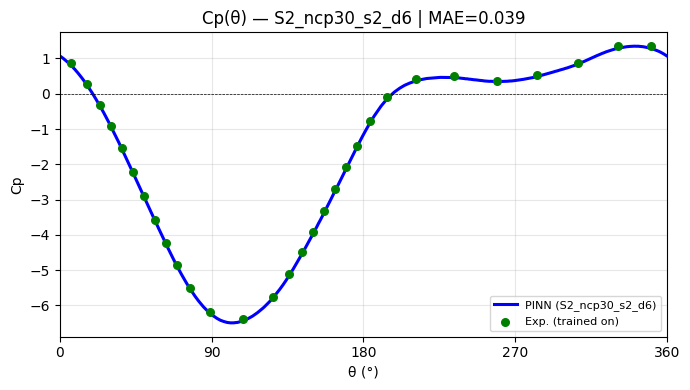

In [ ]:
specific_run_id = 'S2_ncp30_s2_d6'
# Find the configuration for the specific run from df_s2
specific_run_config_row = df_s2[df_s2['run_id'] == specific_run_id].iloc[0]

# Reconstruct the RunConfig object
cfg_specific_run = core.RunConfig(
    run_id=specific_run_config_row['run_id'],
    RE=3.6e5,  # Value used in the loop that generated df_s2
    ALPHA=2.0, # Value used in the loop that generated df_s2
    NCp=int(specific_run_config_row['n_train_points']), # NCp was mapped to n_train_points
    cp_selection="evenly_spaced_index", # Value used in the loop that generated df_s2
    seed=int(specific_run_config_row['run_id'].split('_s')[1].split('_')[0]), # Extract seed from run_id
    **BEST_CFG_FIELDS
)

# Run the evaluation for the specific config (it will load from checkpoint if already completed)
result_specific_run = run_one(cfg_specific_run, data_main)

# Extract the Cp_curve
theta_deg, Cp_values = result_specific_run['eval']['Cp_curve']

# Create a DataFrame for better display
cp_df = pd.DataFrame({'theta_deg': theta_deg, 'Cp_values': Cp_values})
# Save the DataFrame to an Excel file
excel_file_path = f"{OUT_DIR}/{specific_run_id}_cp_data.xlsx"
cp_df.to_excel(excel_file_path, index=False)
print(f"Cp data saved to: {excel_file_path}")

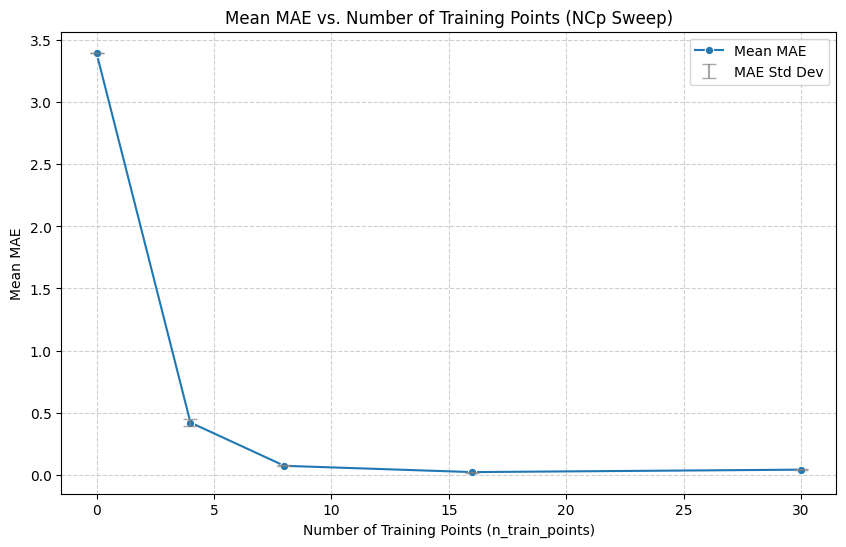

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot MAE_mean vs n_train_points with MAE_std as error bars
plt.figure(figsize=(10, 6))
sns.lineplot(x='n_train_points', y='MAE_mean', data=summary, marker='o', label='Mean MAE')
plt.errorbar(x=summary['n_train_points'], y=summary['MAE_mean'], yerr=summary['MAE_std'],
             fmt='none', capsize=5, color='gray', alpha=0.7, label='MAE Std Dev')

plt.title('Mean MAE vs. Number of Training Points (NCp Sweep)')
plt.xlabel('Number of Training Points (n_train_points)')
plt.ylabel('Mean MAE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

✓ Run 'S2_ncp16_s3_d6' already completed — skipping training.
✓ Run 'S2_ncp16_s4_d6' already completed — skipping training.
✓ Run 'S2_ncp16_s5_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s3_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s4_d6' already completed — skipping training.
✓ Run 'S2_ncp30_s5_d6' already completed — skipping training.


,n_train_points,MAE_mean,MAE_std,MAE_n,CL_err_mean,CL_err_std,CD_err_mean,CD_err_std
0,0,3.395164,0.002110,3,99.954816,0.182110,100.616023,0.295214
1,4,0.420804,0.028107,3,32.464707,2.106830,7.613663,2.232568
2,8,0.072594,0.004585,3,15.968863,0.537067,3.875830,1.701167
3,16,0.099836,0.085242,6,15.494933,2.027825,2.678513,0.702894
4,30,0.088213,0.051502,6,14.678178,1.573421,3.003278,1.125105


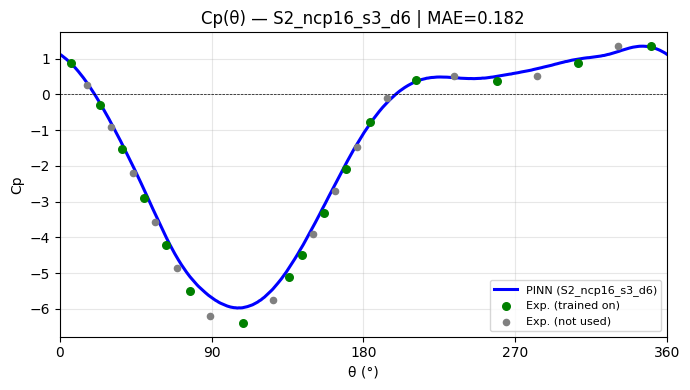

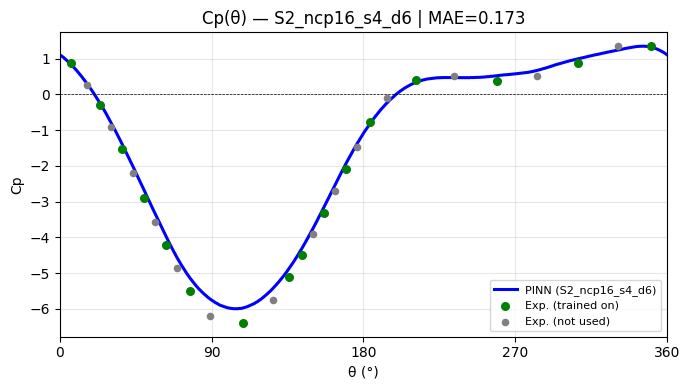

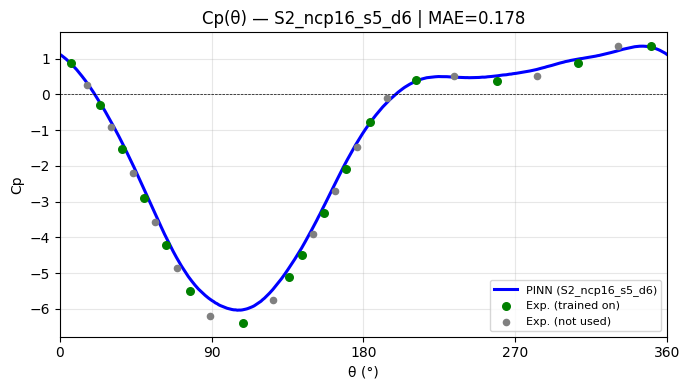

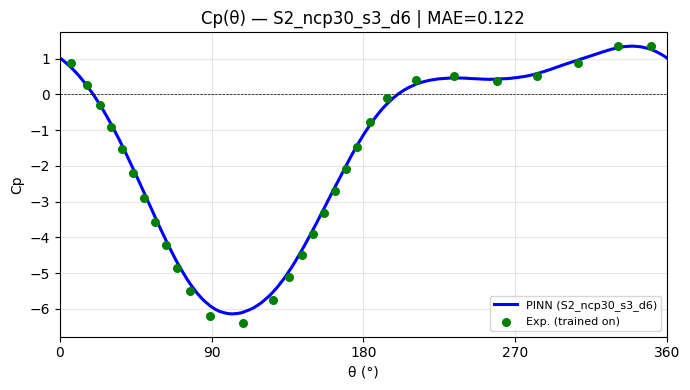

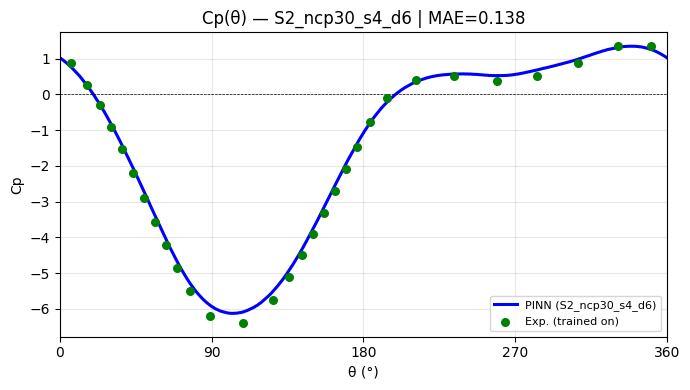

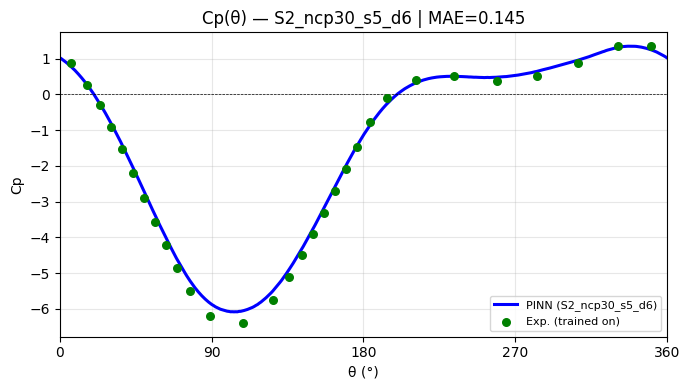

In [ ]:
extra_rows = []
for ncp in [16, 30]:
    for seed in [3, 4, 5]:
        cfg = core.RunConfig(
            run_id=f"S2_ncp{ncp}_s{seed}_d6",
            RE=3.6e5, ALPHA=2.0, NCp=ncp, cp_selection="evenly_spaced_index",
            seed=seed, **BEST_CFG_FIELDS,
            notes="Step 2 extension — more seeds to test robustness of NCp=16 vs 30",
        )
        r = run_one(cfg, data_main)
        extra_rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_s2_extended = pd.concat([df_s2, pd.DataFrame(extra_rows)], ignore_index=True)
df_s2_extended.to_csv(f"{OUT_DIR}/step2_ncp_sweep_results_d6_extended.csv", index=False)

summary_extended = df_s2_extended.groupby("n_train_points").agg(
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"), MAE_n=("MAE", "count"),
    CL_err_mean=("CL_err_pct", "mean"), CL_err_std=("CL_err_pct", "std"),
    CD_err_mean=("CD_err_pct", "mean"), CD_err_std=("CD_err_pct", "std"),
).reset_index()
summary_extended

In [ ]:
from scipy import stats

mae16 = df_s2_extended.loc[df_s2_extended["n_train_points"]==16, "MAE"]
mae30 = df_s2_extended.loc[df_s2_extended["n_train_points"]==30, "MAE"]
t, p = stats.ttest_ind(mae16, mae30, equal_var=False)
print(f"NCp=16 (n={len(mae16)}, mean={mae16.mean():.4f}) vs NCp=30 (n={len(mae30)}, mean={mae30.mean():.4f})")
print(f"Welch's t={t:.2f}, p={p:.4f}")

NCp=16 (n=6, mean=0.0998) vs NCp=30 (n=6, mean=0.0882)
Welch's t=0.29, p=0.7821


### Calculated CL and CD from the `summary` DataFrame

Using the `cl_ref` and `cd_ref` values from `data_main`, and the `CL_err_mean` and `CD_err_mean` from the `summary` DataFrame, we can calculate the mean predicted CL and CD for each number of training points.

In [ ]:
cl_ref = data_main['cl_ref']
cd_ref = data_main['cd_ref']

summary['CL_calculated_mean'] = cl_ref * (1 - summary['CL_err_mean'] / 100)
summary['CD_calculated_mean'] = cd_ref * (1 - summary['CD_err_mean'] / 100)
summary['CL_reference'] = cl_ref
summary['CD_reference'] = cd_ref

display(summary[['n_train_points', 'CL_calculated_mean', 'CL_reference', 'CD_calculated_mean', 'CD_reference']])

,n_train_points,CL_calculated_mean,CL_reference,CD_calculated_mean,CD_reference
0,0,0.002674,5.91713,-0.010748,1.744738
1,4,3.996151,5.91713,1.611899,1.744738
2,8,4.972231,5.91713,1.677115,1.744738
3,16,5.109401,5.91713,1.688890,1.744738
4,30,5.130990,5.91713,1.678584,1.744738


## 8. Step 3 — physics-only (α=0) diagnostics

**3a — isolate the mechanism at α=0.** These are *physics-only* runs (NCp=0), so they don't need real Cp data at all — we pass an empty data dict rather than loading the Bordogna file, which also sidesteps the question of whether α=0 was even one of the tested conditions in that dataset.

In [ ]:
empty_data = dict(theta_exp=np.array([]), cp_exp=np.array([]),
                   cl_ref=0.0, cd_ref=float("nan"))

variants = {
    "S3a_baseline": dict(),
    "S3a_hardbc":   dict(hard_constrain_farfield=True),
    "S3a_compact":  dict(R_OUT=8.0),
}

farfield_results = {}
for name, extra in variants.items():
    cfg = core.RunConfig(run_id=name, RE=3.6e5, ALPHA=0.0, NCp=0,
                          seed=0, notes="Step 3a — alpha=0 control case", **extra)
    result = core.train(cfg, empty_data, OUT_DIR)
    make_input = core.make_input_fn(cfg)
    farfield_results[name] = core.check_farfield_convergence(
        result["model"], make_input, core.get_uvp, cfg.R_IN, cfg.R_OUT)
    print(f"--- {name} ---")
    for r in farfield_results[name]:
        print(f"  r={r['r']:6.2f}  mean|u|={r['mean_speed']:.4f}  (should -> 1.0 at r=R_out if healthy)")

# Healthy = mean|u| approaches 1.0 as r -> R_out. A value stuck near 0
# means that variant is still collapsing to the trivial quiescent solution.

✓ Run 'S3a_baseline' already completed — skipping training.
--- S3a_baseline ---
  r=  0.60  mean|u|=0.0020  (should -> 1.0 at r=R_out if healthy)
  r=  1.00  mean|u|=0.0095  (should -> 1.0 at r=R_out if healthy)
  r=  2.00  mean|u|=0.0635  (should -> 1.0 at r=R_out if healthy)
  r=  4.00  mean|u|=0.2870  (should -> 1.0 at r=R_out if healthy)
  r= 12.50  mean|u|=0.8231  (should -> 1.0 at r=R_out if healthy)
  r= 25.00  mean|u|=0.9979  (should -> 1.0 at r=R_out if healthy)
✓ Run 'S3a_hardbc' already completed — skipping training.
--- S3a_hardbc ---
  r=  0.60  mean|u|=0.0016  (should -> 1.0 at r=R_out if healthy)
  r=  1.00  mean|u|=0.0067  (should -> 1.0 at r=R_out if healthy)
  r=  2.00  mean|u|=0.0456  (should -> 1.0 at r=R_out if healthy)
  r=  4.00  mean|u|=0.2527  (should -> 1.0 at r=R_out if healthy)
  r= 12.50  mean|u|=0.8145  (should -> 1.0 at r=R_out if healthy)
  r= 25.00  mean|u|=1.0000  (should -> 1.0 at r=R_out if healthy)
✓ Run 'S3a_compact' already completed — skipping t

In [ ]:
import inspect
print(inspect.signature(core.flow_field_diagnostics))
print(inspect.getsource(core.flow_field_diagnostics))

(cfg: flettner_pinn_core.RunConfig, model, eval_result, extent=None)
def flow_field_diagnostics(cfg: RunConfig, model, eval_result, extent=None):
    make_input = make_input_fn(cfg)
    ff_diag = check_farfield_convergence(model, make_input, get_uvp, cfg.R_IN, cfg.R_OUT)
    th_deg, Cp = eval_result["Cp_curve"]
    field = plot_flow_field(model, make_input, get_uvp, cfg.R_IN, alpha_label=cfg.ALPHA,
                             extent=extent or min(6.0, cfg.R_OUT))
    return dict(farfield=ff_diag, field=field)



✓ Run 'S3a_compact' already completed — skipping training.
S3a_compact: Cp swing = 0.0121 (stagnation≈θ=180°: -0.1399, shoulder≈θ=90°: -0.1423)


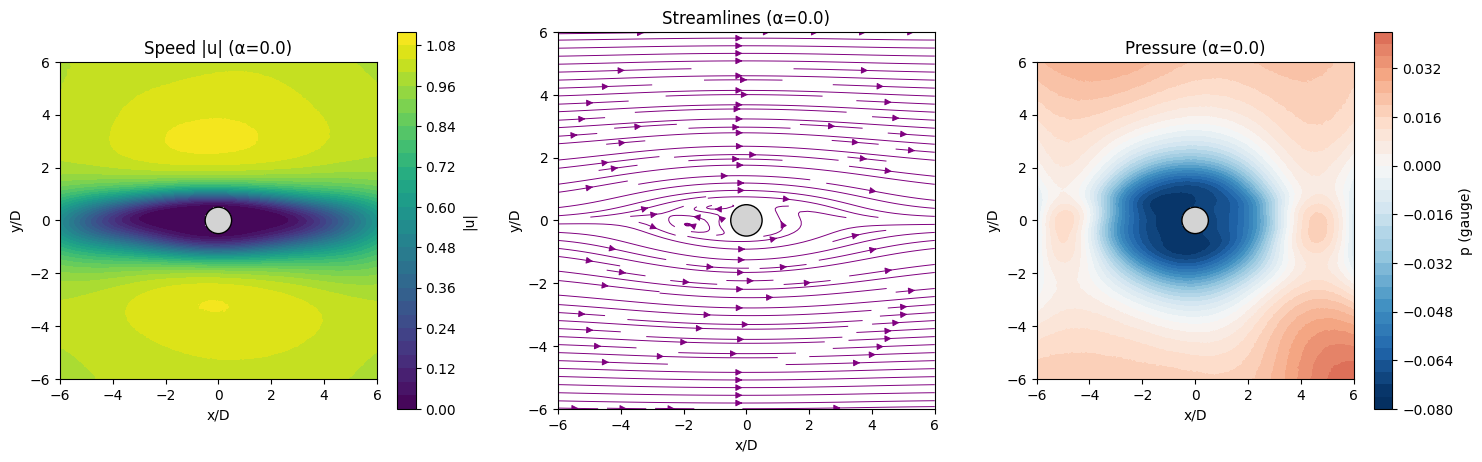

In [ ]:
# Reload a finished Step 3a checkpoint (no retraining — weights already on Drive)
run_id = "S3a_compact" # then rerun with "S3a_hardbc"
extra = variants[run_id] # picks up the right hard_constrain_farfield/R_OUT automatically
cfg_s3a = core.RunConfig(run_id=run_id, RE=3.6e5, ALPHA=0.0, NCp=0, seed=0,
notes="Step 3a reload", **extra)
result_s3a = core.train(cfg_s3a, empty_data, OUT_DIR) # should print "already completed — skipping"
model_s3a = result_s3a["model"]

# 1) Flow field: streamlines + |u| + pressure contours — the actual v1-failure check
dummy_eval = {"Cp_curve": (np.array([0.]), np.array([0.]))}
diag = core.flow_field_diagnostics(cfg_s3a, model_s3a, dummy_eval, extent=6.0)
diag["field"]["fig"].savefig(f"{OUT_DIR}/fig_flowfield_{run_id}.png", dpi=200, bbox_inches="tight")

# 2) Wall Cp(theta) swing — same Cp_raw formula evaluate() uses internally,
# just skipping the exp-data alignment shift (no cp_exp to align to here)
make_input = core.make_input_fn(cfg_s3a)
th_deg = np.linspace(0, 360, 360, dtype=np.float32)
th_rad = np.radians(th_deg)
xw = (-cfg_s3a.R_IN*np.cos(th_rad)).reshape(-1,1); yw = (cfg_s3a.R_IN*np.sin(th_rad)).reshape(-1,1)
uvp_wall = core.get_uvp(model_s3a(make_input(xw, yw), training=False)).numpy()
th_ff = np.linspace(0, 2*np.pi, 256, dtype=np.float32)
xff = (cfg_s3a.R_OUT*np.cos(th_ff)).reshape(-1,1); yff = (cfg_s3a.R_OUT*np.sin(th_ff)).reshape(-1,1)
pr = core.get_uvp(model_s3a(make_input(xff, yff), training=False)).numpy()[:,2].mean()
Cp_wall = 2.*(uvp_wall[:,2] - pr)
print(f"{run_id}: Cp swing = {Cp_wall.max() - Cp_wall.min():.4f} "
f"(stagnation≈θ=180°: {np.interp(180, th_deg, Cp_wall):.4f}, "
f"shoulder≈θ=90°: {np.interp(90, th_deg, Cp_wall):.4f})")

## 9. Step 4 — sector masking, five scenarios × seeds

Correct the angle ranges below if your θ=0 convention or your original M1–M4 definitions differ from the defaults proposed in the strategy doc.

✓ Run 'S4_M1_windward_s0' already completed — skipping training.
✓ Run 'S4_M1_windward_s1' already completed — skipping training.
✓ Run 'S4_M1_windward_s2' already completed — skipping training.
✓ Run 'S4_M2_suction_s0' already completed — skipping training.
✓ Run 'S4_M2_suction_s1' already completed — skipping training.
✓ Run 'S4_M2_suction_s2' already completed — skipping training.
✓ Run 'S4_M3_leeward_s0' already completed — skipping training.
✓ Run 'S4_M3_leeward_s1' already completed — skipping training.
✓ Run 'S4_M3_leeward_s2' already completed — skipping training.
✓ Run 'S4_M4_half_s0' already completed — skipping training.
✓ Run 'S4_M4_half_s1' already completed — skipping training.
✓ Run 'S4_M4_half_s2' already completed — skipping training.
✓ Run 'S4_M5_two_gaps_s0' already completed — skipping training.
✓ Run 'S4_M5_two_gaps_s1' already completed — skipping training.
✓ Run 'S4_M5_two_gaps_s2' already completed — skipping training.


,scenario,MAE_trained_mean,MAE_masked_mean,CL_err_mean,CD_err_mean
0,S4_M1_windward,0.443172,0.208844,13.291775,12.549624
1,S4_M2_suction,0.089670,0.193687,17.807814,2.014088
2,S4_M3_leeward,0.474423,1.030652,33.059222,50.775111
3,S4_M4_half,0.657179,1.280090,40.571472,42.415682
4,S4_M5_two_gaps,0.210266,0.264223,22.545015,8.005610


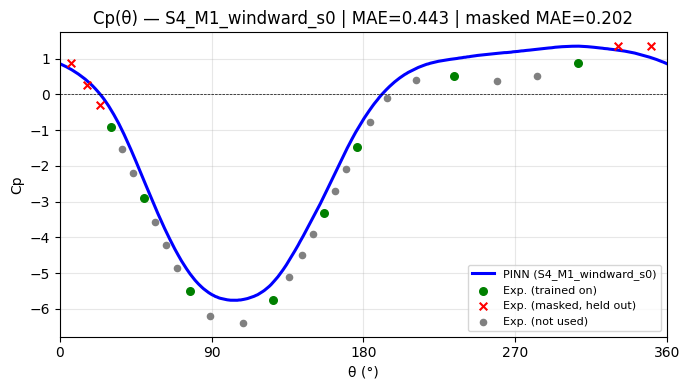

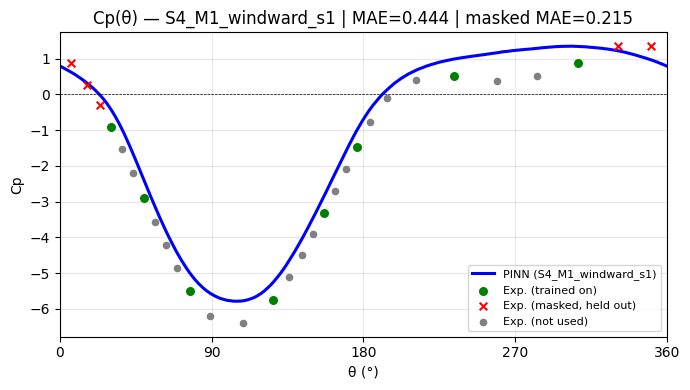

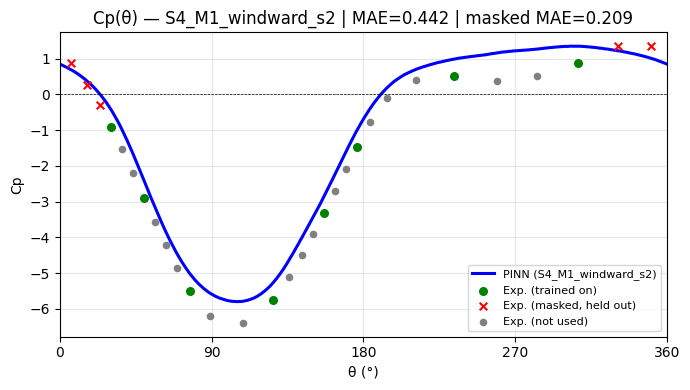

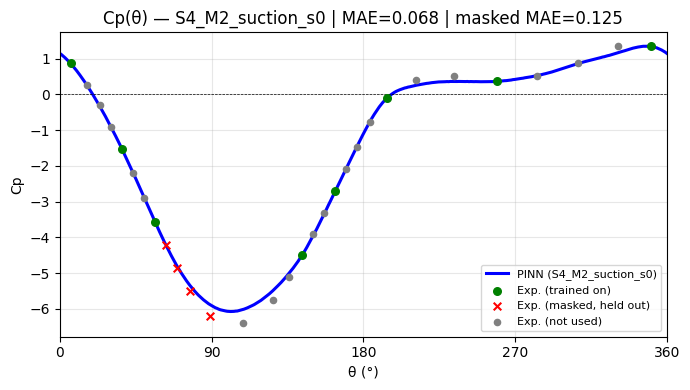

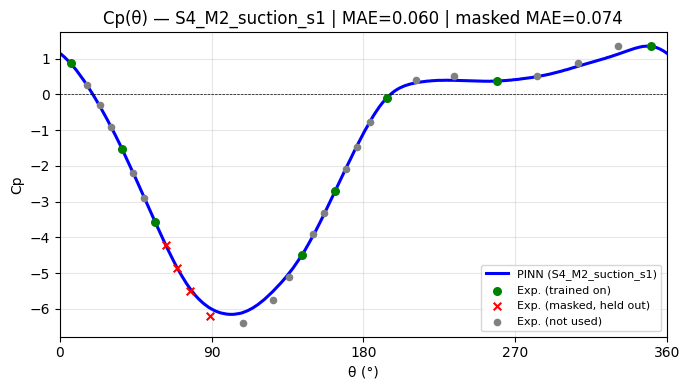

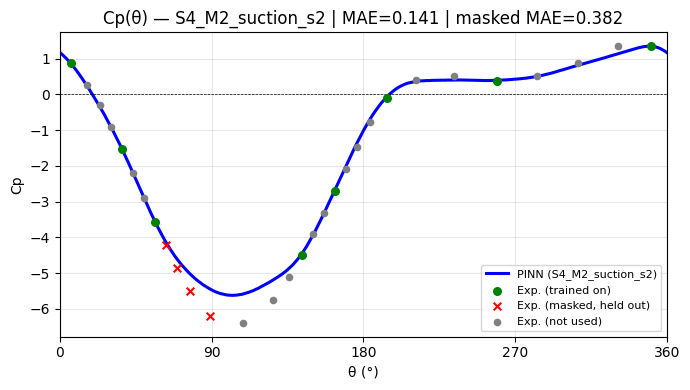

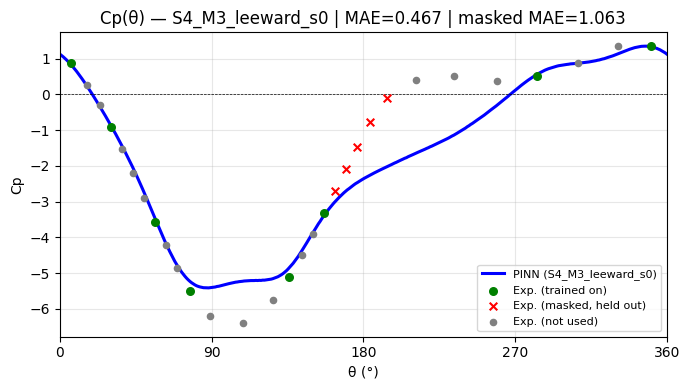

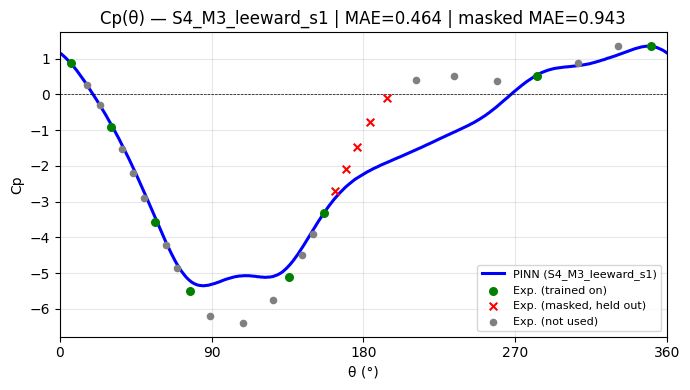

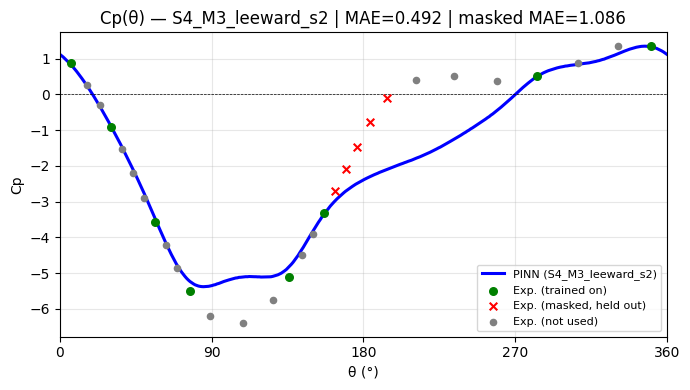

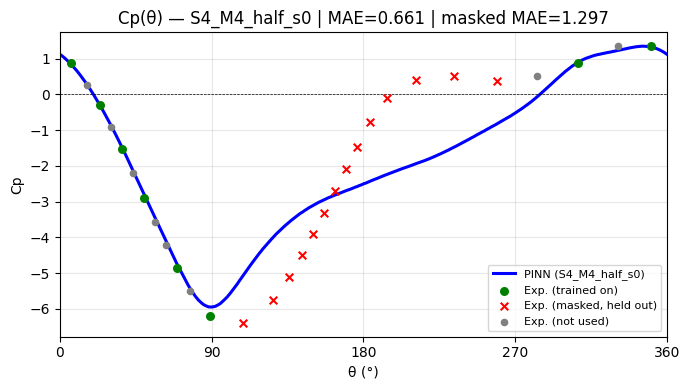

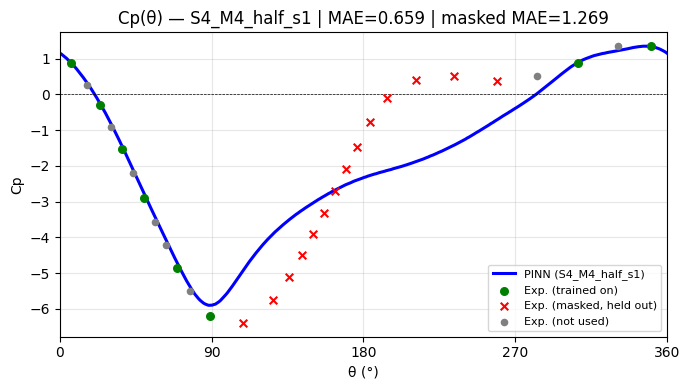

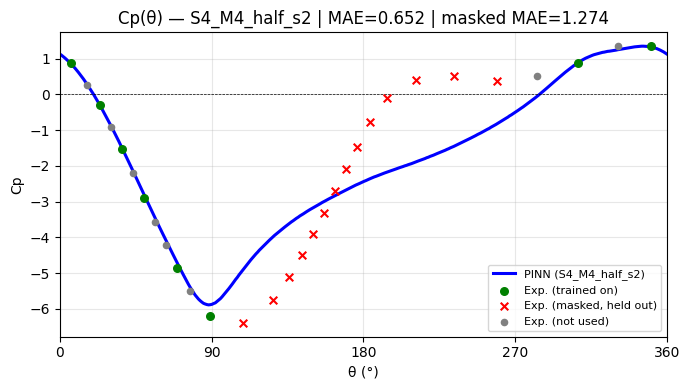

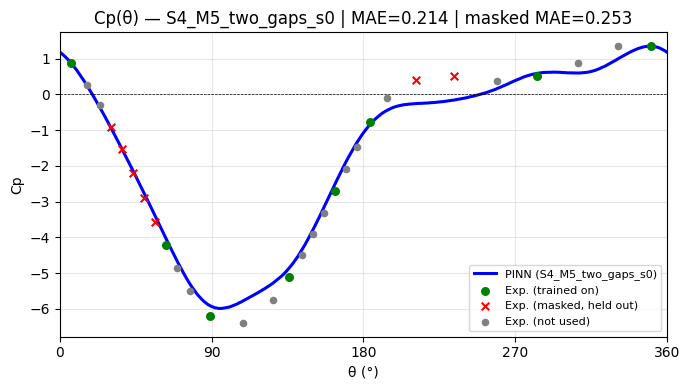

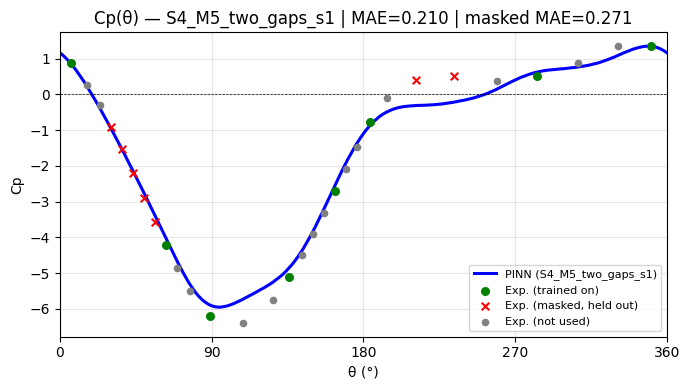

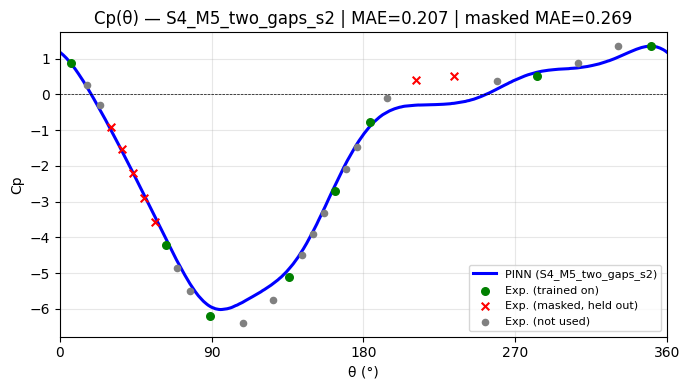

In [ ]:
# Ncp=8 --> Ncp=30 below
SCENARIOS = {
    "S4_M1_windward": [(330, 30)],
    "S4_M2_suction":  [(60, 100)],
    "S4_M3_leeward":  [(160, 200)],
    "S4_M4_half":     [(90, 270)],
    "S4_M5_two_gaps": [(30, 60), (210, 240)],
}

rows = []
for name, sectors in SCENARIOS.items():
    for seed in [0, 1, 2]:
        cfg = core.RunConfig(
            run_id=f"{name}_s{seed}", RE=3.6e5, ALPHA=2.0,
            mask_sectors=sectors, seed=seed, **BEST_CFG_FIELDS,
            notes=f"Step 4 — sector masking scenario {name}",
        )
        r = run_one(cfg, data_main)
        r = {k: v for k, v in r.items() if k not in ("model", "eval", "history")}
        rows.append({"scenario": name, **r})

df_s4 = pd.DataFrame(rows)
df_s4.to_csv(f"{OUT_DIR}/step4_sector_masking_results.csv", index=False)

summary4 = df_s4.groupby("scenario").agg(
    MAE_trained_mean=("MAE", "mean"),
    MAE_masked_mean=("MAE_masked", "mean"),
    CL_err_mean=("CL_err_pct", "mean"),
    CD_err_mean=("CD_err_pct", "mean"),
).reset_index()
summary4

✓ Run 'S4_M1_windward_ncp30_s0' already completed — skipping training.
✓ Run 'S4_M2_suction_ncp30_s0' already completed — skipping training.
✓ Run 'S4_M3_leeward_ncp30_s0' already completed — skipping training.
✓ Run 'S4_M4_half_ncp30_s0' already completed — skipping training.
✓ Run 'S4_M5_two_gaps_ncp30_s0' already completed — skipping training.
✓ Run 'S4_M1_windward_ncp30_s0' already completed — skipping training.
S4_M1_windward {'PINN': 360, 'trained': 25, 'masked': 5} | reported masked: 5
✓ Run 'S4_M2_suction_ncp30_s0' already completed — skipping training.
S4_M2_suction {'PINN': 360, 'trained': 26, 'masked': 4} | reported masked: 4
✓ Run 'S4_M3_leeward_ncp30_s0' already completed — skipping training.
S4_M3_leeward {'PINN': 360, 'trained': 25, 'masked': 5} | reported masked: 5
✓ Run 'S4_M4_half_ncp30_s0' already completed — skipping training.
S4_M4_half {'PINN': 360, 'trained': 16, 'masked': 14} | reported masked: 14
✓ Run 'S4_M5_two_gaps_ncp30_s0' already completed — skipping trai

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

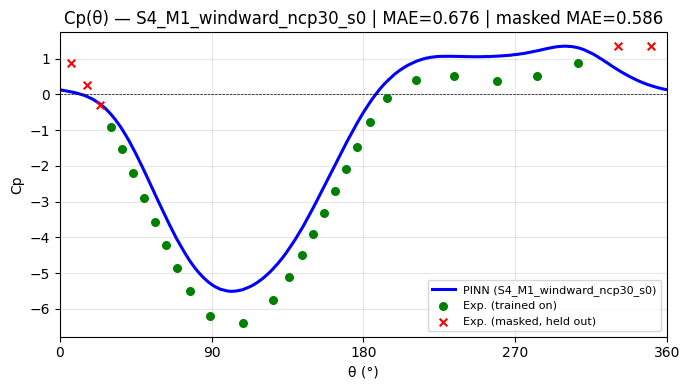

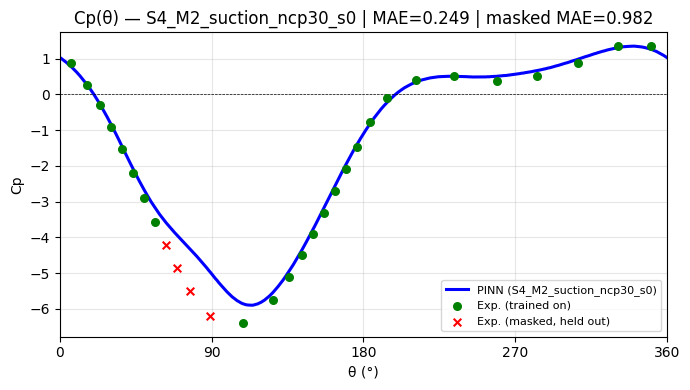

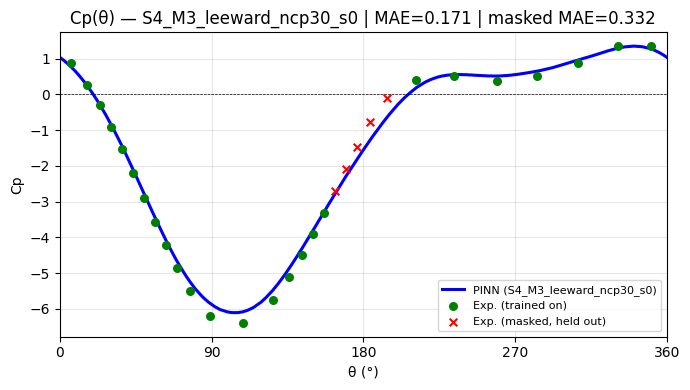

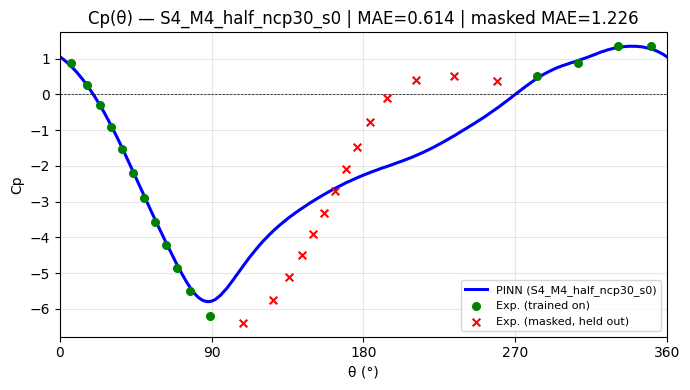

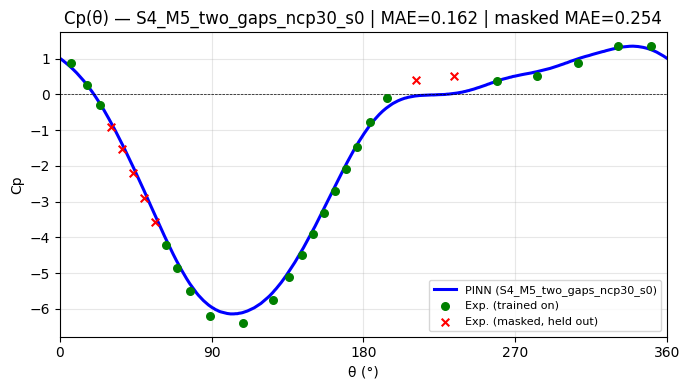

In [ ]:
rows_ncp30 = []
for name, sectors in SCENARIOS.items():
    cfg = core.RunConfig(
        run_id=f"{name}_ncp30_s0", RE=3.6e5, ALPHA=2.0,
        mask_sectors=sectors, NCp=30, cp_selection="evenly_spaced_index",
        seed=0, **BEST_CFG_FIELDS,
        notes=f"Step 4 (dense variant, NCp=30, single seed) — {name}",
    )
    r = run_one(cfg, data_main)
    r = {k: v for k, v in r.items() if k not in ("model", "eval", "history")}
    rows_ncp30.append({"scenario": name, **r})

df_s4_ncp30 = pd.DataFrame(rows_ncp30)
df_s4_ncp30.to_csv(f"{OUT_DIR}/step4_sector_masking_results_ncp30.csv", index=False)

summary4_ncp30 = df_s4_ncp30[["scenario", "MAE", "MAE_masked", "CL_err_pct", "CD_err_pct"]].rename(
    columns={"MAE": "MAE_trained", "CL_err_pct": "CL_err", "CD_err_pct": "CD_err"}
)
summary4_ncp30
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt

def xy_of(art):
    if hasattr(art, "get_offsets"):
        a = np.asarray(art.get_offsets()); return a[:, 0], a[:, 1]
    return art.get_data()

sheets = {}
for name, sectors in SCENARIOS.items():
    cfg = core.RunConfig(
        run_id=f"{name}_ncp30_s0", RE=3.6e5, ALPHA=2.0,
        mask_sectors=sectors, NCp=30, cp_selection="evenly_spaced_index",
        seed=0, **BEST_CFG_FIELDS, notes="Step 4 (dense variant, NCp=30, single seed)")
    r = run_one(cfg, data_main)
    ax = r["eval"]["fig"].axes[0]

    series = {}
    for art in list(ax.lines) + list(ax.collections):
        lab = art.get_label()
        if lab.startswith("_"):
            continue
        key = "PINN" if "PINN" in lab else "trained" if "trained" in lab else "masked" if "masked" in lab else None
        if key:
            x, y = xy_of(art)
            series[key] = (np.asarray(x, float), np.asarray(y, float))
    print(name, {k: len(v[0]) for k, v in series.items()}, "| reported masked:", r["n_masked_points"])
    sheets[name] = (series, ax.get_title())
    plt.close(r["eval"]["fig"])

path = os.path.join(OUT_DIR, "step4_ncp30_cp_vs_theta.xlsx")
with pd.ExcelWriter(path, engine="openpyxl") as xw:
    for name, (series, title) in sheets.items():
        blocks = [("PINN", "Cp_PINN"), ("trained", "Cp_Exp_trained"), ("masked", "Cp_Exp_masked")]
        for i, (key, col) in enumerate(blocks):
            if key in series:
                pd.DataFrame({"theta_deg": series[key][0], col: series[key][1]}).to_excel(
                    xw, sheet_name=name[:31], startcol=3 * i, index=False)
        pd.DataFrame({"plot_title": [title]}).to_excel(xw, sheet_name=name[:31], startcol=10, index=False)
print("saved", path)

try:
    from google.colab import files
    files.download(path)
except Exception as e:
    print("download from Drive instead:", e)

In [ ]:
import pandas as pd

a8  = pd.read_csv(f"{OUT_DIR}/step4_sector_masking_results.csv")        # NCp=8, 3 seeds
a30 = pd.read_csv(f"{OUT_DIR}/step4_sector_masking_results_ncp30.csv")  # NCp=30, 1 seed
cols = ["MAE", "MAE_masked", "CL_err_pct", "CD_err_pct", "n_train_points", "n_masked_points"]
t8  = a8.groupby("scenario")[cols].mean().add_suffix("_ncp8")
t30 = a30.set_index("scenario")[cols].add_suffix("_ncp30")
print(t8.join(t30).round(3).T.to_string())

led = pd.read_csv(f"{OUT_DIR}/ledger.csv")
print(list(led.columns))
want = ["S2_ncp8_s0_d6", "S2_ncp8_s1_d6", "S2_ncp8_s2_d6", "S2_ncp30_s0_d6"]
show = [c for c in ["run_id", "MAE", "RMSE", "CL_err_pct", "CD_err_pct"] if c in led.columns]
print(led[led.run_id.isin(want)][show].round(3).to_string(index=False))

scenario               S4_M1_windward  S4_M2_suction  S4_M3_leeward  S4_M4_half  S4_M5_two_gaps
MAE_ncp8                        0.443          0.090          0.474       0.657           0.210
MAE_masked_ncp8                 0.209          0.194          1.031       1.280           0.264
CL_err_pct_ncp8                13.292         17.808         33.059      40.571          22.545
CD_err_pct_ncp8                12.550          2.014         50.775      42.416           8.006
n_train_points_ncp8             8.000          8.000          8.000       8.000           8.000
n_masked_points_ncp8            5.000          4.000          5.000      14.000           7.000
MAE_ncp30                       0.676          0.249          0.171       0.614           0.162
MAE_masked_ncp30                0.586          0.982          0.332       1.226           0.254
CL_err_pct_ncp30               18.646         21.034         16.134      37.072          18.257
CD_err_pct_ncp30               40.799   

In [ ]:
compare = summary4[["scenario", "MAE_masked_mean"]].merge(
    summary4_ncp30[["scenario", "MAE_masked"]].rename(columns={"MAE_masked": "MAE_masked_ncp30"}),
    on="scenario"
)
compare["ratio"] = compare["MAE_masked_ncp30"] / compare["MAE_masked_mean"]
compare

,scenario,MAE_masked_mean,MAE_masked_ncp30,ratio
0,S4_M1_windward,0.208844,0.586086,2.806329
1,S4_M2_suction,0.193687,0.981749,5.068744
2,S4_M3_leeward,1.030652,0.332021,0.322147
3,S4_M4_half,1.280090,1.226364,0.958029
4,S4_M5_two_gaps,0.264223,0.253609,0.959832


## 11. Manuscript figures

Three figure types, all saved to `OUT_DIR` on Drive (so they survive a disconnect like everything else here) and all built from the actual trained model, not a mockup:

- **Collocation points** — shows the interior/wall/far-field sampling used in training. Doesn't need a trained model — you can run this cell any time, even before Step 0.
- **Flow field** (|u|, streamlines, pressure) + the Cp(θ) comparison curve — needs a completed run.
- **Training convergence** (loss components vs. epoch, log scale) — needs a completed run.

First, pick which completed run you want figures for and reload it:

✓ Run 'S4_M1_windward_s2' already completed — skipping training.
Exported Cp data for scenario 'S4_M1_windward' (run_id: S4_M1_windward_s2) to: /content/drive/MyDrive/PINN_Flettner2/runs/S4_M1_windward_S4_M1_windward_s2_cp_data_full.xlsx
✓ Run 'S4_M2_suction_s1' already completed — skipping training.
Exported Cp data for scenario 'S4_M2_suction' (run_id: S4_M2_suction_s1) to: /content/drive/MyDrive/PINN_Flettner2/runs/S4_M2_suction_S4_M2_suction_s1_cp_data_full.xlsx
✓ Run 'S4_M3_leeward_s1' already completed — skipping training.
Exported Cp data for scenario 'S4_M3_leeward' (run_id: S4_M3_leeward_s1) to: /content/drive/MyDrive/PINN_Flettner2/runs/S4_M3_leeward_S4_M3_leeward_s1_cp_data_full.xlsx
✓ Run 'S4_M4_half_s2' already completed — skipping training.
Exported Cp data for scenario 'S4_M4_half' (run_id: S4_M4_half_s2) to: /content/drive/MyDrive/PINN_Flettner2/runs/S4_M4_half_S4_M4_half_s2_cp_data_full.xlsx
✓ Run 'S4_M5_two_gaps_s2' already completed — skipping training.
Exported Cp d

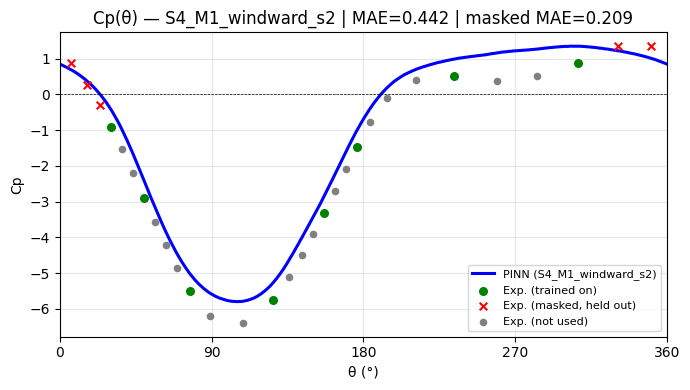

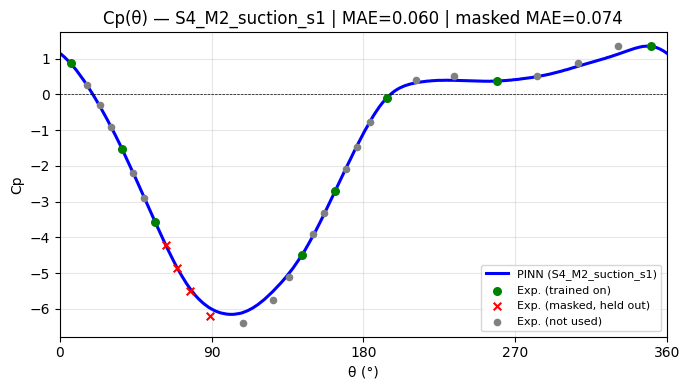

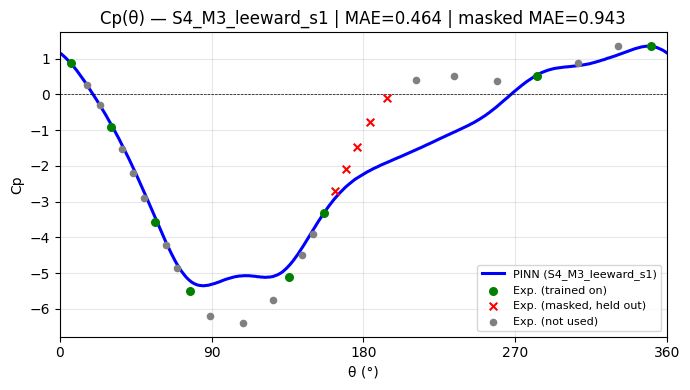

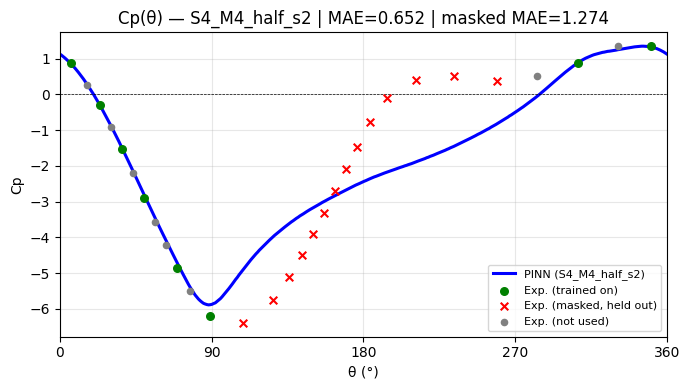

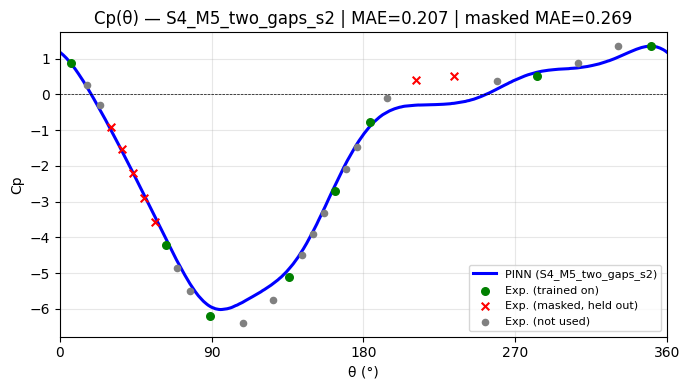

In [ ]:
import pandas as pd
import numpy as np

# Group df_s4 by scenario and find the run_id with the minimum MAE for each
best_runs_per_scenario = df_s4.loc[df_s4.groupby('scenario')['MAE'].idxmin()]

for _, row in best_runs_per_scenario.iterrows():
    scenario_name = row['scenario']
    best_run_id = row['run_id']
    # Fix: Use rsplit to get the last part after '_s' to correctly extract the seed
    best_seed = int(best_run_id.rsplit('_s', 1)[-1])

    # Reconstruct the RunConfig for this best-performing scenario
    # Need to get mask_sectors from the SCENARIOS dictionary
    mask_sectors_for_cfg = SCENARIOS[scenario_name]

    cfg_scenario = core.RunConfig(
        run_id=best_run_id,
        RE=3.6e5,
        ALPHA=2.0,
        cp_selection="evenly_spaced_index",
        mask_sectors=mask_sectors_for_cfg,
        seed=best_seed,
        **BEST_CFG_FIELDS,
        notes=f"Export for best performing seed of {scenario_name}"
    )

    # Run the model (it should load from checkpoint if already completed)
    # This also performs evaluation and populates cp_selection
    result_scenario = run_one(cfg_scenario, data_main)

    # Extract PINN prediction data
    theta_pinn, cp_pinn = result_scenario['eval']['Cp_curve']
    df_pinn = pd.DataFrame({'theta_deg': theta_pinn, 'Cp_PINN': cp_pinn})

    # Extract experimental data and categorize
    theta_exp = data_main['theta_exp']
    cp_exp = data_main['cp_exp']
    cp_selection = result_scenario['cp_selection']

    train_idx = cp_selection['train_idx']
    masked_idx = cp_selection['masked_idx']
    # eval_idx contains all experimental points, so retained = eval_idx - (train_idx + masked_idx)
    all_exp_indices = np.arange(len(theta_exp))
    retained_idx = np.array(list(set(all_exp_indices) - set(train_idx) - set(masked_idx)))

    df_exp_trained = pd.DataFrame({
        'theta_deg': theta_exp[train_idx],
        'Cp_Exp_Trained_On': cp_exp[train_idx]
    })
    df_exp_masked = pd.DataFrame({
        'theta_deg': theta_exp[masked_idx],
        'Cp_Exp_Masked_Held_Out': cp_exp[masked_idx]
    })
    df_exp_not_used = pd.DataFrame({
        'theta_deg': theta_exp[retained_idx],
        'Cp_Exp_Not_Used': cp_exp[retained_idx]
    })

    # Define output Excel file path
    excel_output_path = f"{OUT_DIR}/{scenario_name}_{best_run_id}_cp_data_full.xlsx"

    # Write to Excel with multiple sheets
    with pd.ExcelWriter(excel_output_path) as writer:
        df_pinn.to_excel(writer, sheet_name='PINN_Prediction', index=False)
        df_exp_trained.to_excel(writer, sheet_name='Exp_Trained_On', index=False)
        df_exp_masked.to_excel(writer, sheet_name='Exp_Masked_Held_Out', index=False)
        df_exp_not_used.to_excel(writer, sheet_name='Exp_Not_Used', index=False)

    print(f"Exported Cp data for scenario '{scenario_name}' (run_id: {best_run_id}) to: {excel_output_path}")

In [ ]:
# ---- Pick the run you want manuscript figures for ----
# Paste the same RunConfig fields you used when this run was trained —
# reusing the exact config is the simplest, least error-prone way to
# reload a specific run's weights (rather than guessing them back from
# the ledger CSV).
cfg_fig = core.RunConfig(
    run_id="S2_ncp8_s0_d6",   # <-- must match an already-completed run_id
    RE=3.6e5, ALPHA=2.0, NCp=8, seed=0, **BEST_CFG_FIELDS,
)

result_fig = core.train(cfg_fig, data_main, OUT_DIR)  # already completed -> just reloads, no retraining
model_fig, history_fig = result_fig["model"], result_fig["history"]

✓ Run 'S2_ncp8_s0_d6' already completed — skipping training.


  💾 figure verified: fig_collocation_points.png ✓

Inlet Velocity (U_infinity): 1.0
Rotor Angular Velocity (Omega): 4.0 rad/s (calculated from ALPHA=2.0 and R_IN=0.5)


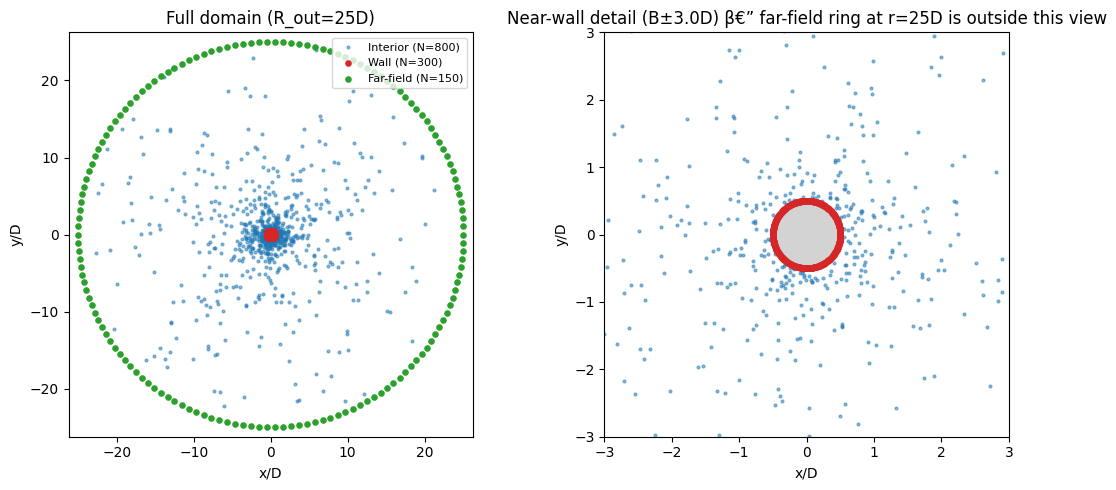

In [ ]:
# ---- Collocation-point figure (works for any cfg, trained or not) ----
core.plot_collocation_points(cfg_fig, save_path=f"{OUT_DIR}/fig_collocation_points.png",
                              ensure_drive_fn=core.ensure_drive)

# Adding information about inlet and rotor velocity
inlet_velocity = 1.0  # From the far-field boundary condition in the train function (mse(uff[:, 0:1], 1.))
rotor_angular_velocity_omega = cfg_fig.ALPHA / cfg_fig.R_IN # Omega = ALPHA / R_IN, from the train function
print(f"\nInlet Velocity (U_infinity): {inlet_velocity}")
print(f"Rotor Angular Velocity (Omega): {rotor_angular_velocity_omega} rad/s (calculated from ALPHA={cfg_fig.ALPHA} and R_IN={cfg_fig.R_IN})")

  💾 verified: fig_cp_curve_S2_ncp8_s0_d6.png
  💾 verified: fig_flowfield_S2_ncp8_s0_d6.png

Far-field convergence check (healthy = mean|u| -> ~1.0 near r=R_out):
  r=  0.60  mean|u|=1.5286
  r=  1.00  mean|u|=0.8132
  r=  2.00  mean|u|=0.8060
  r=  4.00  mean|u|=0.8169
  r= 12.50  mean|u|=0.9298
  r= 25.00  mean|u|=0.9993


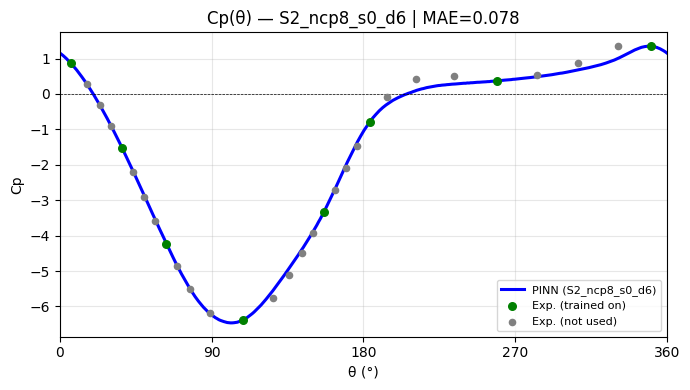

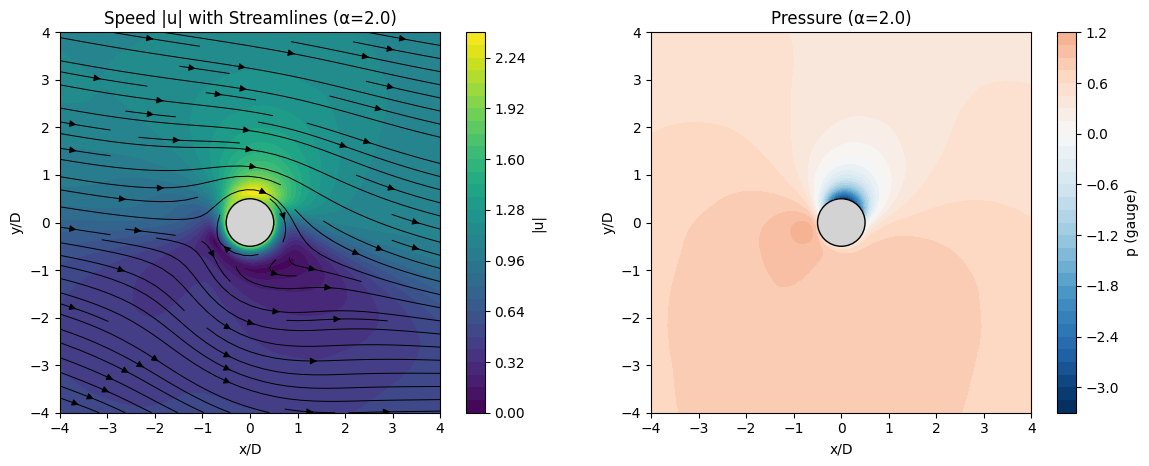

In [ ]:
# ---- Flow field (|u|, streamlines, pressure) + Cp(theta) curve ----

# User-configurable plot parameters
# Adjust these values to customize your flow field plots
PLOT_EXTENT_X = 4.0 # Extent of the x-axis (e.g., 6.0 means from -6.0*R_IN to +6.0*R_IN). Set to cfg.R_OUT for full domain.
PLOT_EXTENT_Y = 4.0 # Extent of the y-axis (e.g., 6.0 means from -6.0*R_IN to +6.0*R_IN). Set to cfg.R_OUT for full domain.
PLOT_N_GRID = 300 # Resolution of the plot grid (e.g., 300 means 300x300 points)
STREAMLINE_DENSITY = 1.0 # Density of streamlines (higher number means more streamlines)
FLOW_PLOT_MODE = "overlay_streamlines_speed" # Options: "separate" (3 subplots), "overlay_streamlines_speed" (speed with streamlines + pressure)


# Redefine plot_flow_field in core module for custom plotting
def _plot_flow_field_custom(model, make_input_fn_, get_uvp_fn, R_in, alpha_label,
                            extent_x, extent_y, n_grid=200, cmap_speed="viridis",
                            cmap_p="RdBu_r", p_shift=0.0, p_ref=0.0, streamline_density=1.6,
                            plot_mode="separate"):
    xg = np.linspace(-extent_x, extent_x, n_grid, dtype=np.float64)
    yg = np.linspace(-extent_y, extent_y, n_grid, dtype=np.float64)
    XG, YG = np.meshgrid(xg, yg)
    Rg = np.sqrt(XG ** 2 + YG ** 2)
    inside = Rg < R_in

    Xf = XG.reshape(-1, 1).astype(np.float32); Yf = YG.reshape(-1, 1).astype(np.float32)
    uvp_g = get_uvp_fn(model(make_input_fn_(Xf, Yf), training=False)).numpy()
    U = uvp_g[:, 0].reshape(XG.shape); V = uvp_g[:, 1].reshape(XG.shape)
    P = uvp_g[:, 2].reshape(XG.shape) - p_ref - p_shift
    speed = np.sqrt(U ** 2 + V ** 2)

    U_stream = np.where(inside, 0.0, U); V_stream = np.where(inside, 0.0, V)
    speed_m = np.ma.array(speed, mask=inside); P_m = np.ma.array(P, mask=inside)

    if plot_mode == "separate":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
        c0 = axes[0].contourf(XG, YG, speed_m, levels=30, cmap=cmap_speed)
        fig.colorbar(c0, ax=axes[0], label="|u|"); axes[0].set_title(f"Speed |u| (α={alpha_label})")
        axes[1].streamplot(XG, YG, U_stream, V_stream, color="purple",
                            density=streamline_density, linewidth=0.7, arrowsize=1.0)
        axes[1].set_title(f"Streamlines (α={alpha_label})")
        vmax = float(np.nanmax(np.abs(P_m))) if np.any(~inside) else 1.0
        c2 = axes[2].contourf(XG, YG, P_m, levels=30, cmap=cmap_p, vmin=-vmax, vmax=vmax)
        fig.colorbar(c2, ax=axes[2], label="p (gauge)"); axes[2].set_title(f"Pressure (α={alpha_label})")
        for ax in axes:
            ax.add_patch(plt.Circle((0, 0), R_in, facecolor="lightgray", edgecolor="k", zorder=5))
            ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
            ax.set_xlim([-extent_x, extent_x]); ax.set_ylim([-extent_y, extent_y]); ax.set_aspect("equal")
    elif plot_mode == "overlay_streamlines_speed":
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6)) # Two subplots for overlay + pressure
        ax_overlay = axes[0]
        c0 = ax_overlay.contourf(XG, YG, speed_m, levels=30, cmap=cmap_speed)
        fig.colorbar(c0, ax=ax_overlay, label="|u|");
        ax_overlay.streamplot(XG, YG, U_stream, V_stream, color="black",
                            density=streamline_density, linewidth=0.7, arrowsize=1.0)
        ax_overlay.set_title(f"Speed |u| with Streamlines (α={alpha_label})")

        vmax = float(np.nanmax(np.abs(P_m))) if np.any(~inside) else 1.0
        c2 = axes[1].contourf(XG, YG, P_m, levels=30, cmap=cmap_p, vmin=-vmax, vmax=vmax)
        fig.colorbar(c2, ax=axes[1], label="p (gauge)"); axes[1].set_title(f"Pressure (α={alpha_label})")

        for ax in axes:
            ax.add_patch(plt.Circle((0, 0), R_in, facecolor="lightgray", edgecolor="k", zorder=5))
            ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
            ax.set_xlim([-extent_x, extent_x]); ax.set_ylim([-extent_y, extent_y]); ax.set_aspect("equal")
    else:
        raise ValueError(f"Unknown plot_mode: {plot_mode}. Choose 'separate' or 'overlay_streamlines_speed'.")

    plt.tight_layout()
    return dict(fig=fig, X=XG, Y=YG, U=U, V=V, P=P, speed=speed)

# Redefine flow_field_diagnostics to pass new parameters
def _flow_field_diagnostics_custom(cfg: core.RunConfig, model, eval_result,
                                   extent_x, extent_y, n_grid, streamline_density, plot_mode):
    make_input = core.make_input_fn(cfg)
    ff_diag = core.check_farfield_convergence(model, make_input, core.get_uvp, cfg.R_IN, cfg.R_OUT)
    # The Cp_curve from eval_result is not directly used in flow_field_diagnostics,
    # but rather in plot_flow_field, which is now overridden.

    field = _plot_flow_field_custom(model, make_input, core.get_uvp, cfg.R_IN, cfg.ALPHA,
                                    extent_x=extent_x, extent_y=extent_y, n_grid=n_grid,
                                    streamline_density=streamline_density, plot_mode=plot_mode)
    return dict(farfield=ff_diag, field=field)

# Overwrite the functions in the core module for the current session
# This ensures the custom functions are used for the subsequent calls.
core.plot_flow_field = _plot_flow_field_custom
core.flow_field_diagnostics = _flow_field_diagnostics_custom

sel = core.select_cp_points(data_main["theta_exp"], data_main["cp_exp"], cfg_fig)
eval_fig = core.evaluate(cfg_fig, model_fig, data_main, sel, OUT_DIR)
eval_fig["fig"].savefig(f"{OUT_DIR}/fig_cp_curve_{cfg_fig.run_id}.png", dpi=900, bbox_inches="tight")

diag = core.flow_field_diagnostics(cfg_fig, model_fig, eval_fig,
                                    extent_x=PLOT_EXTENT_X,
                                    extent_y=PLOT_EXTENT_Y,
                                    n_grid=PLOT_N_GRID,
                                    streamline_density=STREAMLINE_DENSITY,
                                    plot_mode=FLOW_PLOT_MODE)
diag["field"]["fig"].savefig(f"{OUT_DIR}/fig_flowfield_{cfg_fig.run_id}.png", dpi=1000, bbox_inches="tight")

for p in [f"{OUT_DIR}/fig_cp_curve_{cfg_fig.run_id}.png", f"{OUT_DIR}/fig_flowfield_{cfg_fig.run_id}.png"]:
    ok = os.path.exists(p) and os.path.getsize(p) > 0
    print(f"  {'💾 verified' if ok else '✗ SAVE FAILED'}: {os.path.basename(p)}")

print("\nFar-field convergence check (healthy = mean|u| -> ~1.0 near r=R_out):")
for r in diag["farfield"]:
    print(f"  r={r['r']:6.2f}  mean|u|={r['mean_speed']:.4f}")

  💾 figure verified: fig_training_history_S2_ncp8_s0_d6.png ✓


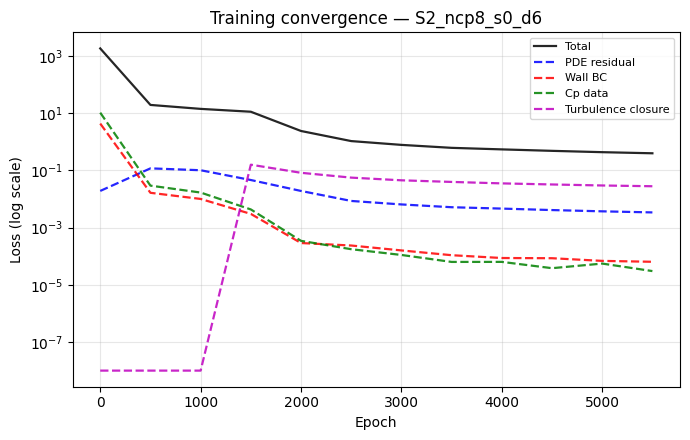

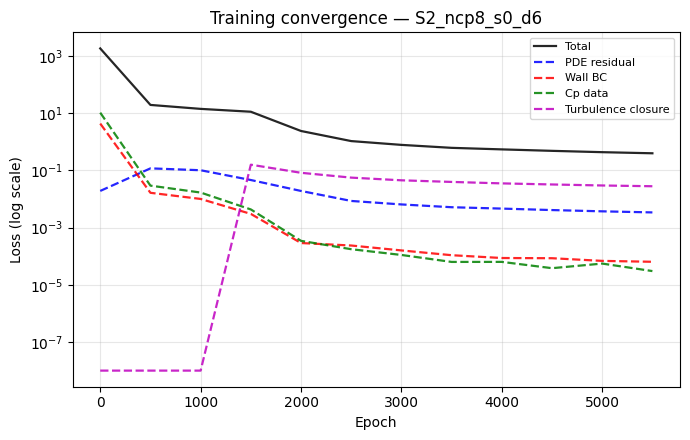

In [ ]:
# ---- Training convergence (loss components vs. epoch) ----
core.plot_training_history(history_fig, cfg_fig.run_id,
                            save_path=f"{OUT_DIR}/fig_training_history_{cfg_fig.run_id}.png",
                            ensure_drive_fn=core.ensure_drive)

In [ ]:
th = np.linspace(0, 2*np.pi, 256, dtype=np.float32)
xy = make_input((cfg30.R_OUT*np.cos(th)).reshape(-1,1),
                 (cfg30.R_OUT*np.sin(th)).reshape(-1,1))
uvp_ff = core.get_uvp(model30(xy, training=False)).numpy()
u_ff, v_ff, p_ff = uvp_ff[:,0], uvp_ff[:,1], uvp_ff[:,2]

below = np.sin(th) < 0   # y < 0, the side you flagged
above = np.sin(th) > 0   # y > 0

print("Raw p at r=R_OUT -- mean (this is p_ref):", p_ff.mean(), " std:", p_ff.std())
print("Raw p at r=R_OUT -- mean below (y<0):", p_ff[below].mean())
print("Raw p at r=R_OUT -- mean above (y>0):", p_ff[above].mean())
print("u at r=R_OUT -- mean:", u_ff.mean(), " std:", u_ff.std(), "(should be ~1, ~0 if enforced well)")
print("v at r=R_OUT -- mean:", v_ff.mean(), " std:", v_ff.std(), "(should be ~0, ~0)")

Raw p at r=R_OUT -- mean (this is p_ref): -0.17100742  std: 0.28119197
Raw p at r=R_OUT -- mean below (y<0): -0.4237735
Raw p at r=R_OUT -- mean above (y>0): 0.07801716
u at r=R_OUT -- mean: 1.0397316  std: 0.03152429 (should be ~1, ~0 if enforced well)
v at r=R_OUT -- mean: 0.043772057  std: 0.029943999 (should be ~0, ~0)


In [ ]:
print(cfg30.hard_constrain_farfield)

False


In [ ]:
import inspect
print(inspect.getsource(core.build_model))
print(inspect.getsource(core.train))

def build_model(cfg: RunConfig):
    tf.keras.backend.clear_session()
    if cfg.seed is not None:
        tf.random.set_seed(cfg.seed)

    inp = tf.keras.Input(shape=(3,))
    h = inp
    for _ in range(cfg.net_depth):
        h = tf.keras.layers.Dense(cfg.net_width, activation="tanh")(h)

    if cfg.hard_constrain_farfield:
        uv_corr = tf.keras.layers.Dense(2, activation=None)(h)
        p_out = tf.keras.layers.Dense(1, activation=None)(h)
        ko = tf.keras.layers.Dense(2, activation="softplus")(h)

        R_OUT_local = cfg.R_OUT

        def _hard_bc_uv(args):
            inp_full, corr = args
            x = inp_full[:, 0:1]
            y = inp_full[:, 1:2]
            r = tf.sqrt(x ** 2 + y ** 2)
            d = 1.0 - tf.clip_by_value(r / R_OUT_local, 0.0, 1.0) ** 2
            u = 1.0 + d * corr[:, 0:1]
            v = 0.0 + d * corr[:, 1:2]
            return tf.concat([u, v], axis=1)

        uv_hard = tf.keras.layers.Lambda(_hard_bc_uv, name="hard_bc_uv")([inp, uv_

In [ ]:
cfg_pp_fix = core.RunConfig(
    run_id="S9_pp_pointwise_d6",
    RE=3.6e5, ALPHA=2.0, NCp=30,
    cp_selection="evenly_spaced_index", seed=0,
    **BEST_CFG_FIELDS,
    notes="Pointwise far-field pressure loss, replacing mean-only loss_pp",
)

result_pp_fix = core.train(cfg_pp_fix, data_main, OUT_DIR)
model_pp_fix = result_pp_fix["model"]

✓ Run 'S9_pp_pointwise_d6' already completed — skipping training.


In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ============================================================
# CONFIG -- every knob lives here
# ============================================================
X_RANGE, Y_RANGE = (-20, 20), (-20, 20)
NX, NY = 250, 250

SPEED_CMAP, PRESSURE_CMAP, ERROR_CMAP = "viridis", "RdBu_r", "inferno"
SPEED_EXTEND, PRESSURE_EXTEND, ERROR_EXTEND = "both", "both", "max"   # colorbar arrow ends: 'both'|'min'|'max'|'neither'

STREAMLINES_ON   = True
STREAM_DENSITY   = 1.5       # higher = more streamlines
STREAM_COLOR     = "black"   # single color; set STREAM_COLOR_BY_SPEED=True to override
STREAM_LINEWIDTH = 0.4
STREAM_COLOR_BY_SPEED = False   # True -> streamlines colored by local speed (uses STREAM_CMAP)
STREAM_CMAP = "gray"

# ---- 1. Reload the NCp=30 checkpoint (already trained -- no retraining) ----
run_id = "S2_ncp30_s0_d6"
#run_id = "S9_pp_pointwise_d6"
#run_id =S11_hardff_pp_pointwise_d6_results
cfg30 = core.RunConfig(
    run_id=run_id, RE=3.6e5, ALPHA=2.0, NCp=30,
    cp_selection="evenly_spaced_index", seed=0,
    **BEST_CFG_FIELDS,
)
result30 = core.train(cfg30, data_main, OUT_DIR)   # should print "already completed -- skipping"
model30 = result30["model"]

# ---- 2. Load the updated CFD file (now has raw x-velocity / y-velocity) ----
CFD_CSV_PATH = f"{OUT_DIR}/../cfd_validation/u_p_CFD.csv"   # <-- point this at the new uploaded file
df_cfd = pd.read_csv(CFD_CSV_PATH)
x_cfd = df_cfd["x-coordinate"].values.astype(np.float64)
y_cfd = df_cfd["y-coordinate"].values.astype(np.float64)
xvel_cfd = df_cfd["x-velocity"].values.astype(np.float64)
yvel_cfd = df_cfd["y-velocity"].values.astype(np.float64)
p_cfd    = df_cfd["expr:P_scaled"].values.astype(np.float64)

r_cfd = np.sqrt(x_cfd**2 + y_cfd**2)
keep = r_cfd >= cfg30.R_IN - 1e-6
x_cfd, y_cfd, xvel_cfd, yvel_cfd, p_cfd = [
    a[keep] for a in (x_cfd, y_cfd, xvel_cfd, yvel_cfd, p_cfd)]

# U_inf derived from the data itself (median of |velocity|/expr:u_scaled at
# far-field points), not hardcoded -- avoids guessing a constant.
speed_scaled_check = df_cfd["expr:u_scaled"].values.astype(np.float64)[keep]
raw_speed = np.sqrt(xvel_cfd**2 + yvel_cfd**2)
U_INF = float(np.median(raw_speed[speed_scaled_check > 0.5] / speed_scaled_check[speed_scaled_check > 0.5]))
print(f"U_inf derived from CFD file: {U_INF:.4f}")

u_cfd = xvel_cfd / U_INF
v_cfd = yvel_cfd / U_INF
speed_cfd = np.sqrt(u_cfd**2 + v_cfd**2)

# ---- 3. PINN evaluation ----
make_input = core.make_input_fn(cfg30)

def pinn_eval(x_flat, y_flat, chunk=8192):
    u_out, v_out, p_out = [], [], []
    for i in range(0, len(x_flat), chunk):
        xy = make_input(x_flat[i:i+chunk].reshape(-1,1).astype(np.float32),
                         y_flat[i:i+chunk].reshape(-1,1).astype(np.float32))
        o = core.get_uvp(model30(xy, training=False)).numpy()
        u_out.append(o[:,0]); v_out.append(o[:,1]); p_out.append(o[:,2])
    return np.concatenate(u_out), np.concatenate(v_out), np.concatenate(p_out)

def p_reference(n=256):
    th = np.linspace(0, 2*np.pi, n, dtype=np.float32)
    xy = make_input((cfg30.R_OUT*np.cos(th)).reshape(-1,1),
                     (cfg30.R_OUT*np.sin(th)).reshape(-1,1))
    return float(core.get_uvp(model30(xy, training=False)).numpy()[:, 2].mean())

p_ref = p_reference()

# ---- 4. Error numbers at exact CFD points, full domain + near-wall/far-field split ----
u_p, v_p, p_p = pinn_eval(x_cfd, y_cfd)
speed_pinn = np.sqrt(u_p**2 + v_p**2)
p_pinn     = p_p - p_ref
near_wall  = r_cfd[keep] < 2.0 if False else np.sqrt(x_cfd**2 + y_cfd**2) < 2.0

def errors(pred, truth, mask=None):
    if mask is not None:
        pred, truth = pred[mask], truth[mask]
    e = pred - truth
    return dict(MAE=float(np.mean(np.abs(e))), RMSE=float(np.sqrt(np.mean(e**2))),
                rel_L2=float(np.linalg.norm(e)/(np.linalg.norm(truth)+1e-12)), n=int(len(truth)))

print(f"Run: {run_id} (NCp=30)")
print("Speed |u| -- full:      ", errors(speed_pinn, speed_cfd))
print("Speed |u| -- near wall: ", errors(speed_pinn, speed_cfd, near_wall))
print("Speed |u| -- far field: ", errors(speed_pinn, speed_cfd, ~near_wall))
print("Pressure -- full:       ", errors(p_pinn, p_cfd))
print("Pressure -- near wall:  ", errors(p_pinn, p_cfd, near_wall))
print("Pressure -- far field:  ", errors(p_pinn, p_cfd, ~near_wall))
# ---- CSV export for independent inspection ----
df_compare = pd.DataFrame({
    "x": x_cfd, "y": y_cfd, "r": np.sqrt(x_cfd**2 + y_cfd**2),
    "near_wall": near_wall,
    "speed_cfd": speed_cfd, "speed_pinn": speed_pinn,
    "speed_abs_error": np.abs(speed_pinn - speed_cfd),
    "p_cfd": p_cfd, "p_pinn": p_pinn,
    "p_abs_error": np.abs(p_pinn - p_cfd),
})
csv_path = f"{OUT_DIR}/compare_pointlevel_{run_id}.csv"
df_compare.to_csv(csv_path, index=False)
print("Point-level comparison (exact CFD mesh points, zero interpolation) saved to:", csv_path)

df_grid = pd.DataFrame({
    "x": Xg.ravel(), "y": Yg.ravel(), "inside_cylinder": inside.ravel(),
    "speed_cfd_griddata": speed_cfd_g.ravel(), "speed_pinn": speed_pinn_g.ravel(),
    "speed_abs_error": speed_err_g.ravel(),
    "p_cfd_griddata": p_cfd_g.ravel(), "p_pinn": p_pinn_g.ravel(),
    "p_abs_error": p_err_g.ravel(),
})
csv_grid_path = f"{OUT_DIR}/compare_grid_{run_id}.csv"
df_grid.to_csv(csv_grid_path, index=False)
print("Gridded comparison (CFD side is linear-griddata interpolated -- treat with caution near r~R_IN) saved to:", csv_grid_path)
# ---- 5. Grids: speed, pressure, and u/v components (for streamlines) ----
xg, yg = np.linspace(*X_RANGE, NX), np.linspace(*Y_RANGE, NY)
Xg, Yg = np.meshgrid(xg, yg)
inside = np.sqrt(Xg**2 + Yg**2) < cfg30.R_IN

u_cfd_g = griddata((x_cfd, y_cfd), u_cfd, (Xg, Yg), method="linear")
v_cfd_g = griddata((x_cfd, y_cfd), v_cfd, (Xg, Yg), method="linear")
p_cfd_g = griddata((x_cfd, y_cfd), p_cfd, (Xg, Yg), method="linear")
speed_cfd_g = np.sqrt(u_cfd_g**2 + v_cfd_g**2)

u_g, v_g, p_g = pinn_eval(Xg.ravel(), Yg.ravel())
u_pinn_g = u_g.reshape(Xg.shape)
v_pinn_g = v_g.reshape(Xg.shape)
p_pinn_g = (p_g - p_ref).reshape(Xg.shape)
speed_pinn_g = np.sqrt(u_pinn_g**2 + v_pinn_g**2)

speed_err_g = np.abs(speed_pinn_g - speed_cfd_g)
p_err_g     = np.abs(p_pinn_g - p_cfd_g)

def mask(a): return np.ma.array(a, mask=inside | np.isnan(a))
speed_cfd_gm, speed_pinn_gm, speed_err_gm = mask(speed_cfd_g), mask(speed_pinn_g), mask(speed_err_g)
p_cfd_gm, p_pinn_gm, p_err_gm = mask(p_cfd_g), mask(p_pinn_g), mask(p_err_g)

# Streamline velocity: zero out inside the cylinder (not NaN -- streamplot
# doesn't handle NaN reliably). The gray circle patch drawn on top hides it.
def stream_uv(u, v):
    u2, v2 = u.copy(), v.copy()
    u2[inside] = 0.0; v2[inside] = 0.0
    u2 = np.nan_to_num(u2); v2 = np.nan_to_num(v2)
    return u2, v2

u_cfd_s, v_cfd_s = stream_uv(u_cfd_g, v_cfd_g)
u_pinn_s, v_pinn_s = stream_uv(u_pinn_g, v_pinn_g)

speed_levels = np.linspace(np.nanmin(speed_cfd_gm), np.nanmax(speed_cfd_gm), 31)
p_levels     = np.linspace(np.nanmin(p_cfd_gm),     np.nanmax(p_cfd_gm),     31)
speed_err_levels = np.linspace(0, np.nanmax(speed_err_gm), 31)
p_err_levels     = np.linspace(0, np.nanmax(p_err_gm),     31)

# ---- 6. Plot ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))

def add_streamlines(ax, u_s, v_s, speed_field):
    if not STREAMLINES_ON:
        return
    if STREAM_COLOR_BY_SPEED:
        ax.streamplot(xg, yg, u_s, v_s, density=STREAM_DENSITY,
                      color=speed_field, cmap=STREAM_CMAP, linewidth=STREAM_LINEWIDTH)
    else:
        ax.streamplot(xg, yg, u_s, v_s, density=STREAM_DENSITY,
                      color=STREAM_COLOR, linewidth=STREAM_LINEWIDTH)

rows = [
    ("Speed |u|", speed_cfd_gm, speed_pinn_gm, speed_err_gm, SPEED_CMAP, speed_levels, speed_err_levels, SPEED_EXTEND, True),
    ("Pressure",  p_cfd_gm,     p_pinn_gm,     p_err_gm,     PRESSURE_CMAP, p_levels, p_err_levels, PRESSURE_EXTEND, False),
]
for i, (label, cfd_g, pinn_g, err_g, cmap, levels, err_levels, extend, has_stream) in enumerate(rows):
    for j, (field, title) in enumerate([(cfd_g, f"{label} -- CFD"), (pinn_g, f"{label} -- PINN")]):
        ax = axes[i, j]
        c = ax.contourf(Xg, Yg, field, levels=levels, cmap=cmap, extend=extend)
        fig.colorbar(c, ax=ax)
        if has_stream:
            u_s, v_s = (u_cfd_s, v_cfd_s) if j == 0 else (u_pinn_s, v_pinn_s)
            sp = speed_cfd_g if j == 0 else speed_pinn_g
            add_streamlines(ax, u_s, v_s, sp)
        ax.set_title(title)
    ax = axes[i, 2]
    c = ax.contourf(Xg, Yg, err_g, levels=err_levels, cmap=ERROR_CMAP, extend=ERROR_EXTEND)
    fig.colorbar(c, ax=ax)
    ax.set_title(f"{label} -- |PINN - CFD|")
    for ax in axes[i]:
        ax.add_patch(plt.Circle((0, 0), cfg30.R_IN, facecolor="lightgray", edgecolor="k", zorder=5))
        ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        ax.set_xlim(X_RANGE); ax.set_ylim(Y_RANGE); ax.set_aspect("equal")

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_cfd_pinn_streamlines_{run_id}.png", dpi=200, bbox_inches="tight")
plt.show()

✓ Run 'S2_ncp30_s0_d6' already completed — skipping training.
U_inf derived from CFD file: 5.4656
Run: S2_ncp30_s0_d6 (NCp=30)
Speed |u| -- full:       {'MAE': 0.2985246837715512, 'RMSE': 0.5169143855846117, 'rel_L2': 0.441751143102786, 'n': 14327}
Speed |u| -- near wall:  {'MAE': 0.5379753578170249, 'RMSE': 0.740336718208362, 'rel_L2': 0.5518012993247795, 'n': 6592}
Speed |u| -- far field:  {'MAE': 0.09445760642083866, 'RMSE': 0.16676560462056672, 'rel_L2': 0.16659294852716883, 'n': 7735}
Pressure -- full:        {'MAE': 0.5964235191156609, 'RMSE': 0.9046605972542229, 'rel_L2': 0.6250861356847338, 'n': 14327}
Pressure -- near wall:   {'MAE': 0.9481690565065969, 'RMSE': 1.278435173333449, 'rel_L2': 0.5994246995039844, 'n': 6592}
Pressure -- far field:   {'MAE': 0.2966553765841741, 'RMSE': 0.3507181291875875, 'rel_L2': 6.35083084132749, 'n': 7735}
Point-level comparison (exact CFD mesh points, zero interpolation) saved to: /content/drive/MyDrive/PINN_Flettner2/runs/compare_pointlevel_S2

NameError: name 'Xg' is not defined

In [ ]:
th = np.linspace(0, 2*np.pi, 256, dtype=np.float32)
xy = make_input((cfg_pp_fix.R_OUT*np.cos(th)).reshape(-1,1),
                 (cfg_pp_fix.R_OUT*np.sin(th)).reshape(-1,1))
uvp_ff = core.get_uvp(model_pp_fix(xy, training=False)).numpy()
u_ff, v_ff, p_ff = uvp_ff[:,0], uvp_ff[:,1], uvp_ff[:,2]

below = np.sin(th) < 0   # y < 0, the side you flagged
above = np.sin(th) > 0   # y > 0

print("Raw p at r=R_OUT -- mean (this is p_ref):", p_ff.mean(), " std:", p_ff.std())
print("Raw p at r=R_OUT -- mean below (y<0):", p_ff[below].mean())
print("Raw p at r=R_OUT -- mean above (y>0):", p_ff[above].mean())
print("u at r=R_OUT -- mean:", u_ff.mean(), " std:", u_ff.std(), "(should be ~1, ~0 if enforced well)")
print("v at r=R_OUT -- mean:", v_ff.mean(), " std:", v_ff.std(), "(should be ~0, ~0)")

Raw p at r=R_OUT -- mean (this is p_ref): -0.036888383  std: 0.0128641995
Raw p at r=R_OUT -- mean below (y<0): -0.031755406
Raw p at r=R_OUT -- mean above (y>0): -0.04212748
u at r=R_OUT -- mean: 0.9241126  std: 0.07021989 (should be ~1, ~0 if enforced well)
v at r=R_OUT -- mean: 0.008171231  std: 0.05543007 (should be ~0, ~0)


In [ ]:
cfg_hardff = core.RunConfig(
    run_id="S11_hardff_pp_pointwise_d6",
    RE=3.6e5, ALPHA=2.0, NCp=30,
    cp_selection="evenly_spaced_index", seed=0,
    hard_constrain_farfield=True,
    **BEST_CFG_FIELDS,
    notes="Hard-constrained u,v at far field (existing mechanism, previously unused) plus pointwise far-field pressure loss, to remove the velocity regression introduced in S9 without reintroducing the pressure asymmetry",
)
result_hardff = core.train(cfg_hardff, data_main, OUT_DIR)
model_hardff = result_hardff["model"]

✓ Run 'S11_hardff_pp_pointwise_d6' already completed — skipping training.


In [ ]:
import glob, json, os
for f in sorted(glob.glob(os.path.join(OUT_DIR, "*_results.json"))):
    try:
        r = json.load(open(f))
    except Exception as e:
        print("unreadable:", os.path.basename(f), e); continue
    keep = {k: v for k, v in r.items()
            if k.lower() in ("completed",) or any(s in k.lower() for s in ("mae", "cl", "cd"))
            and not isinstance(v, (list, dict))}
    print(os.path.basename(f).replace("_results.json", ""), keep)

P0_verify_ncp8 {'completed': True}
S11_hardff_pp_pointwise_d6 {'completed': True}
S1_arch_d4_w128 {'completed': True}
S1_arch_d4_w160 {'completed': True}
S1_arch_d4_w96 {'completed': True}
S1_arch_d5_w128 {'completed': True}
S1_arch_d5_w160 {'completed': True}
S1_arch_d5_w96 {'completed': True}
S1_arch_d6_w128 {'completed': True}
S1_arch_d6_w160 {'completed': True}
S1_arch_d6_w96 {'completed': True}
S1_nint_100000_d6 {'completed': False}
S1_nint_10000_d6 {'completed': True}
S1_nint_10000 {'completed': True}
S1_nint_15000_d6 {'completed': True}
S1_nint_20000_d6 {'completed': True}
S1_nint_20000 {'completed': True}
S1_nint_2000_d6 {'completed': True}
S1_nint_2000 {'completed': True}
S1_nint_40000_d6 {'completed': True}
S1_nint_50000_d6 {'completed': True}
S1_nint_50000 {'completed': True}
S1_nint_5000_d6 {'completed': True}
S1_wcp_100_d6 {'completed': True}
S1_wcp_100 {'completed': True}
S1_wcp_10_d6 {'completed': True}
S1_wcp_10 {'completed': True}
S1_wcp_1_d6 {'completed': False}
S1_wc

In [ ]:
import json, os
def show(d, indent=0):
    for k, v in d.items():
        if isinstance(v, dict):
            print(" "*indent + k + ":"); show(v, indent+2)
        elif isinstance(v, list):
            print(" "*indent + f"{k}: list[{len(v)}]")
        else:
            print(" "*indent + f"{k}: {v}")

for name in ("S2_ncp30_s0_d6", "S4_M2_suction_s0"):
    print("=====", name)
    show(json.load(open(os.path.join(OUT_DIR, name + "_results.json"))))

===== S2_ncp30_s0_d6
last_epoch: 5999
best_loss: 0.40115711092948914
history:
  loss: list[12]
  pde: list[12]
  wall: list[12]
  cp: list[12]
  turb: list[12]
  epoch: list[12]
completed: True
elapsed_min: 32.10924996137619
config:
  run_id: S2_ncp30_s0_d6
  RE: 360000.0
  ALPHA: 2.0
  R_IN: 0.5
  R_OUT: 25.0
  NCp: 30
  cp_selection: evenly_spaced_index
  cp_theta_explicit: None
  mask_sectors: None
  hard_constrain_farfield: False
  net_depth: 6
  net_width: 128
  EPOCHS: 6000
  LR: 0.0001
  LR_DECAY_EPOCH: 3000
  LR_DECAY_TO: 3e-05
  TURB_RAMP_START: 1000
  TURB_RAMP_LEN: 1000
  N_INT: 20000
  N_WALL: 300
  N_FF: 150
  W_PDE: 100.0
  W_VWALL: 300.0
  W_VFF: 10.0
  W_PP: 50.0
  W_CP: 50
  W_TURB: 1.0
  warm_start_run_id: None
  seed: 0
  notes: Step 2 — NCp sweep + seed variability (depth-6, correct architecture)
===== S4_M2_suction_s0
last_epoch: 5999
best_loss: 0.39308562874794006
history:
  loss: list[12]
  pde: list[12]
  wall: list[12]
  cp: list[12]
  turb: list[12]
  epoch: l

✓ Run 'S7_wpp_50_d6' already completed — skipping training.
✓ Run 'S7_wpp_150_d6' already completed — skipping training.
✓ Run 'S7_wpp_300_d6' already completed — skipping training.
✓ Run 'S7_wpp_500_d6' already completed — skipping training.


,run_id,cp_selection,MAE,RMSE,MAE_masked,RMSE_masked,CL,CD,CL_ref,CD_ref,CL_err_pct,CD_err_pct,n_train_points,n_masked_points,elapsed_min
0,S7_wpp_50_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.250082,0.311161,None,None,4.521034,1.769239,5.91713,1.744738,23.594131,1.404292,8,0,None
1,S7_wpp_150_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.263320,0.325210,None,None,4.489533,1.794920,5.91713,1.744738,24.126505,2.876211,8,0,None
2,S7_wpp_300_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.272174,0.344259,None,None,4.505609,1.779826,5.91713,1.744738,23.854826,2.011086,8,0,None
3,S7_wpp_500_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.291694,0.358313,None,None,4.446314,1.748492,5.91713,1.744738,24.856912,0.215190,8,0,None


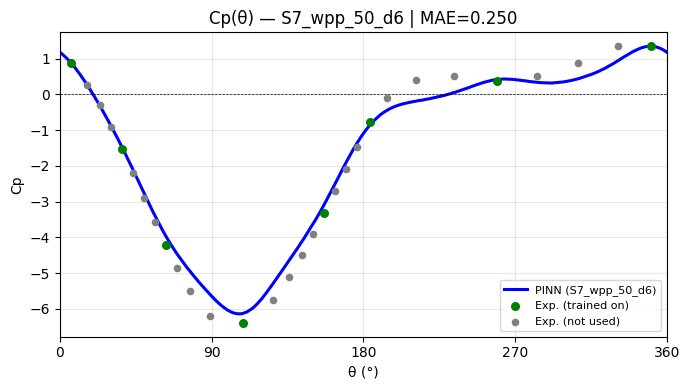

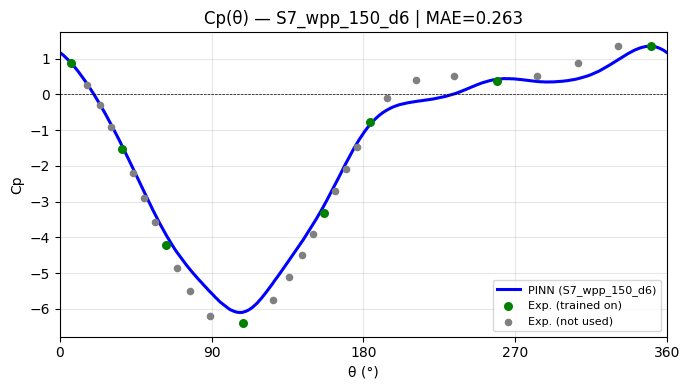

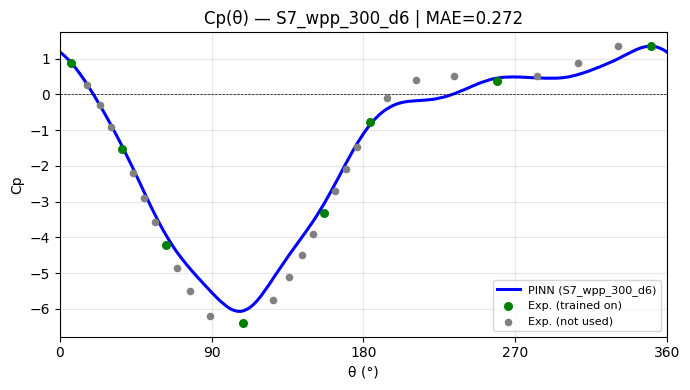

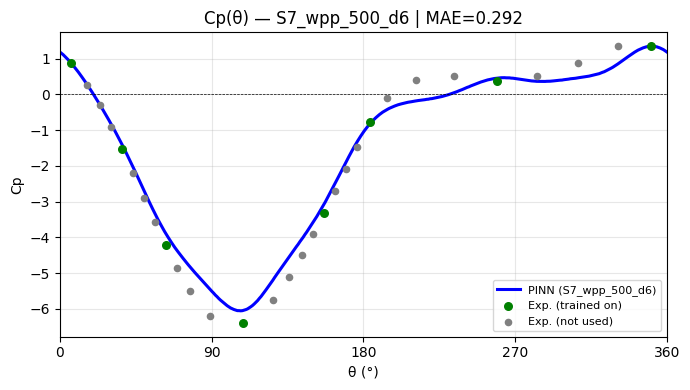

In [ ]:
rows = []
for w_pp in [50, 150, 300, 500]:
    cfg = core.RunConfig(
        run_id=f"S7_wpp_{w_pp}_d6",
        RE=3.6e5, ALPHA=2.0, NCp=8, cp_selection="evenly_spaced_index",
        seed=0, W_PP=float(w_pp),
        **BEST_CFG_FIELDS,
        notes="Pressure far-field gauge weight sweep -- testing fix for domain-wide pressure bias",
    )
    r = run_one(cfg, data_main)
    rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})
df_wpp = pd.DataFrame(rows)
df_wpp.to_csv(f"{OUT_DIR}/wpp_sweep_results.csv", index=False)
df_wpp

In [ ]:
# ---- Additive turbulence-closure calibration (monkey-patch, no edit to cell 4) ----
# train() resolves make_turb_constants as a module-global name at call time,
# so replacing core.make_turb_constants here takes effect for every train()
# call made afterward -- the %%writefile cell itself is untouched.

import tensorflow as tf

# Free-stream turbulence intensity + length scale, used to calibrate the
# far-field k, omega targets (previously hardcoded KI=1.5e-4, OI=2.0 with
# no stated basis). Bordogna et al. (2019), Sec. 2.2, report Iu=2% for the
# Politecnico di Milano wind-tunnel test section this validation dataset
# was measured in; l~0.07*D is the standard engineering estimate for
# external bluff-body-flow turbulence length scale.
TURB_INTENSITY = 0.02
TURB_LENGTH_SCALE = 0.07

def make_turb_constants_calibrated(cfg):
    NU = 1.0 / cfg.RE
    BSTAR = .09
    KI_val = 1.5 * (TURB_INTENSITY) ** 2
    OI_val = (KI_val ** 0.5) / (TURB_LENGTH_SCALE * BSTAR ** 0.25)
    return dict(
        NU=tf.constant(float(NU), tf.float32), BSTAR=tf.constant(BSTAR, tf.float32),
        BETA2=tf.constant(.0828, tf.float32), SK2=tf.constant(1., tf.float32),
        SO2=tf.constant(.856, tf.float32),
        GAM2=tf.constant(.0828 / .09 - .856 * .41 ** 2 / .09 ** .5, tf.float32),
        EPS=tf.constant(1e-8, tf.float32), KW=tf.constant(0., tf.float32),
        OW=tf.constant(60. * float(NU), tf.float32),
        KI=tf.constant(float(KI_val), tf.float32), OI=tf.constant(float(OI_val), tf.float32),
    )

core.make_turb_constants = make_turb_constants_calibrated
print("Patched core.make_turb_constants -> "
      f"KI={1.5*TURB_INTENSITY**2:.3e}, OI={(1.5*TURB_INTENSITY**2)**0.5/(TURB_LENGTH_SCALE*0.09**0.25):.3f}")

Patched core.make_turb_constants -> KI=6.000e-04, OI=0.639


✓ Run 'S5_wturb_1_d6' already completed — skipping training.
✓ Run 'S5_wturb_10_d6' already completed — skipping training.
✓ Run 'S5_wturb_30_d6' already completed — skipping training.
✓ Run 'S5_wturb_100_d6' already completed — skipping training.


,run_id,cp_selection,MAE,RMSE,MAE_masked,RMSE_masked,CL,CD,CL_ref,CD_ref,CL_err_pct,CD_err_pct,n_train_points,n_masked_points,elapsed_min
0,S5_wturb_1_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.247822,0.319483,None,None,4.540566,1.822503,5.91713,1.744738,23.264035,4.457116,8,0,None
1,S5_wturb_10_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.253923,0.328195,None,None,4.531940,1.817511,5.91713,1.744738,23.409831,4.171005,8,0,None
2,S5_wturb_30_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.265015,0.330522,None,None,4.513155,1.758128,5.91713,1.744738,23.727291,0.767475,8,0,None
3,S5_wturb_100_d6,"{'train_idx': [0, 4, 8, 12, 17, 21, 25, 29], '...",0.254137,0.319421,None,None,4.551357,1.799213,5.91713,1.744738,23.081669,3.122291,8,0,None


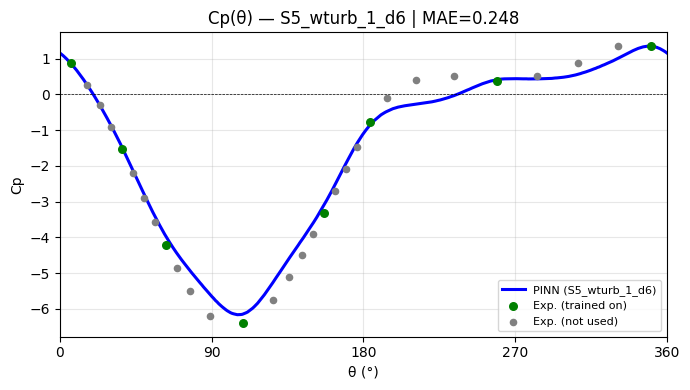

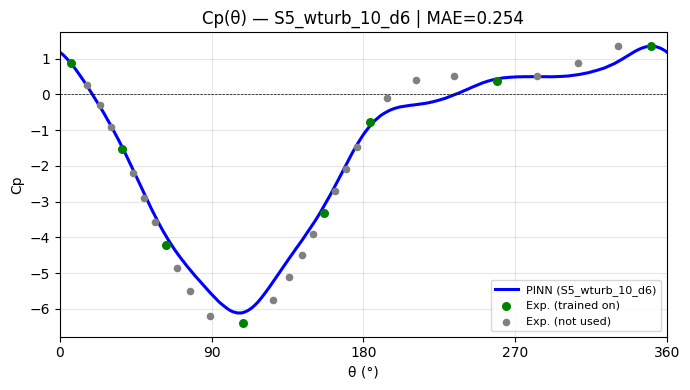

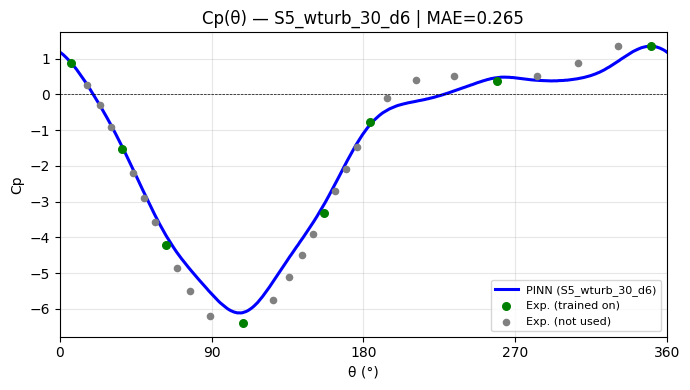

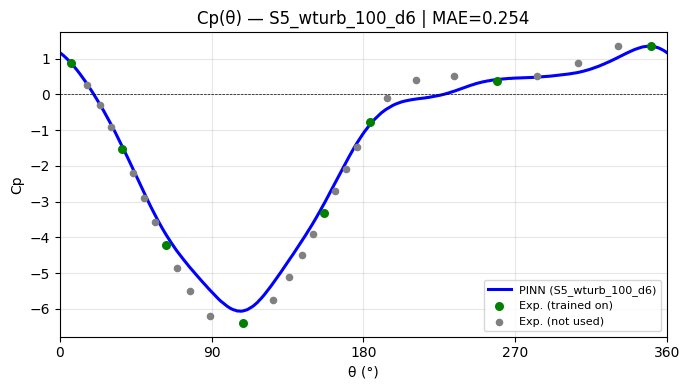

In [ ]:
# ---- W_TURB sweep: does better-weighted + better-calibrated turbulence
#      closure shrink the near-wall high-speed ring / mid-field pressure bump?
#      New run_ids -- doesn't touch or invalidate any existing S2 checkpoint. ----
rows = []
for w_turb in [1, 10, 30, 100]:
    cfg = core.RunConfig(
        run_id=f"S5_wturb_{w_turb}_d6",
        RE=3.6e5, ALPHA=2.0, NCp=8, cp_selection="evenly_spaced_index",
        seed=0, W_TURB=float(w_turb),
        **BEST_CFG_FIELDS,
        notes="Turbulence-closure weight sweep -- testing fix for near-wall high-speed ring / mid-field pressure bump",
    )
    r = run_one(cfg, data_main)
    rows.append({k: v for k, v in r.items() if k not in ("model", "eval", "history")})

df_wturb = pd.DataFrame(rows)
df_wturb.to_csv(f"{OUT_DIR}/wturb_sweep_results.csv", index=False)
df_wturb

In [ ]:
import numpy as np

# Wake sub-region identified from the CFD-vs-PINN streamline comparison --
# this is where the PINN produced a closed recirculation loop absent from CFD.
WAKE_BOX_X = (-1.0, 2.0)
WAKE_BOX_Y = (-3.0, -0.3)
WAKE_FRACTION = 0.25        # fraction of interior points drawn from the wake box
NEARWALL_FRACTION = 0.15    # fraction of interior points drawn very close to r=R_IN
NEARWALL_BAND = 1.0         # radial band width added on top of R_IN

def sample_functions_biased(cfg):
    def sample_interior(n):
        n_wake = int(n * WAKE_FRACTION)
        n_wall = int(n * NEARWALL_FRACTION)
        n_base = n - n_wake - n_wall

        # baseline -- unchanged from the original sample_interior
        th_b = np.random.uniform(0, 2 * np.pi, n_base).astype(np.float32)
        r_b = np.exp(np.random.uniform(np.log(cfg.R_IN), np.log(cfg.R_OUT), n_base)).astype(np.float32)
        x_b = (r_b * np.cos(th_b)).reshape(-1, 1)
        y_b = (r_b * np.sin(th_b)).reshape(-1, 1)

        # wake sub-region -- rejection-sampled directly in (x, y), redrawing
        # any point that lands inside the cylinder
        xs, ys = [], []
        while len(xs) < n_wake:
            xc = np.random.uniform(*WAKE_BOX_X, n_wake)
            yc = np.random.uniform(*WAKE_BOX_Y, n_wake)
            ok = (xc**2 + yc**2) >= cfg.R_IN**2
            xs.extend(xc[ok]); ys.extend(yc[ok])
        x_w = np.array(xs[:n_wake], dtype=np.float32).reshape(-1, 1)
        y_w = np.array(ys[:n_wake], dtype=np.float32).reshape(-1, 1)

        # near-wall band -- r concentrated close to R_IN via a cubic-skewed draw
        th_n = np.random.uniform(0, 2 * np.pi, n_wall).astype(np.float32)
        u = np.random.uniform(0, 1, n_wall).astype(np.float32)
        r_n = cfg.R_IN + NEARWALL_BAND * (u ** 3)
        x_n = (r_n * np.cos(th_n)).reshape(-1, 1)
        y_n = (r_n * np.sin(th_n)).reshape(-1, 1)

        x = np.concatenate([x_b, x_w, x_n], axis=0)
        y = np.concatenate([y_b, y_w, y_n], axis=0)
        return x, y

    def sample_wall(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (-cfg.R_IN * np.cos(th)).reshape(-1, 1), (+cfg.R_IN * np.sin(th)).reshape(-1, 1)

    def sample_ff(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (cfg.R_OUT * np.cos(th)).reshape(-1, 1), (cfg.R_OUT * np.sin(th)).reshape(-1, 1)

    return sample_interior, sample_wall, sample_ff

core.sample_functions = sample_functions_biased
print("Patched core.sample_functions -> wake-box + near-wall biased interior sampling")
print(f"  wake box: x in {WAKE_BOX_X}, y in {WAKE_BOX_Y}, fraction={WAKE_FRACTION}")
print(f"  near-wall band width={NEARWALL_BAND}, fraction={NEARWALL_FRACTION}")

Patched core.sample_functions -> wake-box + near-wall biased interior sampling
  wake box: x in (-1.0, 2.0), y in (-3.0, -0.3), fraction=0.25
  near-wall band width=1.0, fraction=0.15


✓ Run 'S8_colloc_biased_ncp30_d6' already completed — skipping training.


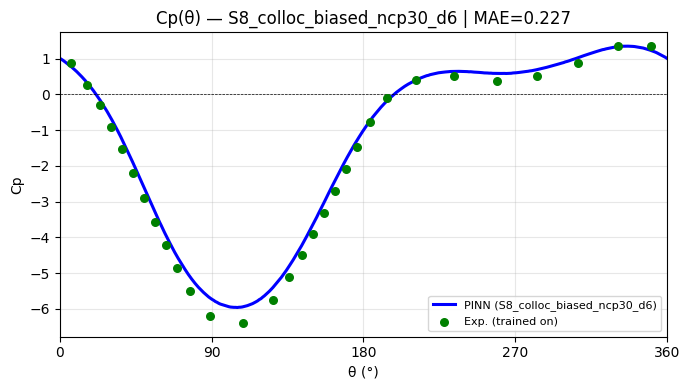

In [ ]:
cfg_colloc30 = core.RunConfig(
    run_id="S8_colloc_biased_ncp30_d6",
    RE=3.6e5, ALPHA=2.0, NCp=30, cp_selection="evenly_spaced_index",
    seed=0,
    **BEST_CFG_FIELDS,
    notes="Wake-box + near-wall biased interior collocation sampling -- testing fix for spurious wake recirculation loop and near-wall high-speed ring",
)
result_colloc30 = core.train(cfg_colloc30, data_main, OUT_DIR)
model_colloc30, history_colloc30 = result_colloc30["model"], result_colloc30["history"]
sel_colloc30 = core.select_cp_points(data_main["theta_exp"], data_main["cp_exp"], cfg_colloc30)
eval_colloc30 = core.evaluate(cfg_colloc30, model_colloc30, data_main, sel_colloc30, OUT_DIR)
eval_colloc30["fig"].savefig(f"{OUT_DIR}/fig_cp_curve_{cfg_colloc30.run_id}.png", dpi=200, bbox_inches="tight")

In [ ]:
diag_baseline = core.flow_field_diagnostics(cfg_s2, model_s2, eval_s2, extent=15.0)
diag_baseline["field"]["fig"].savefig(f"{OUT_DIR}/fig_flowfield_S2_ncp8_s0_d6_ext15.png", dpi=200, bbox_inches="tight")

NameError: name 'cfg_s2' is not defined

✓ Run 'S5_wturb_30_d6' already completed — skipping training.
saved: /content/drive/MyDrive/PINN_Flettner2/runs/fig_cp_curve_S5_wturb_30_d6.png
saved: /content/drive/MyDrive/PINN_Flettner2/runs/fig_flowfield_S5_wturb_30_d6.png


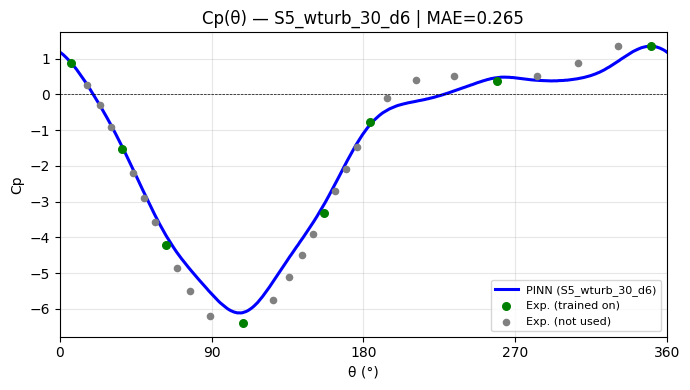

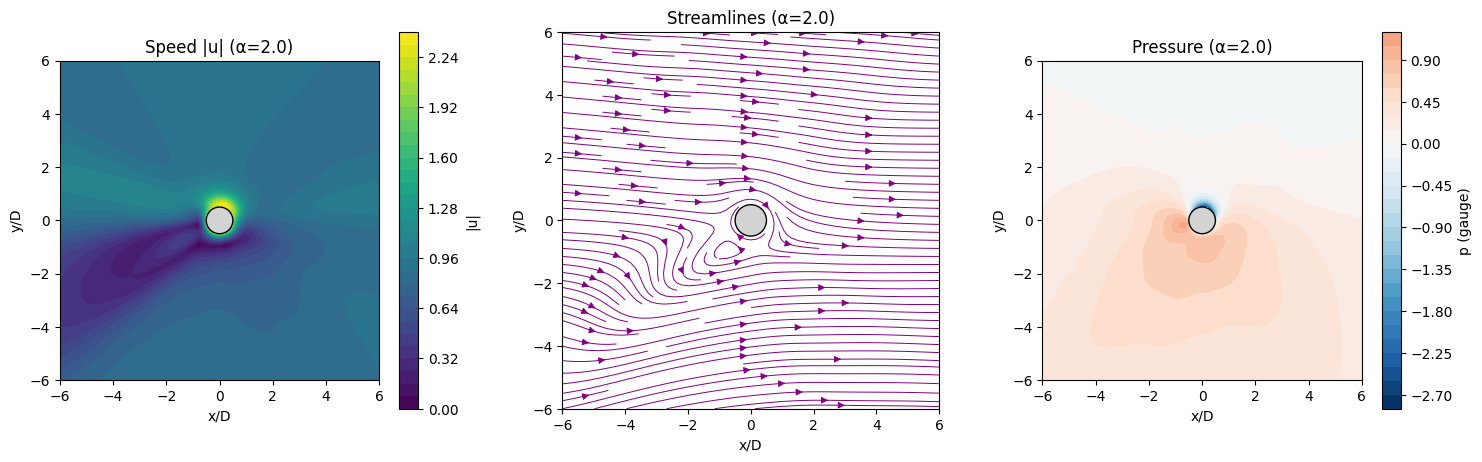

In [ ]:
# ---- Flow-field plot for S5_wturb_30_d6 (reload only, no retraining) ----
cfg_wturb30 = core.RunConfig(
    run_id="S5_wturb_30_d6",
    RE=3.6e5, ALPHA=2.0, NCp=8, cp_selection="evenly_spaced_index",
    seed=0, W_TURB=30.0,
    **BEST_CFG_FIELDS,
)

result_wturb30 = core.train(cfg_wturb30, data_main, OUT_DIR)  # already completed -> reloads instantly
model_wturb30, history_wturb30 = result_wturb30["model"], result_wturb30["history"]

sel_wturb30 = core.select_cp_points(data_main["theta_exp"], data_main["cp_exp"], cfg_wturb30)
eval_wturb30 = core.evaluate(cfg_wturb30, model_wturb30, data_main, sel_wturb30, OUT_DIR)
eval_wturb30["fig"].savefig(f"{OUT_DIR}/fig_cp_curve_{cfg_wturb30.run_id}.png", dpi=200, bbox_inches="tight")

diag_wturb30 = core.flow_field_diagnostics(cfg_wturb30, model_wturb30, eval_wturb30)
diag_wturb30["field"]["fig"].savefig(f"{OUT_DIR}/fig_flowfield_{cfg_wturb30.run_id}.png", dpi=200, bbox_inches="tight")

for p in [f"{OUT_DIR}/fig_cp_curve_{cfg_wturb30.run_id}.png",
          f"{OUT_DIR}/fig_flowfield_{cfg_wturb30.run_id}.png"]:
    print("saved:", p)